# Licking EF — Licking vs Non-Licking (within on-nest, 3-band frequency)

## Task
Binary classification on PD3 on-nest windows: y=1 licking, y=0 non-licking.
Mutually contrasts active pup-licking against quieter on-nest states.

## Model
**dCSFA-NMF Ver1** (supervised autoencoder with NMF decoder)
- `n_components=10`, `n_sup_networks=1`
- Encoder: `Linear(108 → 64) + BN + LeakyReLU + Linear(64 → 10) + Softplus`
- Optimizer: `SGD, lr=1e-3, momentum=0.9, batch_size=256`
- `sup_weight (μ) = 0.07`, `fixed_corr="Positive"`, `recon_loss=MSE`

## Training data
`Spec_Features_8Yes/combine/full_spec_features_8roi.pkl` (filtered to PD3 on-nest)
- C-group animals only, PD3 on-nest windows
- Features: 3 bands `(2-7), (8-12), (14-23)` Hz × (8-ROI power + 28-pair coherence) = 108 dims

## Pipeline (3-stage nested LOO — see Methods)
1. **Step 1 — Validation-split LOO**: 9:1 train/val per fold + early stopping (patience=20)
2. **Step 2 — Pure LOO**: re-run with fixed `n_epochs=400` for fold-wise test AUC (mean ± SEM)
3. **Step 3 — Final model on all C animals** → `Maternal_model_lick_Onnest_C_only_Dec19_v1.pt`

## Outputs
- Final model: `Maternal_model_lick_Onnest_C_only_Dec19_v1.pt`
- Loadings bar-heatmap: `Selection_Licking_{50,60,70,80}.{png,pdf}` (4 cumulative-loading thresholds)
- Circos inputs (MATLAB): `AreaNames.mat`, `NormalizedCrossSpectra.mat`
- LOO summary: `loo_final_pair1_summary.png` or equivalent

## Backproject (projection to unseen data)
- **Stage data** (Pre/Ges/P1/P3/P4/P8/P14/P20) — score across maternal timepoints
- **Pup Retrieval** (PD4 homecage) — cross-task projection
- **External**: ELS animals (E group)

## Sister notebooks
`OnnestVsOffnest_3band.ipynb`, `LickingVsGrooming_3band.ipynb`, `PreVsPost134_3band.ipynb`


In [1]:
# Allow imports from ../src (this notebook lives in notebooks/, model code in src/)
import sys, os
_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.join(_repo_root, 'src') not in sys.path:
    sys.path.insert(0, os.path.join(_repo_root, 'src'))

from dCSFA_NMF_Ver1 import dCSFA_NMF
import umc_data_tools as umc_dt
import pandas as pd
import pickle
import re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold


def get_W_nmf(W_nmf):
        W = nn.Softplus()(W_nmf)
        return W

def process_W_nmf(W_normalized, train_dict, threshold_ratio=0.9):

    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]

    total_rows = len(rows_power) + len(rows_coh)
    df = pd.DataFrame(W_normalized[0, :].detach().numpy().reshape(total_rows, len(columns)),
                      index=rows_power + rows_coh,
                      columns=columns)

#     squared_values = df.values ** 2
#     flattened_squared_values = squared_values.flatten()
#     total_l2_norm = np.sqrt(np.sum(flattened_squared_values))
#     sorted_indices = np.argsort(flattened_squared_values)[::-1]
#     sorted_squared_values = flattened_squared_values[sorted_indices]
#     cumulative_sum = np.cumsum(sorted_squared_values)
#     cumulative_l2_norm = np.sqrt(cumulative_sum)
#     threshold = threshold_ratio * total_l2_norm
#     selected_indices = sorted_indices[cumulative_l2_norm <= threshold]
#     selected_positions = np.unravel_index(selected_indices, df.shape)

    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    selected_positions = np.unravel_index(selected_indices, df.shape)


    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("Selected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected

def process_W_nmf_k(W_normalized, train_dict, threshold_ratio=0.9, k=0):

    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]

    total_rows = len(rows_power) + len(rows_coh)
    df = pd.DataFrame(W_normalized[k, :].detach().numpy().reshape(total_rows, len(columns)),
                      index=rows_power + rows_coh,
                      columns=columns)

    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    selected_positions = np.unravel_index(selected_indices, df.shape)


    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("Selected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected

# Data Loading and Processing

# LOO Training

### Choose epoch and mu using 10% as validation set

Cleaning old checkpoint files...
Cleanup complete.

Creating datasets...
Licking dataset: Licking during Onnest (1) vs NonLicking during Onnest (0)
Condition: (full_dict['onnest_raw'] == 1)

Onnest dataset: remove all licking, remaining Onnest (1) vs Offnest (0)

Dataset Statistics:

Licking_C: 13432 samples, licking=1: 473, licking=0: 12959
  C1ELS32: 1718 samples (licking=1: 85)
  C2ELS18: 1061 samples (licking=1: 43)
  C5ELS20: 2185 samples (licking=1: 45)
  C5ELS40: 2169 samples (licking=1: 137)
  C6ELS42: 1465 samples (licking=1: 75)
  C7ELS11: 1336 samples (licking=1: 28)
  C7ELS22: 2626 samples (licking=1: 23)
  C7ELS45: 872 samples (licking=1: 37)

Licking_E: 9727 samples, licking=1: 222, licking=0: 9505
  E1ELS33: 2230 samples (licking=1: 142)
  E2ELS3: 135 samples (licking=1: 13)
  E3ELS37: 2722 samples (licking=1: 33)
  E4ELS39: 2706 samples (licking=1: 11)
  E5ELS41: 302 samples (licking=1: 13)
  E6ELS44: 1632 samples (licking=1: 10)

Onnest_C: 28278 samples, onnest=1: 1295

/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 150.69it/s]


Selecting network: 2 with auc 0.7792310414726439 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0136, pred=0.0125, phi=0.000000
             Val: recon=0.0159, pred=0.0122
             Best epoch so far: 393, Best val loss: 0.0281


Ep:500, Best:482, TrLoss:0.0242, ValLoss:0.0266, TrAUC:0.784, ValAUC:0.789:  84%


  [Epoch 500] Train: recon=0.0127, pred=0.0115, phi=0.000000
             Val: recon=0.0151, pred=0.0115
             Best epoch so far: 482, Best val loss: 0.0267


Ep:553, Best:534, TrLoss:0.0236, ValLoss:0.0259, TrAUC:0.786, ValAUC:0.790:  92%



*** Early stopping at epoch 554 ***
    No improvement > 0.0002 for 20 epochs
    Best epoch: 534, Best val loss: 0.0261
Loading best model from epoch 534...
Done!
Best epoch for fold 1: 534


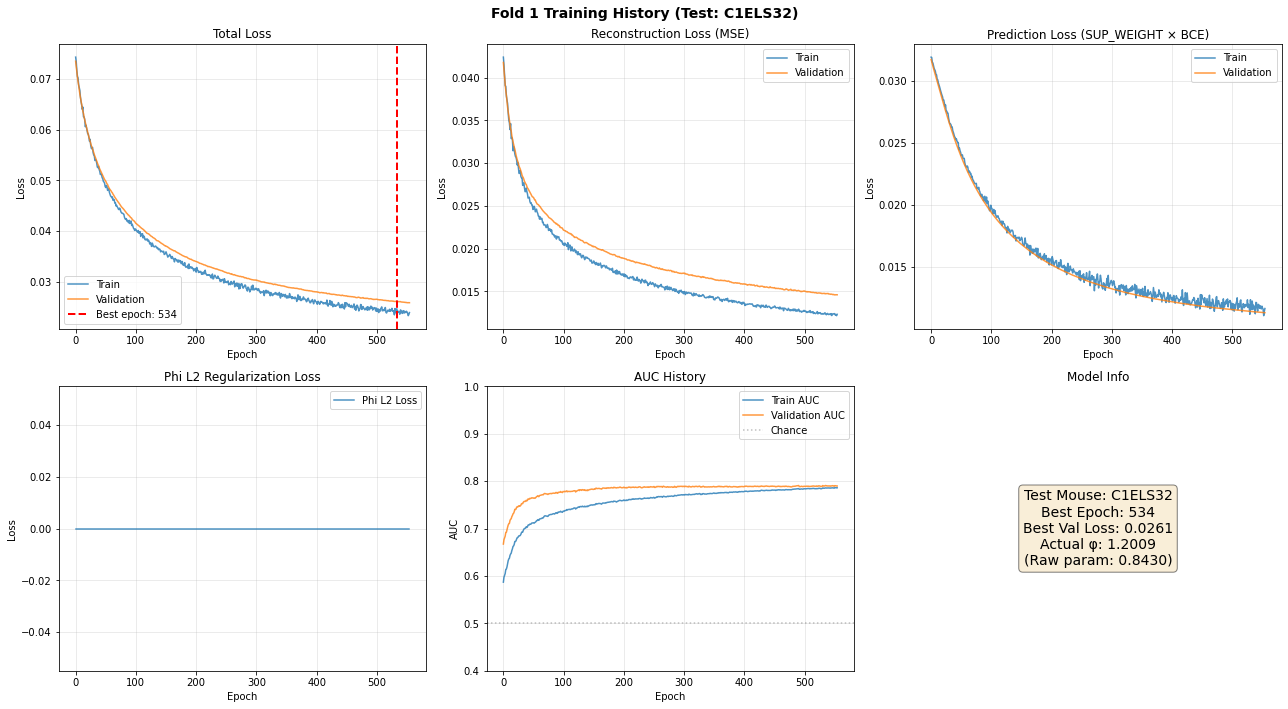

Testing model on mouse C1ELS32...
Test AUC for mouse C1ELS32: 0.4857

Fold 2/8: Test mouse = C2ELS18
Full training set: 12371 samples from 7 mice
Test set: 1061 samples from mouse C2ELS18
Test set - label=1: 43, label=0: 1018
After 90:10 split:
  Train: 11133 samples (label=1: 387, label=0: 10746)
  Val: 1238 samples (label=1: 43, label=0: 1195)
Training model for fold 2 with validation-based early stopping...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 178.78it/s]


Selecting network: 0 with auc 0.7699222016869687 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0123, pred=0.0136, phi=0.000000
             Val: recon=0.0140, pred=0.0138
             Best epoch so far: 394, Best val loss: 0.0279


Ep:500, Best:495, TrLoss:0.0243, ValLoss:0.0256, TrAUC:0.771, ValAUC:0.762:  84%


  [Epoch 500] Train: recon=0.0115, pred=0.0127, phi=0.000000
             Val: recon=0.0130, pred=0.0126
             Best epoch so far: 495, Best val loss: 0.0257


Ep:599, Best:582, TrLoss:0.0228, ValLoss:0.0243, TrAUC:0.773, ValAUC:0.764: 100%



  [Epoch 599] Train: recon=0.0108, pred=0.0119, phi=0.000000
             Val: recon=0.0123, pred=0.0119
             Best epoch so far: 582, Best val loss: 0.0245
Loading best model from epoch 582...
Done!
Best epoch for fold 2: 582


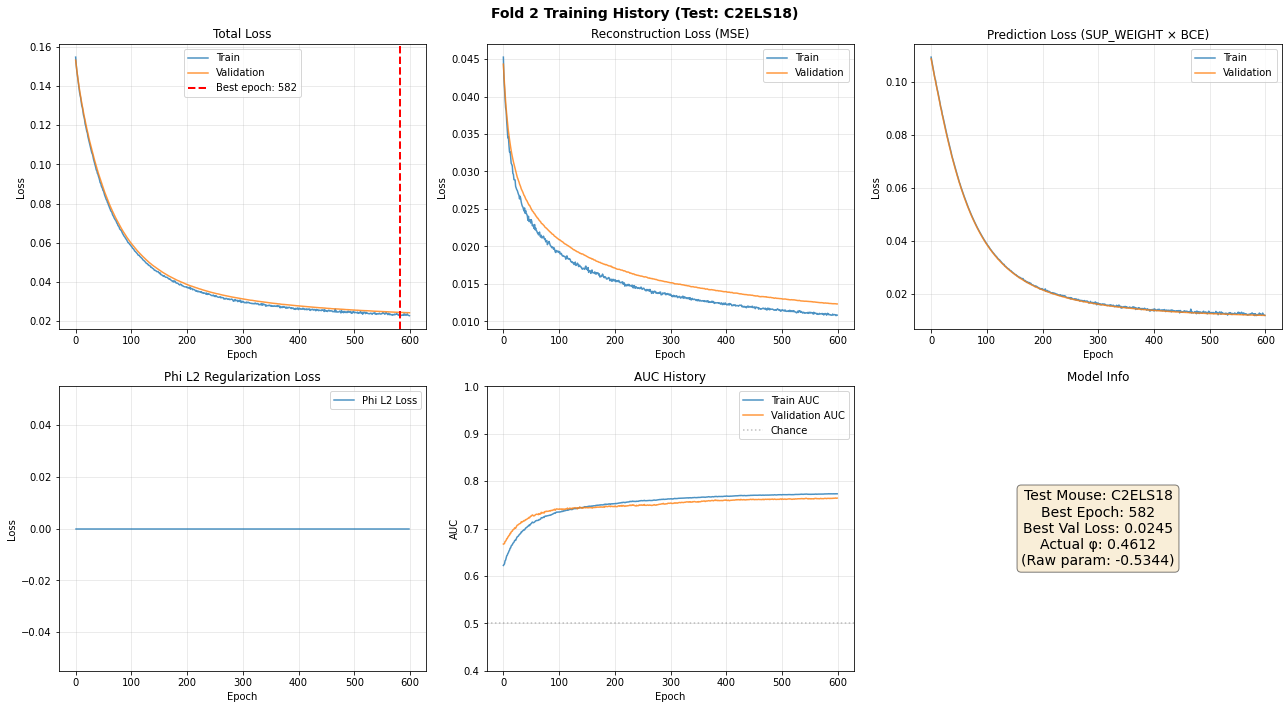

Testing model on mouse C2ELS18...
Test AUC for mouse C2ELS18: 0.8897

Fold 3/8: Test mouse = C5ELS20
Full training set: 11247 samples from 7 mice
Test set: 2185 samples from mouse C5ELS20
Test set - label=1: 45, label=0: 2140
After 90:10 split:
  Train: 10122 samples (label=1: 385, label=0: 9737)
  Val: 1125 samples (label=1: 43, label=0: 1082)
Training model for fold 3 with validation-based early stopping...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 189.48it/s]


Selecting network: 0 with auc 0.770915866509992 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0126, pred=0.0153, phi=0.000000
             Val: recon=0.0149, pred=0.0149
             Best epoch so far: 400, Best val loss: 0.0297


Ep:501, Best:492, TrLoss:0.0260, ValLoss:0.0274, TrAUC:0.788, ValAUC:0.782:  84%


  [Epoch 500] Train: recon=0.0119, pred=0.0139, phi=0.000000
             Val: recon=0.0138, pred=0.0135
             Best epoch so far: 492, Best val loss: 0.0276


Ep:599, Best:598, TrLoss:0.0242, ValLoss:0.0260, TrAUC:0.789, ValAUC:0.782: 100%



  [Epoch 599] Train: recon=0.0112, pred=0.0130, phi=0.000000
             Val: recon=0.0132, pred=0.0128
             Best epoch so far: 598, Best val loss: 0.0260
Loading best model from epoch 598...
Done!
Best epoch for fold 3: 598


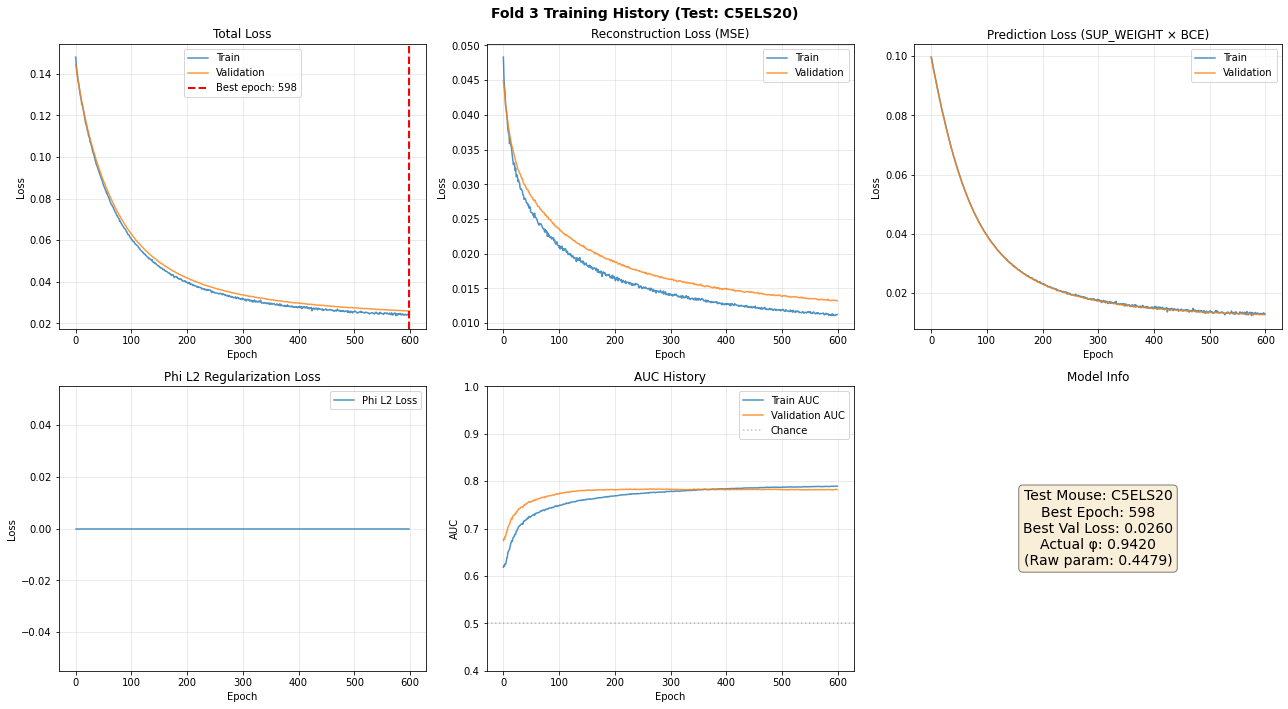

Testing model on mouse C5ELS20...
Test AUC for mouse C5ELS20: 0.7202

Fold 4/8: Test mouse = C5ELS40
Full training set: 11263 samples from 7 mice
Test set: 2169 samples from mouse C5ELS40
Test set - label=1: 137, label=0: 2032
After 90:10 split:
  Train: 10136 samples (label=1: 302, label=0: 9834)
  Val: 1127 samples (label=1: 34, label=0: 1093)
Training model for fold 4 with validation-based early stopping...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 184.96it/s]


Selecting network: 0 with auc 0.7719127584121583 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0124, pred=0.0123, phi=0.000000
             Val: recon=0.0145, pred=0.0118
             Best epoch so far: 399, Best val loss: 0.0263


Ep:501, Best:495, TrLoss:0.0232, ValLoss:0.0247, TrAUC:0.766, ValAUC:0.755:  84%


  [Epoch 500] Train: recon=0.0118, pred=0.0118, phi=0.000000
             Val: recon=0.0136, pred=0.0111
             Best epoch so far: 495, Best val loss: 0.0247


Ep:571, Best:552, TrLoss:0.0223, ValLoss:0.0239, TrAUC:0.768, ValAUC:0.754:  95%



*** Early stopping at epoch 572 ***
    No improvement > 0.0002 for 20 epochs
    Best epoch: 552, Best val loss: 0.0241
Loading best model from epoch 552...
Done!
Best epoch for fold 4: 552


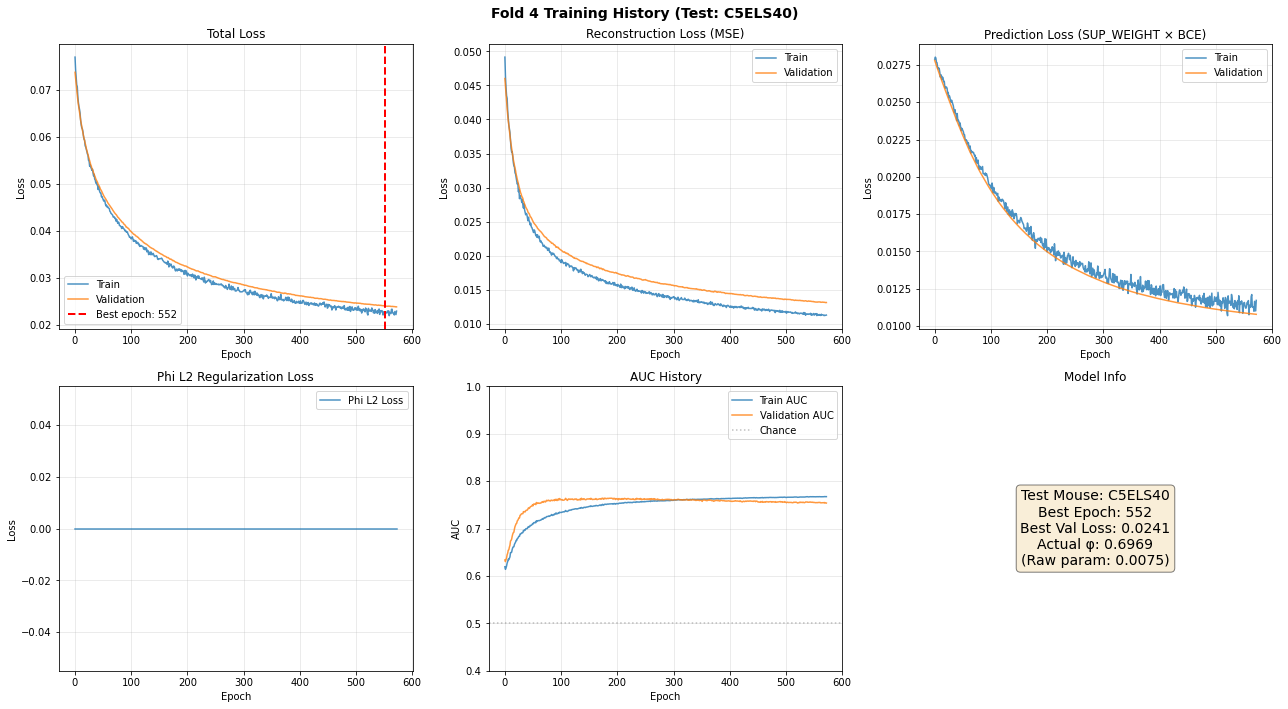

Testing model on mouse C5ELS40...
Test AUC for mouse C5ELS40: 0.8467

Fold 5/8: Test mouse = C6ELS42
Full training set: 11967 samples from 7 mice
Test set: 1465 samples from mouse C6ELS42
Test set - label=1: 75, label=0: 1390
After 90:10 split:
  Train: 10770 samples (label=1: 358, label=0: 10412)
  Val: 1197 samples (label=1: 40, label=0: 1157)
Training model for fold 5 with validation-based early stopping...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 185.96it/s]


Selecting network: 0 with auc 0.7822803833994725 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0123, pred=0.0156, phi=0.000000
             Val: recon=0.0141, pred=0.0150
             Best epoch so far: 400, Best val loss: 0.0291


Ep:500, Best:500, TrLoss:0.0250, ValLoss:0.0264, TrAUC:0.791, ValAUC:0.786:  84%


  [Epoch 500] Train: recon=0.0116, pred=0.0134, phi=0.000000
             Val: recon=0.0133, pred=0.0131
             Best epoch so far: 500, Best val loss: 0.0264


Ep:599, Best:594, TrLoss:0.0228, ValLoss:0.0247, TrAUC:0.791, ValAUC:0.785: 100%



  [Epoch 599] Train: recon=0.0107, pred=0.0122, phi=0.000000
             Val: recon=0.0126, pred=0.0121
             Best epoch so far: 594, Best val loss: 0.0249
Loading best model from epoch 594...
Done!
Best epoch for fold 5: 594


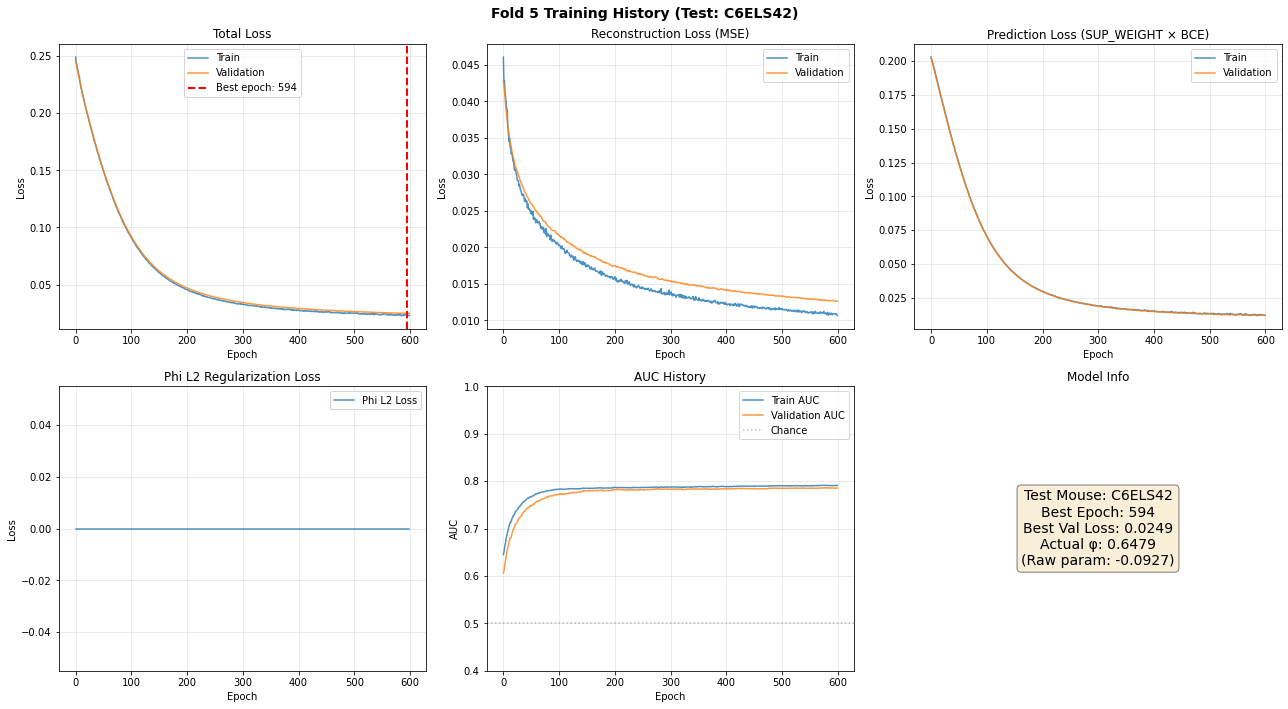

Testing model on mouse C6ELS42...
Test AUC for mouse C6ELS42: 0.6928

Fold 6/8: Test mouse = C7ELS11
Full training set: 12096 samples from 7 mice
Test set: 1336 samples from mouse C7ELS11
Test set - label=1: 28, label=0: 1308
After 90:10 split:
  Train: 10886 samples (label=1: 400, label=0: 10486)
  Val: 1210 samples (label=1: 45, label=0: 1165)
Training model for fold 6 with validation-based early stopping...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 175.59it/s]


Selecting network: 0 with auc 0.7628728781232119 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0119, pred=0.0146, phi=0.000000
             Val: recon=0.0148, pred=0.0145
             Best epoch so far: 396, Best val loss: 0.0293


Ep:500, Best:495, TrLoss:0.0253, ValLoss:0.0271, TrAUC:0.767, ValAUC:0.711:  84%


  [Epoch 500] Train: recon=0.0113, pred=0.0140, phi=0.000000
             Val: recon=0.0139, pred=0.0133
             Best epoch so far: 495, Best val loss: 0.0272


Ep:599, Best:597, TrLoss:0.0232, ValLoss:0.0257, TrAUC:0.767, ValAUC:0.711: 100%



  [Epoch 599] Train: recon=0.0107, pred=0.0125, phi=0.000000
             Val: recon=0.0131, pred=0.0126
             Best epoch so far: 597, Best val loss: 0.0257
Loading best model from epoch 597...
Done!
Best epoch for fold 6: 597


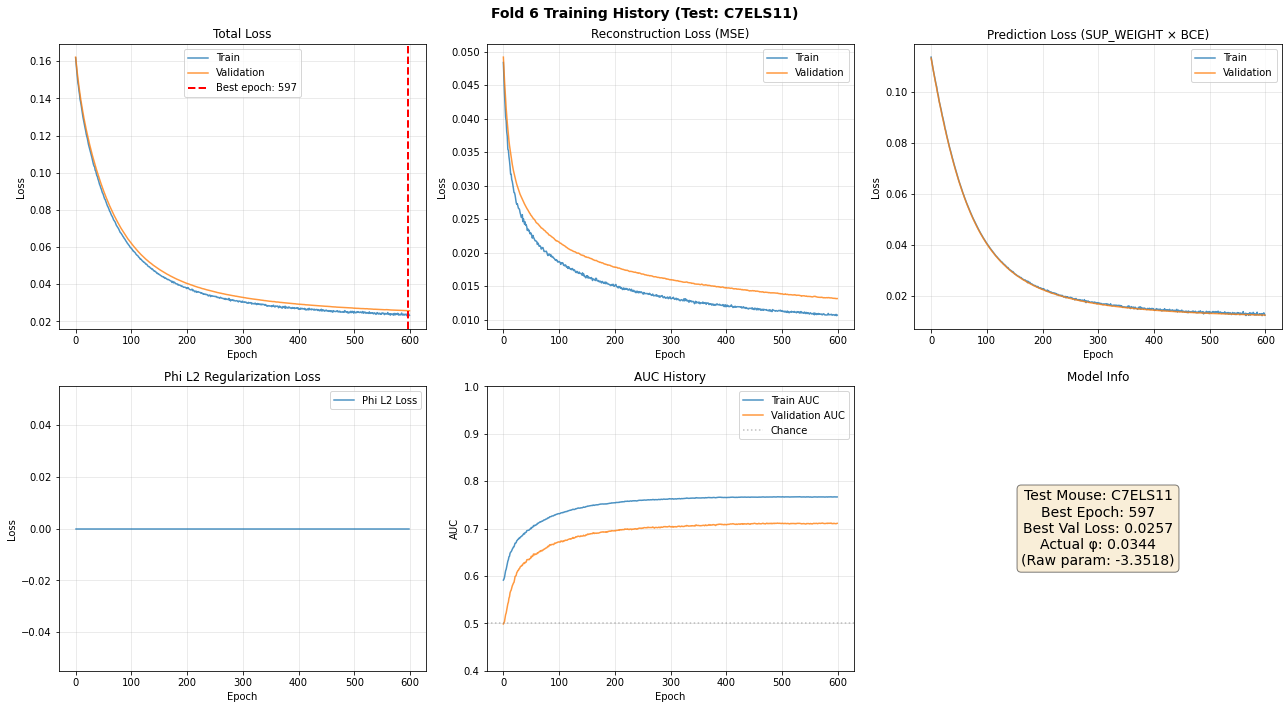

Testing model on mouse C7ELS11...
Test AUC for mouse C7ELS11: 0.9096

Fold 7/8: Test mouse = C7ELS22
Full training set: 10806 samples from 7 mice
Test set: 2626 samples from mouse C7ELS22
Test set - label=1: 23, label=0: 2603
After 90:10 split:
  Train: 9725 samples (label=1: 405, label=0: 9320)
  Val: 1081 samples (label=1: 45, label=0: 1036)
Training model for fold 7 with validation-based early stopping...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 204.18it/s]


Selecting network: 0 with auc 0.7500272876596196 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0127, pred=0.0155, phi=0.000000
             Val: recon=0.0146, pred=0.0155
             Best epoch so far: 393, Best val loss: 0.0302


Ep:501, Best:500, TrLoss:0.0259, ValLoss:0.0279, TrAUC:0.741, ValAUC:0.717:  84%


  [Epoch 500] Train: recon=0.0117, pred=0.0139, phi=0.000000
             Val: recon=0.0136, pred=0.0143
             Best epoch so far: 500, Best val loss: 0.0279


Ep:599, Best:584, TrLoss:0.0242, ValLoss:0.0266, TrAUC:0.747, ValAUC:0.723: 100%



  [Epoch 599] Train: recon=0.0111, pred=0.0131, phi=0.000000
             Val: recon=0.0130, pred=0.0135
             Best epoch so far: 584, Best val loss: 0.0267
Loading best model from epoch 584...
Done!
Best epoch for fold 7: 584


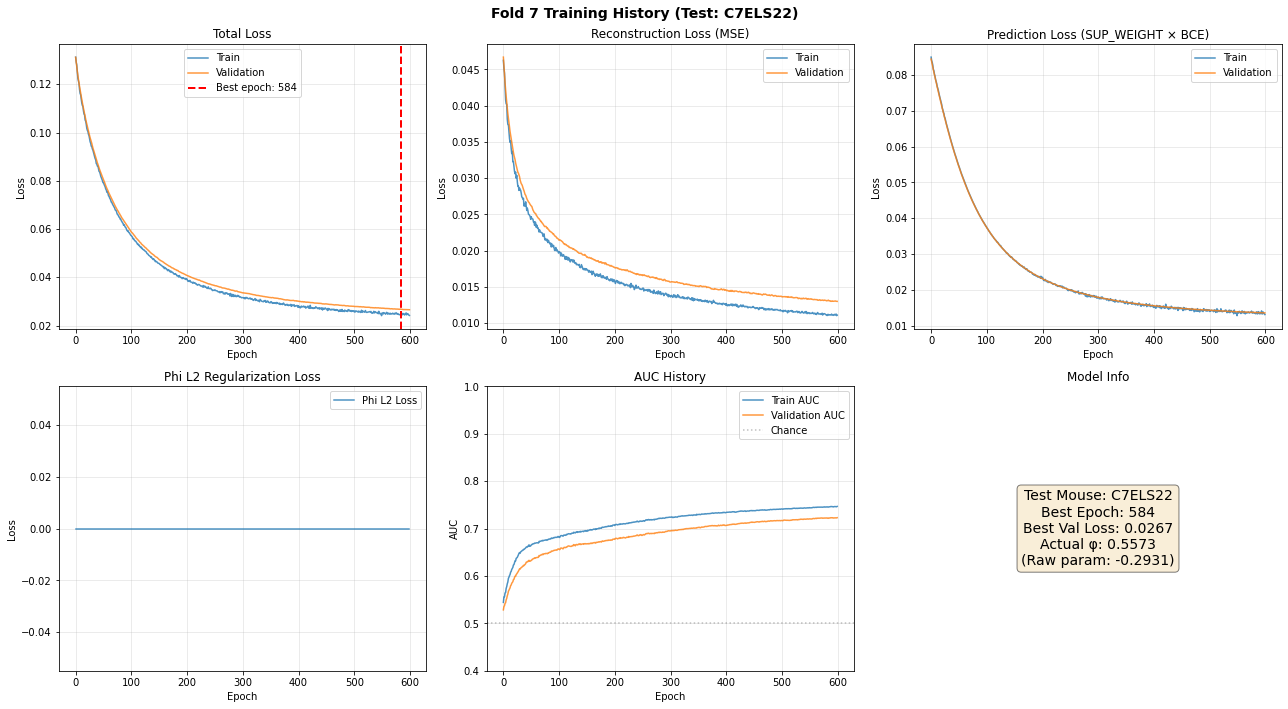

Testing model on mouse C7ELS22...
Test AUC for mouse C7ELS22: 0.8991

Fold 8/8: Test mouse = C7ELS45
Full training set: 12560 samples from 7 mice
Test set: 872 samples from mouse C7ELS45
Test set - label=1: 37, label=0: 835
After 90:10 split:
  Train: 11304 samples (label=1: 392, label=0: 10912)
  Val: 1256 samples (label=1: 44, label=0: 1212)
Training model for fold 8 with validation-based early stopping...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 176.42it/s]


Selecting network: 0 with auc 0.7755529860404572 for sup net 0 using constraint positive correlation


...


  [Epoch 400] Train: recon=0.0119, pred=0.0133, phi=0.000000
             Val: recon=0.0135, pred=0.0130
             Best epoch so far: 393, Best val loss: 0.0266


Ep:500, Best:498, TrLoss:0.0236, ValLoss:0.0248, TrAUC:0.786, ValAUC:0.809:  84%


  [Epoch 500] Train: recon=0.0113, pred=0.0123, phi=0.000000
             Val: recon=0.0127, pred=0.0121
             Best epoch so far: 498, Best val loss: 0.0249


Ep:550, Best:531, TrLoss:0.0230, ValLoss:0.0242, TrAUC:0.785, ValAUC:0.807:  92%


*** Early stopping at epoch 551 ***
    No improvement > 0.0002 for 20 epochs
    Best epoch: 531, Best val loss: 0.0244
Loading best model from epoch 531...
Done!
Best epoch for fold 8: 531


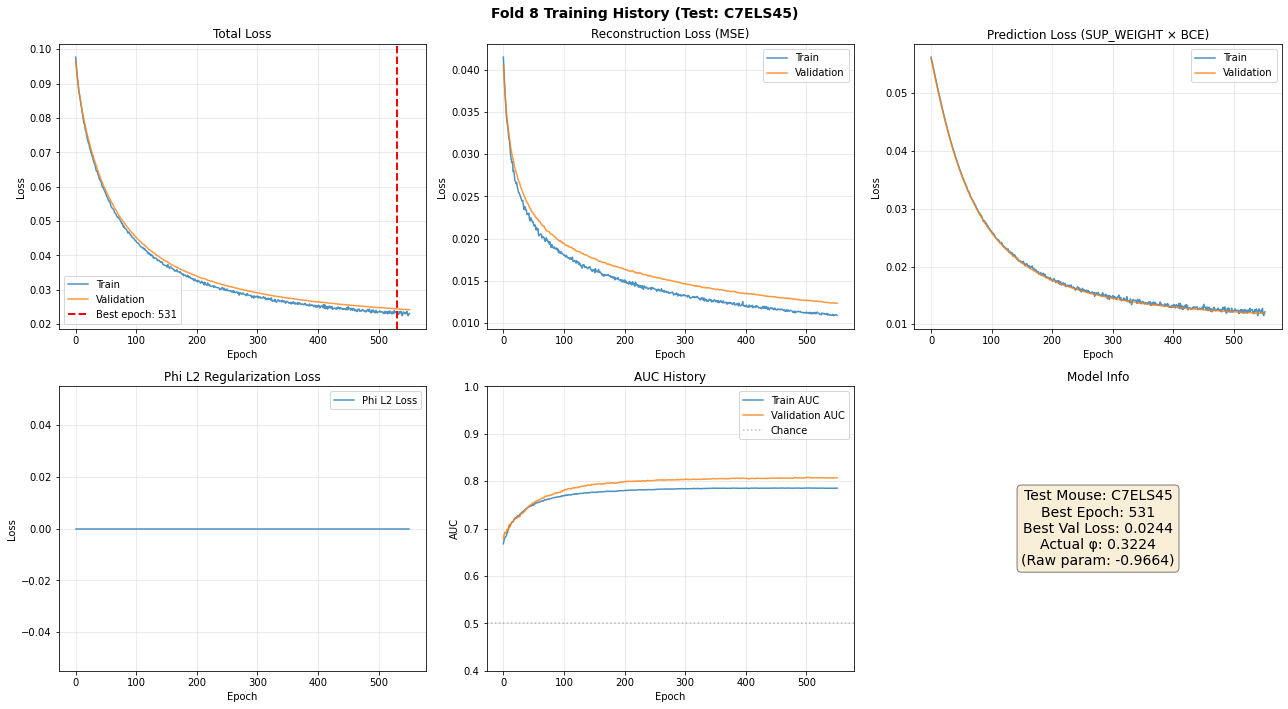

Testing model on mouse C7ELS45...
Test AUC for mouse C7ELS45: 0.8732

LEAVE-ONE-OUT VALIDATION SUMMARY

Cross-validation AUC: 0.7896 ± 0.0523 (mean ± SEM)
Standard deviation: 0.1480
Valid folds: 8/8

Best Epoch Statistics:
  All best epochs: [534, 582, 598, 552, 594, 597, 584, 531]
  Mean: 571.5
  Median: 583
  Min: 531, Max: 598

Per-mouse results:
  C1ELS32: AUC = 0.4857, best_epoch = 534, (n=1718, label=1: 85)
  C2ELS18: AUC = 0.8897, best_epoch = 582, (n=1061, label=1: 43)
  C5ELS20: AUC = 0.7202, best_epoch = 598, (n=2185, label=1: 45)
  C5ELS40: AUC = 0.8467, best_epoch = 552, (n=2169, label=1: 137)
  C6ELS42: AUC = 0.6928, best_epoch = 594, (n=1465, label=1: 75)
  C7ELS11: AUC = 0.9096, best_epoch = 597, (n=1336, label=1: 28)
  C7ELS22: AUC = 0.8991, best_epoch = 584, (n=2626, label=1: 23)
  C7ELS45: AUC = 0.8732, best_epoch = 531, (n=872, label=1: 37)

STATISTICAL ANALYSIS OF LOO CROSS-VALIDATION RESULTS

Number of mice: 8
Individual AUCs: [0.48565253 0.88968337 0.72015576 0.84

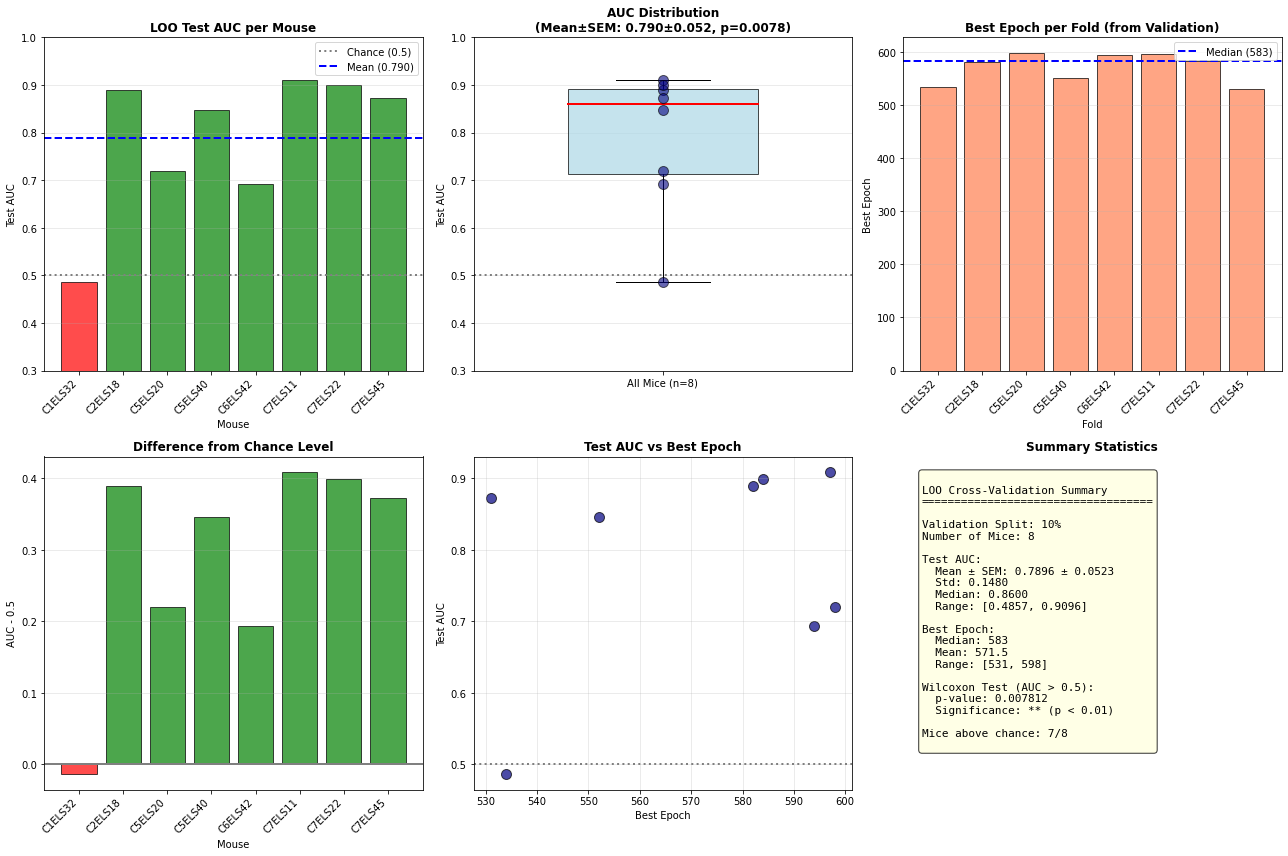

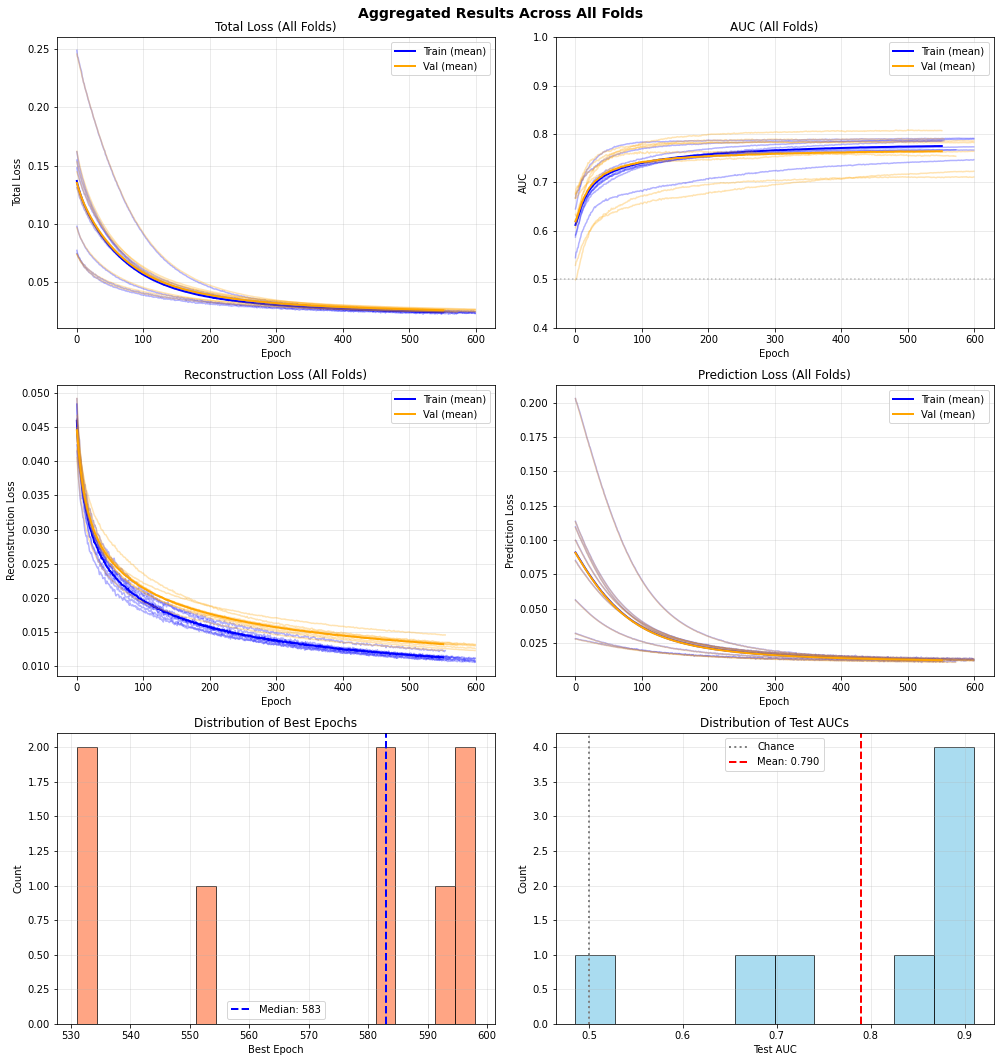


MODEL ARCHITECTURE AND PARAMETER SUMMARY (Fold 1)

--- DATA DIMENSIONS ---
  X_train shape: 10542 samples × 108 features
  X_val shape:   1172 samples × 108 features
  X_test shape:  1718 samples × 108 features
  Feature dimension (input): 108
  Number of components (latent): 10

--- TRAINING CONFIGURATION ---
  Batch size: 256
  Max epochs: 600
  Early stopping patience: 20
  Early stopping min_delta: 0.0002
  Optimizer: SGD
  Reconstruction loss: MSE
  SUP_WEIGHT (prediction loss weight): 0.07
  PHI_WEIGHT (phi L2 regularization): 0.0

--- ENCODER ARCHITECTURE ---
  Type: Deep Encoder (Neural Network)
  Structure:
    Layer 1: Linear(108 → 64)
             Parameters: 108 × 64 + 64 = 6,976
    Layer 2: BatchNorm1d(64)
             Parameters: 64 × 2 = 128
    Layer 3: LeakyReLU()
             Parameters: 0
    Layer 4: Linear(64 → 10)
             Parameters: 64 × 10 + 10 = 650
    Layer 5: Softplus()
             Parameters: 0
  Encoder Total Parameters: 7,754

--- DECODER (W_nmf) 

In [6]:
# ================================================================
# PART 1: Data Preparation
# ================================================================
import pickle
import numpy as np
import re
import os
import shutil
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import torch

# # Import the fixed model ( v1.3)
# from dCSFA_NMF_v1_3_fixed import dCSFA_NMF

# ================================================================
# Setup output directories and clean old files
# ================================================================
OUTPUT_DIR = "./results"
MODEL_CHECKPOINT_DIR = "./model_checkpoints"

# Create directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_CHECKPOINT_DIR, exist_ok=True)

# Clean old model checkpoint files to avoid filesystem issues
print("Cleaning old checkpoint files...")
for f in os.listdir(MODEL_CHECKPOINT_DIR):
    if f.endswith('.pt'):
        os.remove(os.path.join(MODEL_CHECKPOINT_DIR, f))
        print(f"  Removed {f}")
print("Cleanup complete.\n")

# Load data
FULL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P3_onnest_lick/full_onnest_lick_Trim.pkl"
with open(FULL_DATA_FILE, "rb") as f:
    full_dict = pickle.load(f)

def clean_mouse_id(mouse_id):
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

# Define target mouse_ids
target_mouse_ids = ['C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
                    'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
test_e_mouse_ids = ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']
all_target_mouse_ids = target_mouse_ids + test_e_mouse_ids

def create_dataset(full_dict, condition, target_mouse_ids, y_feature):
    """Create filtered dataset and split into C/E groups"""
    # Filter by condition
    selected_indices = np.where(condition)[0]
    filtered_dict = {key: (value[selected_indices] if isinstance(value, np.ndarray) and 
                          value.shape[0] == len(full_dict['onnest_raw']) else value) 
                     for key, value in full_dict.items()}
    
    # Filter by mouse_id
    cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in filtered_dict['mouse_id']])
    mouse_condition = np.isin(cleaned_mouse_ids, target_mouse_ids)
    mouse_indices = np.where(mouse_condition)[0]
    
    final_dict = {key: (value[mouse_indices] if isinstance(value, np.ndarray) and 
                       value.shape[0] == len(filtered_dict['onnest_raw']) else value) 
                  for key, value in filtered_dict.items()}
    
    # Build features and labels
    X = np.hstack([final_dict["power"], final_dict["coh_sq_coherence"]])
    y = final_dict[y_feature].reshape(-1, 1)
    y_sampling = OrdinalEncoder().fit_transform(final_dict["mouse_id"].reshape(-1, 1))
    y_intercept_mask = OneHotEncoder().fit_transform(final_dict["mouse_id"].reshape(-1, 1)).todense()
    mouse_ids = np.array([clean_mouse_id(mid) for mid in final_dict['mouse_id']])
    
    # Split by C/E
    c_mask = np.array([mid.startswith('C') for mid in mouse_ids])
    e_mask = np.array([mid.startswith('E') for mid in mouse_ids])
    
    return {
        'C': {'X': X[c_mask], 'y': y[c_mask], 'mouse_ids': mouse_ids[c_mask], 
              'y_sampling': y_sampling[c_mask], 'y_intercept_mask': y_intercept_mask[c_mask]},
        'E': {'X': X[e_mask], 'y': y[e_mask], 'mouse_ids': mouse_ids[e_mask],
              'y_sampling': y_sampling[e_mask], 'y_intercept_mask': y_intercept_mask[e_mask]}
    }

print("Creating datasets...")

# Create Licking dataset: onnest=1 ONLY, label=licking
print("Licking dataset: Licking during Onnest (1) vs NonLicking during Onnest (0)")
print("Condition: (full_dict['onnest_raw'] == 1)")
licking_data = create_dataset(full_dict, 
                             (full_dict['onnest_raw'] == 1),  # ONLY onnest=1
                             all_target_mouse_ids, 'licking')

# Create Onnest dataset: licking=0 only, label=onnest_raw  
print("\nOnnest dataset: remove all licking, remaining Onnest (1) vs Offnest (0)")
onnest_data = create_dataset(full_dict, 
                            full_dict['licking'] == 0,
                            all_target_mouse_ids, 'onnest_raw')

# Extract datasets
X_Licking_C, y_Licking_C, mouse_ids_Licking_C = licking_data['C']['X'], licking_data['C']['y'], licking_data['C']['mouse_ids']
y_sampling_Licking_C, y_intercept_mask_Licking_C = licking_data['C']['y_sampling'], licking_data['C']['y_intercept_mask']

X_Licking_E, y_Licking_E, mouse_ids_Licking_E = licking_data['E']['X'], licking_data['E']['y'], licking_data['E']['mouse_ids']
y_sampling_Licking_E, y_intercept_mask_Licking_E = licking_data['E']['y_sampling'], licking_data['E']['y_intercept_mask']

X_Onnest_C, y_Onnest_C, mouse_ids_Onnest_C = onnest_data['C']['X'], onnest_data['C']['y'], onnest_data['C']['mouse_ids']
y_sampling_Onnest_C, y_intercept_mask_Onnest_C = onnest_data['C']['y_sampling'], onnest_data['C']['y_intercept_mask']

X_Onnest_E, y_Onnest_E, mouse_ids_Onnest_E = onnest_data['E']['X'], onnest_data['E']['y'], onnest_data['E']['mouse_ids']
y_sampling_Onnest_E, y_intercept_mask_Onnest_E = onnest_data['E']['y_sampling'], onnest_data['E']['y_intercept_mask']

# Print dataset statistics
datasets = [
    ("Licking_C", X_Licking_C, y_Licking_C, mouse_ids_Licking_C, "licking"),
    ("Licking_E", X_Licking_E, y_Licking_E, mouse_ids_Licking_E, "licking"),
    ("Onnest_C", X_Onnest_C, y_Onnest_C, mouse_ids_Onnest_C, "onnest"),
    ("Onnest_E", X_Onnest_E, y_Onnest_E, mouse_ids_Onnest_E, "onnest")
]

print("\nDataset Statistics:")
for name, X, y, mouse_ids, label_type in datasets:
    print(f"\n{name}: {X.shape[0]} samples, {label_type}=1: {np.sum(y == 1)}, {label_type}=0: {np.sum(y == 0)}")
    unique_ids, counts = np.unique(mouse_ids, return_counts=True)
    for mouse_id, count in zip(unique_ids, counts):
        label_1_count = np.sum(y[mouse_ids == mouse_id] == 1)
        print(f"  {mouse_id}: {count} samples ({label_type}=1: {label_1_count})")

print(f"\nDatasets created successfully!")


# ================================================================
# PART 2: Leave-One-Out Cross-Validation with Validation Split
# ================================================================

def plot_training_history(model, fold_idx, test_mouse, save_path=None):
    """
    Plot training and validation loss history for a single fold.
    is mean  value，
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Total Loss
    axes[0, 0].plot(model.train_total_hist, label='Train', alpha=0.8, linewidth=1.5)
    if len(model.val_total_hist) > 0:
        axes[0, 0].plot(model.val_total_hist, label='Validation', alpha=0.8, linewidth=1.5)
        if hasattr(model, 'best_epoch'):
            axes[0, 0].axvline(x=model.best_epoch, color='r', linestyle='--', 
                              linewidth=2, label=f'Best epoch: {model.best_epoch}')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Reconstruction Loss
    axes[0, 1].plot(model.train_recon_hist, label='Train', alpha=0.8, linewidth=1.5)
    if len(model.val_recon_hist) > 0:
        axes[0, 1].plot(model.val_recon_hist, label='Validation', alpha=0.8, linewidth=1.5)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Reconstruction Loss (MSE)')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Prediction Loss
    axes[0, 2].plot(model.train_pred_hist, label='Train', alpha=0.8, linewidth=1.5)
    if len(model.val_pred_hist) > 0:
        axes[0, 2].plot(model.val_pred_hist, label='Validation', alpha=0.8, linewidth=1.5)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].set_title('Prediction Loss (SUP_WEIGHT × BCE)')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)
    
    # Phi L2 Loss
    if hasattr(model, 'train_phi_loss_hist') and len(model.train_phi_loss_hist) > 0:
        axes[1, 0].plot(model.train_phi_loss_hist, label='Phi L2 Loss', alpha=0.8, linewidth=1.5)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Phi L2 Regularization Loss')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Phi L2 Loss\n(phi_weight=0)', 
                       ha='center', va='center', fontsize=12)
        axes[1, 0].set_title('Phi L2 Regularization Loss')
    
    # AUC History
    if hasattr(model, 'train_auc_hist') and len(model.train_auc_hist) > 0:
        train_aucs = [auc[0] for auc in model.train_auc_hist]
        axes[1, 1].plot(train_aucs, label='Train AUC', alpha=0.8, linewidth=1.5)
        if hasattr(model, 'val_auc_hist') and len(model.val_auc_hist) > 0:
            val_aucs = [auc[0] for auc in model.val_auc_hist]
            axes[1, 1].plot(val_aucs, label='Validation AUC', alpha=0.8, linewidth=1.5)
        axes[1, 1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('AUC')
        axes[1, 1].set_title('AUC History')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
        axes[1, 1].set_ylim([0.4, 1.0])
    
    # Model Info
    info_text = f"Test Mouse: {test_mouse}\n"
    if hasattr(model, 'best_epoch'):
        info_text += f"Best Epoch: {model.best_epoch}\n"
    if hasattr(model, 'best_val_loss'):
        info_text += f"Best Val Loss: {model.best_val_loss:.4f}\n"
    if hasattr(model, 'phi_list'):
        #  phi（）
        actual_phi = model.get_phi(0).item()
        raw_phi = model.phi_list[0].item()
        info_text += f"Actual φ: {actual_phi:.4f}\n"
        info_text += f"(Raw param: {raw_phi:.4f})"
    
    axes[1, 2].text(0.5, 0.5, info_text, transform=axes[1, 2].transAxes,
                   fontsize=14, verticalalignment='center', horizontalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].set_title('Model Info')
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Fold {fold_idx+1} Training History (Test: {test_mouse})', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


def leave_one_out_validation_with_val_split(X, y, mouse_ids, y_sampling, y_intercept_mask, 
                                            model_params, training_params, 
                                            val_split=0.1, seed=2025):
    """
    Perform leave-one-out cross-validation by mouse.
    Within each LOO fold, split 10% of training data as validation for epoch selection.
    
    Parameters
    ----------
    X : array-like
        Features
    y : array-like
        Labels
    mouse_ids : array-like
        Mouse IDs for each sample
    y_sampling : array-like
        Sampling groups
    y_intercept_mask : array-like
        Intercept mask
    model_params : dict
        Model initialization parameters
    training_params : dict
        Training parameters
    val_split : float
        Fraction of training data to use for validation (default: 0.1)
    seed : int
        Random seed
    
    Returns
    -------
    results : dict
        Per-mouse results
    valid_aucs : list
        List of valid test AUCs
    all_best_epochs : list
        List of best epochs from each fold
    """
    unique_mice = np.unique(mouse_ids)
    print(f"\n{'='*80}")
    print(f"LEAVE-ONE-OUT CROSS-VALIDATION WITH {int(val_split*100)}% VALIDATION SPLIT")
    print(f"{'='*80}")
    print(f"Performing validation with {len(unique_mice)} mice...")
    print(f"Each fold: {int((1-val_split)*100)}% train, {int(val_split*100)}% validation")
    
    results = {}
    all_test_aucs = []
    all_best_epochs = []
    all_models = []
    
    for i, test_mouse in enumerate(unique_mice):
        print(f"\n{'='*60}")
        print(f"Fold {i+1}/{len(unique_mice)}: Test mouse = {test_mouse}")
        print(f"{'='*60}")
        
        # Split data: test mouse vs rest
        test_mask = mouse_ids == test_mouse
        train_full_mask = ~test_mask
        
        # Full training data (7 mice)
        X_train_full = X[train_full_mask]
        y_train_full = y[train_full_mask]
        mouse_ids_train_full = mouse_ids[train_full_mask]
        y_sampling_train_full = y_sampling[train_full_mask]
        
        # Test data (1 mouse)
        X_test = X[test_mask]
        y_test = y[test_mask]
        
        print(f"Full training set: {X_train_full.shape[0]} samples from {len(np.unique(mouse_ids_train_full))} mice")
        print(f"Test set: {X_test.shape[0]} samples from mouse {test_mouse}")
        print(f"Test set - label=1: {np.sum(y_test == 1)}, label=0: {np.sum(y_test == 0)}")
        
        # ========== 90:10 Split for Validation (sample-level, not mouse-level) ==========
        fold_seed = seed + i
        np.random.seed(fold_seed)
        torch.manual_seed(fold_seed)
        torch.cuda.manual_seed_all(fold_seed)
        
        # Stratified split to maintain class balance
        try:
            X_train, X_val, y_train, y_val, mouse_ids_train, mouse_ids_val, y_samp_train, y_samp_val = \
                train_test_split(
                    X_train_full, y_train_full, mouse_ids_train_full, y_sampling_train_full,
                    test_size=val_split,
                    random_state=fold_seed,
                    stratify=y_train_full.squeeze()
                )
        except ValueError as e:
            # If stratification fails (e.g., too few samples of one class), use non-stratified
            print(f"Warning: Stratified split failed, using random split. Error: {e}")
            X_train, X_val, y_train, y_val, mouse_ids_train, mouse_ids_val, y_samp_train, y_samp_val = \
                train_test_split(
                    X_train_full, y_train_full, mouse_ids_train_full, y_sampling_train_full,
                    test_size=val_split,
                    random_state=fold_seed
                )
        
        print(f"After {int((1-val_split)*100)}:{int(val_split*100)} split:")
        print(f"  Train: {X_train.shape[0]} samples (label=1: {np.sum(y_train==1)}, label=0: {np.sum(y_train==0)})")
        print(f"  Val: {X_val.shape[0]} samples (label=1: {np.sum(y_val==1)}, label=0: {np.sum(y_val==0)})")
        
        # Re-encode y_sampling for training set
        y_sampling_encoder = OrdinalEncoder()
        y_sampling_train_encoded = y_sampling_encoder.fit_transform(mouse_ids_train.reshape(-1, 1))
        
        # Create model
        model = dCSFA_NMF(**model_params)
        
        # Prepare training params with validation data
        train_params_with_val = training_params.copy()
        train_params_with_val['X_val'] = X_val
        train_params_with_val['y_val'] = y_val
        
        # save，file
        train_params_with_val['best_model_name'] = os.path.join(MODEL_CHECKPOINT_DIR, f"best_model_fold{i}_test_{test_mouse}.pt")
        
        # Train model
        print(f"Training model for fold {i+1} with validation-based early stopping...")
        model.fit(X_train, y_train,
                 y_sample_groups=y_sampling_train_encoded.squeeze(),
                 y_pred_weights=None,
                 intercept_mask=None,
                 task_mask=None,
                 **train_params_with_val)
        
        # Record best epoch
        best_epoch = model.best_epoch if hasattr(model, 'best_epoch') else training_params['n_epochs']
        all_best_epochs.append(best_epoch)
        print(f"Best epoch for fold {i+1}: {best_epoch}")
        
        # Plot training history
        plot_training_history(model, i, test_mouse, 
                            save_path=f'training_history_fold{i+1}_{test_mouse}.png')
        
        # Store model
        all_models.append(model)
        
        # ========== Test on held-out mouse ==========
        print(f"Testing model on mouse {test_mouse}...")
        
        # Skip if test set has only one class
        if len(np.unique(y_test)) <= 1:
            print(f"Skipping mouse {test_mouse} - only one class in test set")
            results[test_mouse] = {
                'test_auc': None,
                'test_samples': X_test.shape[0],
                'test_label_1': int(np.sum(y_test == 1)),
                'test_label_0': int(np.sum(y_test == 0)),
                'best_epoch': best_epoch
            }
            continue
        
        # Calculate test AUC
        model.eval()
        y_pred_proba, s_test = model.predict_proba(X_test, include_scores=True)
        test_auc = roc_auc_score(y_test, y_pred_proba)
        all_test_aucs.append(test_auc)
        
        print(f"Test AUC for mouse {test_mouse}: {test_auc:.4f}")
        
        # Store results
        results[test_mouse] = {
            'test_auc': test_auc,
            'test_samples': X_test.shape[0],
            'test_label_1': int(np.sum(y_test == 1)),
            'test_label_0': int(np.sum(y_test == 0)),
            'best_epoch': best_epoch,
            'best_val_loss': model.best_val_loss if hasattr(model, 'best_val_loss') else None,
            'y_pred_proba': y_pred_proba,
            'y_true': y_test,
            # ： get_phi()  value，is
            'phi_value': model.get_phi(0).item() if hasattr(model, 'phi_list') else None,
            'phi_raw': model.phi_list[0].item() if hasattr(model, 'phi_list') else None  # （）
        }
    
    # ========== Summary ==========
    print(f"\n{'='*80}")
    print("LEAVE-ONE-OUT VALIDATION SUMMARY")
    print(f"{'='*80}")
    
    valid_aucs = [auc for auc in all_test_aucs if auc is not None]
    if valid_aucs:
        mean_auc = np.mean(valid_aucs)
        std_auc = np.std(valid_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(valid_aucs))
        print(f"\nCross-validation AUC: {mean_auc:.4f} ± {sem_auc:.4f} (mean ± SEM)")
        print(f"Standard deviation: {std_auc:.4f}")
        print(f"Valid folds: {len(valid_aucs)}/{len(unique_mice)}")
        
        print(f"\nBest Epoch Statistics:")
        print(f"  All best epochs: {all_best_epochs}")
        print(f"  Mean: {np.mean(all_best_epochs):.1f}")
        print(f"  Median: {int(np.median(all_best_epochs))}")
        print(f"  Min: {min(all_best_epochs)}, Max: {max(all_best_epochs)}")
        
        print(f"\nPer-mouse results:")
        for mouse, result in results.items():
            if result['test_auc'] is not None:
                print(f"  {mouse}: AUC = {result['test_auc']:.4f}, "
                      f"best_epoch = {result['best_epoch']}, "
                      f"(n={result['test_samples']}, label=1: {result['test_label_1']})")
            else:
                print(f"  {mouse}: skipped - single class "
                      f"(n={result['test_samples']}, label=1: {result['test_label_1']})")
    else:
        print("No valid AUC scores calculated - all test sets had single class")
    
    return results, valid_aucs, all_best_epochs, all_models


# ================================================================
# Model and Training Parameters
# ================================================================

# Model parameters
model_params = {
    'n_components': 10,
    'dim_in': X_Licking_C.shape[1],
    'n_sup_networks': 1,
    'optim_name': "SGD",
    'recon_loss': "MSE",
    'sup_recon_weight': 0.0,
    'sup_weight': 0.07,
    'phi_weight': 0.0,  # Set > 0 to use phi L2 regularization
    'n_intercepts': 1,
    'useDeepEnc': True,
    'h': 64,
    'sup_recon_type': "Residual",
    'feature_groups': None,
    'group_weights': None,
    'fixed_corr': "Positive",
    'momentum': 0.9,
    'sup_smoothness_weight': 1
}

# Training parameters
training_params = {
    'n_epochs': 600,
    'n_pre_epochs': 100,
    'nmf_max_iter': 500,
    'batch_size': 256,
    'lr': 1e-3,
    'pretrain': True,
    'verbose': True,
    # Early stopping parameters
    'patience': 20,      # Stop if no improvement for 100 epochs (set None to disable)
    'min_delta': 2e-4,    # Minimum improvement to count as "improvement"
}

# Validation split
VAL_SPLIT = 0.1  # 10% validation
SEED = 2025

# ================================================================
# Run Leave-One-Out Validation with Validation Split
# ================================================================

print(f"\nDataset ready: {X_Licking_C.shape[0]} samples from {len(np.unique(mouse_ids_Licking_C))} mice")
print("Starting leave-one-out cross-validation with validation split...")

loo_results, valid_aucs, all_best_epochs, all_models = leave_one_out_validation_with_val_split(
    X_Licking_C, y_Licking_C, mouse_ids_Licking_C, 
    y_sampling_Licking_C, y_intercept_mask_Licking_C,
    model_params, training_params,
    val_split=VAL_SPLIT,
    seed=SEED
)


# ================================================================
# PART 3: Statistical Analysis
# ================================================================

# Convert to numpy array for analysis
individual_aucs = np.array(valid_aucs)
n_mice = len(individual_aucs)

print(f"\n{'='*80}")
print("STATISTICAL ANALYSIS OF LOO CROSS-VALIDATION RESULTS")
print(f"{'='*80}")

# Calculate statistics
mean_auc = individual_aucs.mean()
std_auc = individual_aucs.std(ddof=1)
sem_auc = individual_aucs.std(ddof=1) / np.sqrt(n_mice)
median_auc = np.median(individual_aucs)

print(f"\nNumber of mice: {n_mice}")
print(f"Individual AUCs: {individual_aucs}")
print(f"\nMean AUC: {mean_auc:.4f} ± {sem_auc:.4f} (SEM)")
print(f"Standard Deviation: {std_auc:.4f}")
print(f"Median AUC: {median_auc:.4f}")
print(f"Min AUC: {individual_aucs.min():.4f}")
print(f"Max AUC: {individual_aucs.max():.4f}")

# Best epoch statistics
print(f"\nBest Epoch Statistics:")
print(f"  Median best epoch: {int(np.median(all_best_epochs))}")
print(f"  Mean best epoch: {np.mean(all_best_epochs):.1f}")
print(f"  Recommended epoch for final model: {int(np.median(all_best_epochs))}")

# Wilcoxon signed-rank test (one-sided) against 0.5
print(f"\n{'='*80}")
print("WILCOXON SIGNED-RANK TEST")
print(f"{'='*80}")

differences = individual_aucs - 0.5
print(f"\nDifferences from chance (0.5): {differences}")

statistic, p_value = wilcoxon(differences, alternative='greater')

print(f"\nWilcoxon Signed-Rank Test (one-sided)")
print(f"H0: Population true AUC = 0.5 (chance level)")
print(f"H1: Population true AUC > 0.5")
print(f"\nTest Statistic: {statistic}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.001:
    significance = "*** (p < 0.001)"
elif p_value < 0.01:
    significance = "** (p < 0.01)"
elif p_value < 0.05:
    significance = "* (p < 0.05)"
else:
    significance = "ns (not significant)"

print(f"Significance: {significance}")

n_above_chance = np.sum(individual_aucs > 0.5)
print(f"\nNumber of mice with AUC > 0.5: {n_above_chance}/{n_mice}")


# ================================================================
# PART 4: Visualization
# ================================================================

# Figure 1: Summary Results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Bar plot of individual test AUCs
mice_names = list(loo_results.keys())
mice_aucs = [loo_results[m]['test_auc'] if loo_results[m]['test_auc'] is not None else 0 
             for m in mice_names]
colors = ['green' if auc > 0.5 else 'red' for auc in mice_aucs]

axes[0, 0].bar(range(len(mice_names)), mice_aucs, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].axhline(y=0.5, color='gray', linestyle=':', linewidth=2, label='Chance (0.5)')
axes[0, 0].axhline(y=mean_auc, color='blue', linestyle='--', linewidth=2, 
                  label=f'Mean ({mean_auc:.3f})')
axes[0, 0].set_xlabel('Mouse')
axes[0, 0].set_ylabel('Test AUC')
axes[0, 0].set_title('LOO Test AUC per Mouse', fontweight='bold')
axes[0, 0].set_xticks(range(len(mice_names)))
axes[0, 0].set_xticklabels(mice_names, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')
axes[0, 0].set_ylim([0.3, 1.0])

# Plot 2: Box plot with individual points
axes[0, 1].boxplot([individual_aucs], widths=0.5, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
axes[0, 1].scatter(np.ones(n_mice), individual_aucs, 
                  alpha=0.6, s=100, color='navy', edgecolors='black', zorder=3)
axes[0, 1].axhline(y=0.5, color='gray', linestyle=':', linewidth=2)
axes[0, 1].set_ylabel('Test AUC')
axes[0, 1].set_title(f'AUC Distribution\n(Mean±SEM: {mean_auc:.3f}±{sem_auc:.3f}, p={p_value:.4f})',
                    fontweight='bold')
axes[0, 1].set_xticks([1])
axes[0, 1].set_xticklabels([f'All Mice (n={n_mice})'])
axes[0, 1].grid(alpha=0.3, axis='y')
axes[0, 1].set_ylim([0.3, 1.0])

# Plot 3: Best epochs per fold
axes[0, 2].bar(range(len(all_best_epochs)), all_best_epochs, color='coral', 
              edgecolor='black', alpha=0.7)
axes[0, 2].axhline(y=np.median(all_best_epochs), color='blue', linestyle='--', 
                  linewidth=2, label=f'Median ({int(np.median(all_best_epochs))})')
axes[0, 2].set_xlabel('Fold')
axes[0, 2].set_ylabel('Best Epoch')
axes[0, 2].set_title('Best Epoch per Fold (from Validation)', fontweight='bold')
axes[0, 2].set_xticks(range(len(all_best_epochs)))
axes[0, 2].set_xticklabels(mice_names, rotation=45, ha='right')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3, axis='y')

# Plot 4: Differences from chance
diff_colors = ['green' if d > 0 else 'red' for d in differences]
axes[1, 0].bar(range(n_mice), differences, color=diff_colors, edgecolor='black', alpha=0.7)
axes[1, 0].axhline(y=0, color='gray', linestyle='-', linewidth=2)
axes[1, 0].set_xlabel('Mouse')
axes[1, 0].set_ylabel('AUC - 0.5')
axes[1, 0].set_title('Difference from Chance Level', fontweight='bold')
axes[1, 0].set_xticks(range(n_mice))
axes[1, 0].set_xticklabels(mice_names, rotation=45, ha='right')
axes[1, 0].grid(alpha=0.3, axis='y')

# Plot 5: AUC vs Best Epoch scatter
best_epochs_valid = [loo_results[m]['best_epoch'] for m in mice_names 
                    if loo_results[m]['test_auc'] is not None]
aucs_valid = [loo_results[m]['test_auc'] for m in mice_names 
             if loo_results[m]['test_auc'] is not None]
axes[1, 1].scatter(best_epochs_valid, aucs_valid, s=100, alpha=0.7, 
                  c='navy', edgecolors='black')
axes[1, 1].axhline(y=0.5, color='gray', linestyle=':', linewidth=2)
axes[1, 1].set_xlabel('Best Epoch')
axes[1, 1].set_ylabel('Test AUC')
axes[1, 1].set_title('Test AUC vs Best Epoch', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Plot 6: Summary text
summary_text = f"""
LOO Cross-Validation Summary
{'='*35}

Validation Split: {int(VAL_SPLIT*100)}%
Number of Mice: {n_mice}

Test AUC:
  Mean ± SEM: {mean_auc:.4f} ± {sem_auc:.4f}
  Std: {std_auc:.4f}
  Median: {median_auc:.4f}
  Range: [{individual_aucs.min():.4f}, {individual_aucs.max():.4f}]

Best Epoch:
  Median: {int(np.median(all_best_epochs))}
  Mean: {np.mean(all_best_epochs):.1f}
  Range: [{min(all_best_epochs)}, {max(all_best_epochs)}]

Wilcoxon Test (AUC > 0.5):
  p-value: {p_value:.6f}
  Significance: {significance}

Mice above chance: {n_above_chance}/{n_mice}
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes,
               fontsize=11, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].set_title('Summary Statistics', fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('loo_validation_summary.png', dpi=300, bbox_inches='tight')
plt.show()


# ================================================================
# Figure 2: Aggregated Training Curves (Optional)
# ================================================================

def plot_aggregated_training_curves(all_models, save_path=None):
    """Plot aggregated training curves from all folds."""
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    
    # Collect all curves
    all_train_total = []
    all_val_total = []
    all_train_recon = []
    all_val_recon = []
    all_train_pred = []
    all_val_pred = []
    all_train_auc = []
    all_val_auc = []
    
    for model in all_models:
        if hasattr(model, 'train_total_hist'):
            all_train_total.append(model.train_total_hist)
        if hasattr(model, 'val_total_hist') and len(model.val_total_hist) > 0:
            all_val_total.append(model.val_total_hist)
        if hasattr(model, 'train_recon_hist'):
            all_train_recon.append(model.train_recon_hist)
        if hasattr(model, 'val_recon_hist') and len(model.val_recon_hist) > 0:
            all_val_recon.append(model.val_recon_hist)
        if hasattr(model, 'train_pred_hist'):
            all_train_pred.append(model.train_pred_hist)
        if hasattr(model, 'val_pred_hist') and len(model.val_pred_hist) > 0:
            all_val_pred.append(model.val_pred_hist)
        if hasattr(model, 'train_auc_hist') and len(model.train_auc_hist) > 0:
            all_train_auc.append([a[0] for a in model.train_auc_hist])
        if hasattr(model, 'val_auc_hist') and len(model.val_auc_hist) > 0:
            all_val_auc.append([a[0] for a in model.val_auc_hist])
    
    # Plot 1: Total Loss
    for i, curve in enumerate(all_train_total):
        axes[0, 0].plot(curve, alpha=0.3, color='blue')
    if all_train_total:
        min_len = min(len(c) for c in all_train_total)
        mean_curve = np.mean([c[:min_len] for c in all_train_total], axis=0)
        axes[0, 0].plot(mean_curve, color='blue', linewidth=2, label='Train (mean)')
    
    for i, curve in enumerate(all_val_total):
        axes[0, 0].plot(curve, alpha=0.3, color='orange')
    if all_val_total:
        min_len = min(len(c) for c in all_val_total)
        mean_curve = np.mean([c[:min_len] for c in all_val_total], axis=0)
        axes[0, 0].plot(mean_curve, color='orange', linewidth=2, label='Val (mean)')
    
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Total Loss')
    axes[0, 0].set_title('Total Loss (All Folds)')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: AUC
    for curve in all_train_auc:
        axes[0, 1].plot(curve, alpha=0.3, color='blue')
    if all_train_auc:
        min_len = min(len(c) for c in all_train_auc)
        mean_curve = np.mean([c[:min_len] for c in all_train_auc], axis=0)
        axes[0, 1].plot(mean_curve, color='blue', linewidth=2, label='Train (mean)')
    
    for curve in all_val_auc:
        axes[0, 1].plot(curve, alpha=0.3, color='orange')
    if all_val_auc:
        min_len = min(len(c) for c in all_val_auc)
        mean_curve = np.mean([c[:min_len] for c in all_val_auc], axis=0)
        axes[0, 1].plot(mean_curve, color='orange', linewidth=2, label='Val (mean)')
    
    axes[0, 1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC')
    axes[0, 1].set_title('AUC (All Folds)')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].set_ylim([0.4, 1.0])
    
    # Plot 3: Reconstruction Loss (NEW)
    for curve in all_train_recon:
        axes[1, 0].plot(curve, alpha=0.3, color='blue')
    if all_train_recon:
        min_len = min(len(c) for c in all_train_recon)
        mean_curve = np.mean([c[:min_len] for c in all_train_recon], axis=0)
        axes[1, 0].plot(mean_curve, color='blue', linewidth=2, label='Train (mean)')
    
    for curve in all_val_recon:
        axes[1, 0].plot(curve, alpha=0.3, color='orange')
    if all_val_recon:
        min_len = min(len(c) for c in all_val_recon)
        mean_curve = np.mean([c[:min_len] for c in all_val_recon], axis=0)
        axes[1, 0].plot(mean_curve, color='orange', linewidth=2, label='Val (mean)')
    
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Reconstruction Loss')
    axes[1, 0].set_title('Reconstruction Loss (All Folds)')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: Prediction Loss (NEW)
    for curve in all_train_pred:
        axes[1, 1].plot(curve, alpha=0.3, color='blue')
    if all_train_pred:
        min_len = min(len(c) for c in all_train_pred)
        mean_curve = np.mean([c[:min_len] for c in all_train_pred], axis=0)
        axes[1, 1].plot(mean_curve, color='blue', linewidth=2, label='Train (mean)')
    
    for curve in all_val_pred:
        axes[1, 1].plot(curve, alpha=0.3, color='orange')
    if all_val_pred:
        min_len = min(len(c) for c in all_val_pred)
        mean_curve = np.mean([c[:min_len] for c in all_val_pred], axis=0)
        axes[1, 1].plot(mean_curve, color='orange', linewidth=2, label='Val (mean)')
    
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Prediction Loss')
    axes[1, 1].set_title('Prediction Loss (All Folds)')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)
    
    # Plot 5: Best epochs histogram
    axes[2, 0].hist(all_best_epochs, bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[2, 0].axvline(x=np.median(all_best_epochs), color='blue', linestyle='--', 
                      linewidth=2, label=f'Median: {int(np.median(all_best_epochs))}')
    axes[2, 0].set_xlabel('Best Epoch')
    axes[2, 0].set_ylabel('Count')
    axes[2, 0].set_title('Distribution of Best Epochs')
    axes[2, 0].legend()
    axes[2, 0].grid(alpha=0.3)
    
    # Plot 6: Test AUC histogram
    axes[2, 1].hist(individual_aucs, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
    axes[2, 1].axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Chance')
    axes[2, 1].axvline(x=mean_auc, color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {mean_auc:.3f}')
    axes[2, 1].set_xlabel('Test AUC')
    axes[2, 1].set_ylabel('Count')
    axes[2, 1].set_title('Distribution of Test AUCs')
    axes[2, 1].legend()
    axes[2, 1].grid(alpha=0.3)
    
    plt.suptitle('Aggregated Results Across All Folds', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Plot aggregated curves
plot_aggregated_training_curves(all_models, save_path='aggregated_training_curves.png')


# ================================================================
# PART 5: Model Architecture and Parameter Summary
# ================================================================

def print_model_architecture_summary(model, X_train_shape, X_val_shape, X_test_shape, 
                                     batch_size, n_epochs, patience, min_delta):
    """
    Print detailed model architecture and parameter information.
    """
    print(f"\n{'='*80}")
    print("MODEL ARCHITECTURE AND PARAMETER SUMMARY (Fold 1)")
    print(f"{'='*80}")
    
    # Data dimensions
    print(f"\n--- DATA DIMENSIONS ---")
    print(f"  X_train shape: {X_train_shape[0]} samples × {X_train_shape[1]} features")
    print(f"  X_val shape:   {X_val_shape[0]} samples × {X_val_shape[1]} features")
    print(f"  X_test shape:  {X_test_shape[0]} samples × {X_test_shape[1]} features")
    print(f"  Feature dimension (input): {X_train_shape[1]}")
    print(f"  Number of components (latent): {model.n_components}")
    
    # Training configuration
    print(f"\n--- TRAINING CONFIGURATION ---")
    print(f"  Batch size: {batch_size}")
    print(f"  Max epochs: {n_epochs}")
    print(f"  Early stopping patience: {patience}")
    print(f"  Early stopping min_delta: {min_delta}")
    print(f"  Optimizer: {model.optim_name}")
    print(f"  Reconstruction loss: {model.recon_loss}")
    print(f"  SUP_WEIGHT (prediction loss weight): {model.sup_weight}")
    print(f"  PHI_WEIGHT (phi L2 regularization): {model.phi_weight}")
    
    # Neural network architecture
    print(f"\n--- ENCODER ARCHITECTURE ---")
    if model.useDeepEnc:
        print(f"  Type: Deep Encoder (Neural Network)")
        print(f"  Structure:")
        dim_in = X_train_shape[1]
        h = model.h
        n_comp = model.n_components
        
        # Layer 1: Linear
        layer1_params = dim_in * h + h  # weights + bias
        print(f"    Layer 1: Linear({dim_in} → {h})")
        print(f"             Parameters: {dim_in} × {h} + {h} = {layer1_params:,}")
        
        # Layer 2: BatchNorm
        bn_params = h * 2  # gamma + beta (running mean/var are not parameters)
        print(f"    Layer 2: BatchNorm1d({h})")
        print(f"             Parameters: {h} × 2 = {bn_params:,}")
        
        # Layer 3: LeakyReLU
        print(f"    Layer 3: LeakyReLU()")
        print(f"             Parameters: 0")
        
        # Layer 4: Linear
        layer4_params = h * n_comp + n_comp  # weights + bias
        print(f"    Layer 4: Linear({h} → {n_comp})")
        print(f"             Parameters: {h} × {n_comp} + {n_comp} = {layer4_params:,}")
        
        # Layer 5: Softplus
        print(f"    Layer 5: Softplus()")
        print(f"             Parameters: 0")
        
        encoder_total = layer1_params + bn_params + layer4_params
        print(f"  Encoder Total Parameters: {encoder_total:,}")
    else:
        print(f"  Type: Linear Encoder")
        dim_in = X_train_shape[1]
        n_comp = model.n_components
        linear_params = dim_in * n_comp + n_comp
        print(f"    Encoder_A: {dim_in} × {n_comp} = {dim_in * n_comp:,}")
        print(f"    Encoder_b: {n_comp}")
        print(f"  Encoder Total Parameters: {linear_params:,}")
        encoder_total = linear_params
    
    # Decoder (W_nmf)
    print(f"\n--- DECODER (W_nmf) ---")
    n_comp = model.n_components
    dim_in = X_train_shape[1]
    w_nmf_params = n_comp * dim_in
    print(f"  W_nmf shape: {n_comp} × {dim_in}")
    print(f"  W_nmf Parameters: {w_nmf_params:,}")
    print(f"  Constraint: L2 normalized, ||W_l||_2 = sqrt({dim_in})")
    
    # Prediction head (phi, beta)
    print(f"\n--- PREDICTION HEAD ---")
    n_sup = model.n_sup_networks
    n_intercepts = model.n_intercepts
    phi_params = n_sup  # one phi per supervised network
    beta_params = n_sup * n_intercepts  # beta for each sup network and intercept
    
    print(f"  Number of supervised networks: {n_sup}")
    print(f"  Number of intercepts: {n_intercepts}")
    print(f"  phi_list: {n_sup} parameters")
    print(f"  beta_list: {n_sup} × {n_intercepts} = {beta_params} parameters")
    print(f"  Constraint on phi: {model.fixed_corr}")
    print(f"  Prediction Head Total Parameters: {phi_params + beta_params}")
    
    # Total parameters
    print(f"\n--- TOTAL PARAMETERS ---")
    total_params = 0
    trainable_params = 0
    for name, param in model.named_parameters():
        total_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    
    print(f"  Total parameters: {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    
    # Parameter breakdown
    print(f"\n--- PARAMETER BREAKDOWN ---")
    print(f"  {'Component':<30} {'Parameters':>15}")
    print(f"  {'-'*45}")
    for name, param in model.named_parameters():
        print(f"  {name:<30} {param.numel():>15,}")
    
    # Computational considerations
    print(f"\n--- COMPUTATIONAL CONSIDERATIONS ---")
    n_batches = X_train_shape[0] // batch_size + (1 if X_train_shape[0] % batch_size != 0 else 0)
    print(f"  Batches per epoch: {n_batches}")
    print(f"  Samples per batch: {batch_size}")
    print(f"  Forward passes per epoch: {n_batches}")
    
    print(f"\n{'='*80}")


# Get first fold info for summary
first_fold_dataset = loo_datasets[0] if 'loo_datasets' in dir() else None

# We need to reconstruct the shapes from the first fold
# Get from the first model and results
if len(all_models) > 0:
    first_model = all_models[0]
    first_mouse = list(loo_results.keys())[0]
    first_result = loo_results[first_mouse]
    
    # Reconstruct shapes (approximate from what we know)
    # We stored test_samples in results
    test_samples = first_result['test_samples']
    dim_in = first_model.dim_in
    
    # Get from the original data
    unique_mice = np.unique(mouse_ids_Licking_C)
    test_mouse = unique_mice[0]
    test_mask = mouse_ids_Licking_C == test_mouse
    train_full_mask = ~test_mask
    
    X_train_full = X_Licking_C[train_full_mask]
    X_test = X_Licking_C[test_mask]
    
    # Approximate train/val split (90:10)
    n_train = int(X_train_full.shape[0] * 0.9)
    n_val = X_train_full.shape[0] - n_train
    
    X_train_shape = (n_train, dim_in)
    X_val_shape = (n_val, dim_in)
    X_test_shape = (X_test.shape[0], dim_in)
    
    print_model_architecture_summary(
        first_model, 
        X_train_shape, 
        X_val_shape, 
        X_test_shape,
        batch_size=training_params['batch_size'],
        n_epochs=training_params['n_epochs'],
        patience=training_params.get('patience', None),
        min_delta=training_params.get('min_delta', 1e-4)
    )


# ================================================================
# PART 6: Final Summary
# ================================================================

print(f"\n{'='*80}")
print("COMPLETE!")
print(f"{'='*80}")

print(f"\nOutput files saved:")
print(f"  - loo_validation_summary.png")
print(f"  - aggregated_training_curves.png")
print(f"  - training_history_fold*.png (one per fold)")

print(f"\nFinal Results:")
print(f"  LOO Cross-validation AUC: {mean_auc:.4f} ± {sem_auc:.4f} (n={n_mice})")
print(f"  Wilcoxon test p-value: {p_value:.6f} {significance}")
print(f"  Recommended epoch for final model: {int(np.median(all_best_epochs))}")

print(f"\n{'='*80}")

### Decided to use epoch=400 and mu=0.07, redo LOO training

In [7]:
# ================================================================
# Final Leave-One-Out Training with Determined Hyperparameters
# ================================================================
# ： (sup_weight=0.07, n_epochs=400) 
#        LOO fold data（ validation split）
#      to
# 
# ：data：
#      X_Licking_C, y_Licking_C, mouse_ids_Licking_C, y_sampling_Licking_C
# ================================================================

# Final Hyperparameters (determined from validation)
model_params = {
    'n_components': 10,
    'dim_in': X_Licking_C.shape[1],
    'n_sup_networks': 1,
    'optim_name': "SGD",
    'recon_loss': "MSE",
    'sup_recon_weight': 0.0,
    'sup_weight': 0.07,         # ← 
    'phi_weight': 0.0,
    'n_intercepts': 1,
    'useDeepEnc': True,
    'h': 64,
    'sup_recon_type': "Residual",
    'feature_groups': None,
    'group_weights': None,
    'fixed_corr': "Positive",
    'momentum': 0.9,
    'sup_smoothness_weight': 1
}

training_params = {
    'n_epochs': 400,            # ← 
    'n_pre_epochs': 100,
    'nmf_max_iter': 500,
    'batch_size': 256,
    'lr': 1e-3,
    'pretrain': True,
    'verbose': True,
    'X_val': None,              # ←  validation
    'y_val': None,
}

SEED = 2025

# ================================================================
# Leave-One-Out Cross-Validation (No Validation Split)
# ================================================================

print(f"\n{'='*80}")
print("FINAL LEAVE-ONE-OUT CROSS-VALIDATION")
print(f"{'='*80}")
print(f"Hyperparameters: sup_weight={model_params['sup_weight']}, n_epochs={training_params['n_epochs']}")
print(f"Dataset: {X_Licking_C.shape[0]} samples from {len(np.unique(mouse_ids_Licking_C))} mice")

unique_mice = np.unique(mouse_ids_Licking_C)
results = {}
all_test_aucs = []

for i, test_mouse in enumerate(unique_mice):
    print(f"\n{'='*50}")
    print(f"Fold {i+1}/{len(unique_mice)}: Test mouse = {test_mouse}")
    print(f"{'='*50}")
    
    # Split data
    test_mask = mouse_ids_Licking_C == test_mouse
    train_mask = ~test_mask
    
    X_train = X_Licking_C[train_mask]
    y_train = y_Licking_C[train_mask]
    mouse_ids_train = mouse_ids_Licking_C[train_mask]
    
    X_test = X_Licking_C[test_mask]
    y_test = y_Licking_C[test_mask]
    
    print(f"Train: {X_train.shape[0]} samples from {len(np.unique(mouse_ids_train))} mice")
    print(f"Test: {X_test.shape[0]} samples from mouse {test_mouse}")
    
    # Re-encode y_sampling for training set
    y_sampling_encoder = OrdinalEncoder()
    y_sampling_train = y_sampling_encoder.fit_transform(mouse_ids_train.reshape(-1, 1))
    
    # Set random seed
    fold_seed = SEED + i
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)
    torch.cuda.manual_seed_all(fold_seed)
    
    # Create and train model
    model = dCSFA_NMF(**model_params)
    
    model.fit(X_train, y_train,
             y_sample_groups=y_sampling_train.squeeze(),
             y_pred_weights=None,
             intercept_mask=None,
             task_mask=None,
             **training_params)
    
    # Test
    if len(np.unique(y_test)) <= 1:
        print(f"Skipping mouse {test_mouse} - only one class in test set")
        results[test_mouse] = {'test_auc': None}
        continue
    
    model.eval()
    y_pred_proba, _ = model.predict_proba(X_test, include_scores=True)
    test_auc = roc_auc_score(y_test, y_pred_proba)
    all_test_aucs.append(test_auc)
    
    print(f"Test AUC: {test_auc:.4f}")
    
    results[test_mouse] = {
        'test_auc': test_auc,
        'test_samples': X_test.shape[0],
        'phi_value': model.get_phi(0).item()
    }

# ================================================================
# Results Summary
# ================================================================

print(f"\n{'='*80}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*80}")

individual_aucs = np.array(all_test_aucs)
n_mice = len(individual_aucs)

print(f"\nPer-mouse Test AUC:")
for mouse, result in results.items():
    if result['test_auc'] is not None:
        print(f"  {mouse}: {result['test_auc']:.4f}")

mean_auc = individual_aucs.mean()
std_auc = individual_aucs.std(ddof=1)
sem_auc = std_auc / np.sqrt(n_mice)

print(f"\nLOO Cross-Validation Results (n={n_mice}):")
print(f"  Mean AUC: {mean_auc:.4f}")
print(f"  Std:      {std_auc:.4f}")
print(f"  SEM:      {sem_auc:.4f}")
print(f"  Mean ± SEM: {mean_auc:.4f} ± {sem_auc:.4f}")

# Wilcoxon test
differences = individual_aucs - 0.5
statistic, p_value = wilcoxon(differences, alternative='greater')

print(f"\nWilcoxon Signed-Rank Test (H1: AUC > 0.5):")
print(f"  Test statistic: {statistic}")
print(f"  P-value: {p_value:.6f}")

if p_value < 0.001:
    significance = "***"
elif p_value < 0.01:
    significance = "**"
elif p_value < 0.05:
    significance = "*"
else:
    significance = "ns"

print(f"  Significance: {significance}")

print(f"\n{'='*80}")
print(f"CONCLUSION: LOO-CV AUC = {mean_auc:.4f} ± {sem_auc:.4f}, p = {p_value:.6f} {significance}")
print(f"{'='*80}")


FINAL LEAVE-ONE-OUT CROSS-VALIDATION
Hyperparameters: sup_weight=0.07, n_epochs=400
Dataset: 13432 samples from 8 mice

Fold 1/8: Test mouse = C1ELS32
Train: 11714 samples from 7 mice
Test: 1718 samples from mouse C1ELS32
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 133.50it/s]


Selecting network: 2 with auc 0.777278945806656 for sup net 0 using constraint positive correlation


...

Selecting network: 0 with auc 0.7759296898410614 for sup net 0 using constraint positive correlation


Pretrain Epoch: 99, Recon Loss: 1.98: 100%|███| 100/100 [00:10<00:00,  9.16it/s]


Pretraining Complete
Beginning Training


Epoch: 399, Loss: 0.0248, Recon: 0.0119, AUC: 0.783: 100%|█| 400/400 [01:32<00:0

Test AUC: 0.8811

FINAL RESULTS SUMMARY

Per-mouse Test AUC:
  C1ELS32: 0.4947
  C2ELS18: 0.8901
  C5ELS20: 0.6694
  C5ELS40: 0.8458
  C6ELS42: 0.6839
  C7ELS11: 0.9112
  C7ELS22: 0.8731
  C7ELS45: 0.8811

LOO Cross-Validation Results (n=8):
  Mean AUC: 0.7812
  Std:      0.1490
  SEM:      0.0527
  Mean ± SEM: 0.7812 ± 0.0527

Wilcoxon Signed-Rank Test (H1: AUC > 0.5):
  Test statistic: 35.0
  P-value: 0.007812
  Significance: **

CONCLUSION: LOO-CV AUC = 0.7812 ± 0.0527, p = 0.007812 **


# Complete training and evaluation

FINAL MODEL TRAINING ON ALL DATA

Hyperparameters (from LOO-CV):
  SUP_WEIGHT: 0.07
  N_EPOCHS: 400

Data:
  X shape: (13432, 108)
  y shape: (13432, 1)
  licking=1: 473, licking=0: 12959

Model version: 1.3

Training model...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 85.70it/s]


Selecting network: 0 with auc 0.7791129186585698 for sup net 0 using constraint positive correlation


Pretrain Epoch: 99, Recon Loss: 2.14: 100%|███| 100/100 [00:15<00:00,  6.28it/s]


Pretraining Complete
Beginning Training


Epoch: 399, Loss: 0.0241, Recon: 0.0118, AUC: 0.784: 100%|█| 400/400 [02:01<00:0



Model saved to: Maternal_model_lick_Onnest_C_only_Dec19_v1.pt

Plotting training history...


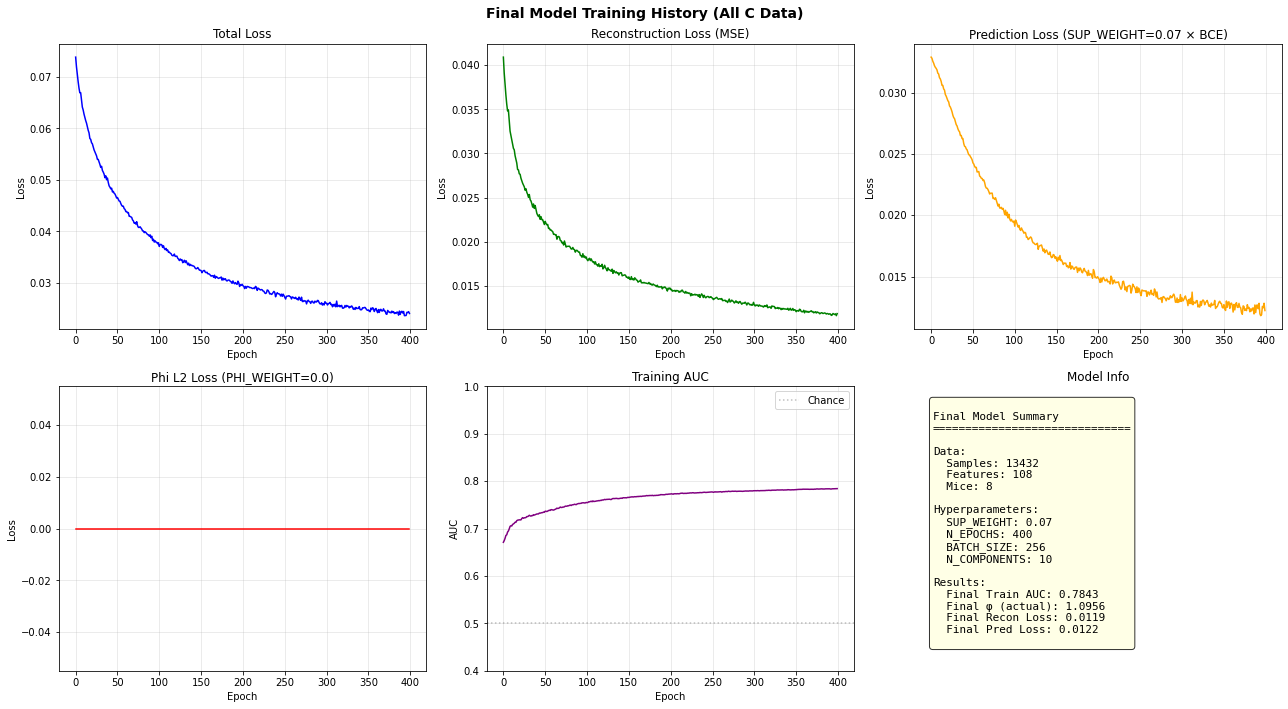


TRAINING COMPLETE

Final Model Parameters:
  φ (actual, after Softplus): 1.0956
  φ (raw parameter): 0.6886
  β (intercept): -2.6303

Final Training Metrics:
  Total Loss: 0.0241
  Recon Loss: 0.0119
  Pred Loss:  0.0122
  Train AUC:  0.7843

Model saved to:
  Full model: Maternal_model_lick_Onnest_C_only_Dec19_v1.pt
  State dict: Maternal_sd_lick_Onnest_C_only_Dec19_v1.pt



In [31]:
# ================================================================
# Final Model Training on All Data
# ================================================================
#  LOO-CV  (sup_weight=0.07, n_epochs=400)
# has C groupdata
# ================================================================

# ：data：
# X_Licking_C, y_Licking_C, mouse_ids_Licking_C, y_sampling_Licking_C

# Save file for the model and state_dictionary
MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"
MODEL_STATE_DICT = "Maternal_sd_lick_Onnest_C_only_Dec19_v1.pt"

# ================================================================
# Hyperparameters (determined from LOO-CV with validation)
# ================================================================

N_COMPONENTS = 10
DIM_IN = X_Licking_C.shape[1]
NETWORK_CONSTRAINT = "Positive"
DEVICE = "auto"
N_INTERCEPTS = 1
OPTIMIZER = "SGD"
MOMENTUM = 0.9
N_SUP_NETWORKS = 1
RECON_LOSS = "MSE"
SUP_RECON_WEIGHT = 0.0
PHI_WEIGHT = 0.0
SUP_WEIGHT = 0.07              # ← LOO-CV 
DEEP_ENC = True
H = 64
SUP_RECON = "Residual"
SUP_SMOOTHNESS_WEIGHT = 1
FEATURE_GROUPS = None
GROUP_WEIGHTS = None

N_EPOCHS = 400                  # ← LOO-CV 
N_PRE_EPOCHS = 100
BATCH_SIZE = 256
LR = 1e-3

# ================================================================
# Set Random Seed and Create Model
# ================================================================

seed = 2025
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

print("=" * 80)
print("FINAL MODEL TRAINING ON ALL DATA")
print("=" * 80)
print(f"\nHyperparameters (from LOO-CV):")
print(f"  SUP_WEIGHT: {SUP_WEIGHT}")
print(f"  N_EPOCHS: {N_EPOCHS}")
print(f"\nData:")
print(f"  X shape: {X_Licking_C.shape}")
print(f"  y shape: {y_Licking_C.shape}")
print(f"  licking=1: {np.sum(y_Licking_C == 1)}, licking=0: {np.sum(y_Licking_C == 0)}")

# Create model using dCSFA_NMF v1.3
model = dCSFA_NMF(
    n_components=N_COMPONENTS,
    dim_in=DIM_IN,
    n_sup_networks=N_SUP_NETWORKS,
    optim_name=OPTIMIZER,
    recon_loss=RECON_LOSS,
    sup_recon_weight=SUP_RECON_WEIGHT,
    sup_weight=SUP_WEIGHT,
    phi_weight=PHI_WEIGHT,
    n_intercepts=N_INTERCEPTS,
    useDeepEnc=DEEP_ENC,
    h=H,
    sup_recon_type=SUP_RECON,
    feature_groups=FEATURE_GROUPS,
    group_weights=GROUP_WEIGHTS,
    fixed_corr=NETWORK_CONSTRAINT,
    momentum=MOMENTUM,
    sup_smoothness_weight=SUP_SMOOTHNESS_WEIGHT
)

print(f"\nModel version: {model.__version__}")

# ================================================================
# Train Model
# ================================================================

print("\nTraining model...")

model.fit(
    X_Licking_C,
    y_Licking_C,
    y_sample_groups=y_sampling_Licking_C.squeeze(),
    y_pred_weights=None,
    intercept_mask=None,
    task_mask=None,
    n_epochs=N_EPOCHS,
    n_pre_epochs=N_PRE_EPOCHS,
    nmf_max_iter=500,
    batch_size=BATCH_SIZE,
    lr=LR,
    pretrain=True,
    verbose=True,
    X_val=None,           #  validation（ LOO-CV ）
    y_val=None,
    y_pred_weights_val=None,
    task_mask_val=None,
    best_model_name=MODEL_STATE_DICT
)

# Save the model
torch.save(model, MODEL_SAVE_FILE)
print(f"\nModel saved to: {MODEL_SAVE_FILE}")

# ================================================================
# Plot Training History
# ================================================================

print("\nPlotting training history...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Total Loss
axes[0, 0].plot(model.train_total_hist, color='blue', linewidth=1.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].grid(alpha=0.3)

# 2. Reconstruction Loss
axes[0, 1].plot(model.train_recon_hist, color='green', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Reconstruction Loss (MSE)')
axes[0, 1].grid(alpha=0.3)

# 3. Prediction Loss
axes[0, 2].plot(model.train_pred_hist, color='orange', linewidth=1.5)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].set_title(f'Prediction Loss (SUP_WEIGHT={SUP_WEIGHT} × BCE)')
axes[0, 2].grid(alpha=0.3)

# 4. Phi L2 Loss
axes[1, 0].plot(model.train_phi_loss_hist, color='red', linewidth=1.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title(f'Phi L2 Loss (PHI_WEIGHT={PHI_WEIGHT})')
axes[1, 0].grid(alpha=0.3)

# 5. Training AUC
train_aucs = [auc[0] for auc in model.train_auc_hist]
axes[1, 1].plot(train_aucs, color='purple', linewidth=1.5)
axes[1, 1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].set_title('Training AUC')
axes[1, 1].set_ylim([0.4, 1.0])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Model Info
info_text = f"""
Final Model Summary
{'='*30}

Data:
  Samples: {X_Licking_C.shape[0]}
  Features: {X_Licking_C.shape[1]}
  Mice: {len(np.unique(mouse_ids_Licking_C))}

Hyperparameters:
  SUP_WEIGHT: {SUP_WEIGHT}
  N_EPOCHS: {N_EPOCHS}
  BATCH_SIZE: {BATCH_SIZE}
  N_COMPONENTS: {N_COMPONENTS}

Results:
  Final Train AUC: {train_aucs[-1]:.4f}
  Final φ (actual): {model.get_phi(0).item():.4f}
  Final Recon Loss: {model.train_recon_hist[-1]:.4f}
  Final Pred Loss: {model.train_pred_hist[-1]:.4f}
"""

axes[1, 2].text(0.05, 0.95, info_text, transform=axes[1, 2].transAxes,
               fontsize=11, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].set_title('Model Info')
axes[1, 2].axis('off')

plt.suptitle('Final Model Training History (All C Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_model_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# Print Final Summary
# ================================================================

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(f"\nFinal Model Parameters:")
print(f"  φ (actual, after Softplus): {model.get_phi(0).item():.4f}")
print(f"  φ (raw parameter): {model.phi_list[0].item():.4f}")
print(f"  β (intercept): {model.beta_list[0].item():.4f}")

print(f"\nFinal Training Metrics:")
print(f"  Total Loss: {model.train_total_hist[-1]:.4f}")
print(f"  Recon Loss: {model.train_recon_hist[-1]:.4f}")
print(f"  Pred Loss:  {model.train_pred_hist[-1]:.4f}")
print(f"  Train AUC:  {train_aucs[-1]:.4f}")

print(f"\nModel saved to:")
print(f"  Full model: {MODEL_SAVE_FILE}")
print(f"  State dict: {MODEL_STATE_DICT}")

print("\n" + "=" * 80)

In [32]:
df, df_select = process_W_nmf_k(model.get_W_nmf(), train_dict = full_dict, threshold_ratio=0.8, k=0)

Selected DataFrame (df_selected):
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA     1.581      NaN     1.255
BLA-IL      1.917      NaN     1.136
BLA-MeA     1.705      NaN       NaN
BLA-NAc     1.729      NaN     1.094
BLA-PrL     1.998      NaN       NaN
BLA-VHipp     NaN      NaN       NaN
BLA-VTA     1.675      NaN       NaN
CeA-IL      1.887      NaN     1.165
CeA-MeA     1.790      NaN       NaN
CeA-NAc     1.763      NaN     1.121
CeA-PrL     2.011      NaN     1.127
CeA-VHipp     NaN      NaN       NaN
CeA-VTA     1.698      NaN       NaN
IL-MeA      1.930      NaN       NaN
IL-NAc      1.776    1.094     1.229
IL-PrL      1.708    1.455     1.486
IL-VHipp      NaN      NaN       NaN
IL-V

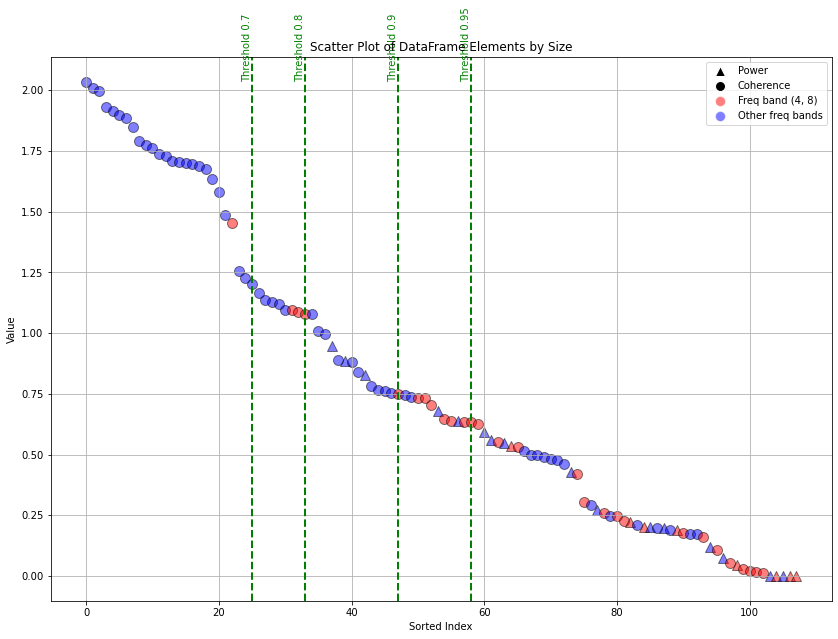

In [33]:
flattened_values = df.values.flatten()
sorted_indices = np.argsort(flattened_values)[::-1]  
sorted_values = flattened_values[sorted_indices]

original_positions = np.unravel_index(sorted_indices, df.shape)

shapes = np.array(['^' if i < 8 else 'o' for i in original_positions[0]])  
colors = np.array(['r' if j == 1 else 'b' for j in original_positions[1]])  

squared_values = df.values ** 2
flattened_squared_values = squared_values.flatten()
total_l2_square = np.sum(flattened_squared_values)
sorted_squared_values = flattened_squared_values[sorted_indices]
cumulative_sum = np.cumsum(sorted_squared_values)

thresholds = [0.7, 0.8, 0.9, 0.95]
threshold_indices = [np.argmax(cumulative_sum >= t * total_l2_square) for t in thresholds]

plt.figure(figsize=(14, 10))
for i in range(len(sorted_values)):
    plt.scatter(i, sorted_values[i], alpha=0.5, color=colors[i], marker=shapes[i], edgecolors='black', s=100)

for idx, threshold in zip(threshold_indices, thresholds):
    plt.axvline(x=idx, color='green', linestyle='--', linewidth=2)
    plt.text(idx, max(sorted_values), f'Threshold {threshold}', rotation=90, verticalalignment='bottom', horizontalalignment='right', color='green')

legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='Power', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Coherence', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Freq band (4, 8)', markerfacecolor='r', markersize=10, alpha=0.5),
    Line2D([0], [0], marker='o', color='w', label='Other freq bands', markerfacecolor='b', markersize=10, alpha=0.5)
]

plt.legend(handles=legend_elements, loc='upper right')
plt.title('Scatter Plot of DataFrame Elements by Size')
plt.xlabel('Sorted Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

### Circos Plot

In [54]:
TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combine/full_spec_features_8roi.pkl"

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)
    
rows_power = train_dict["region"][:8]
print(rows_power)

import scipy.io
import numpy as np

# numpygroup
area_names = np.array(rows_power, dtype=object).reshape(-1, 1)

# dataas dict
data = {'AreaNames': area_names}

# Save as AreaNames.mat filetotarget path
scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/AreaNames.mat', data)






MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"
model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'






# Assuming model.get_W_nmf() returns a tensor of shape [10, 180]
W_nmf_data = model.get_W_nmf()  # Replace with model.get_W_nmf() in actual usage

# 1. datafrom
W_nmf_complex = W_nmf_data + 1j * 0

# 2. torch tensor  numpy array
W_nmf_np = W_nmf_complex.detach().numpy()

# 3. shape：，180 element36*5
W_nmf_reshaped = W_nmf_np.reshape(10, 36, 3)

# 4. copy/expand data  (0, 3)  (4, 8)  (9, 12)  (13, 30)  (31, 56)   ---  (2, 7)  (8, 12)  (14, 23)
expanded_data = np.zeros((10, 36, 25), dtype=complex)
expanded_data[:, :, 2:8] = W_nmf_reshaped[:, :, 0:1]
expanded_data[:, :, 8:13] = W_nmf_reshaped[:, :, 1:2]
expanded_data[:, :, 14:24] = W_nmf_reshaped[:, :, 2:3]

# 5. 
transposed_data = np.transpose(expanded_data, (0, 2, 1))

# 6. expand and rewrite 3rd dim
final_data = np.zeros((10, 25, 8, 8), dtype=complex)
for i in range(10):
    for j in range(25):
        matrix_8x8 = np.zeros((8, 8), dtype=complex)
        matrix_8x8[np.diag_indices(8)] = transposed_data[i, j, 0:8]
        upper_triangle_indices = np.triu_indices(8, k=1)
        matrix_8x8[upper_triangle_indices] = transposed_data[i, j, 8:]
        matrix_8x8 = matrix_8x8 + matrix_8x8.T - np.diag(np.diag(matrix_8x8))
        final_data[i, j] = matrix_8x8

final_data.shape  # output should be (10, 57, 8, 8)

final_data_transposed = np.transpose(final_data, (2, 3, 1, 0))
print(final_data_transposed.shape)





# s  1x57 double，elementfrom 0 to 56  57  
s = np.arange(25, dtype=float)

# create data dict
data = {
    'UKU': final_data_transposed,
    'UKUnorm': final_data_transposed,
    's': s
}

# Save as NormalizedCrossSpectra.mat filetotarget path
scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/NormalizedCrossSpectra.mat', data)







def process_W_nmf_k(W_normalized, train_dict, threshold_ratio=0.9, k=0):
    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]
    total_rows = len(rows_power) + len(rows_coh)
    df = pd.DataFrame(W_normalized[k, :].detach().numpy().reshape(total_rows, len(columns)),
                      index=rows_power + rows_coh,
                      columns=columns)
    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    selected_positions = np.unravel_index(selected_indices, df.shape)
    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    # ================================================================
    # NEW: to element
    # ================================================================
    if len(selected_indices) > 0:
        #  element
        last_selected_idx = selected_indices[-1]
        last_selected_position = np.unravel_index(last_selected_idx, df.shape)
        last_selected_row = last_selected_position[0]
        last_selected_col = last_selected_position[1]
        
        #  value
        last_element_value = df.iat[last_selected_row, last_selected_col]
        last_element_squared = squared_values[last_selected_row, last_selected_col]
        last_element_row_name = df.index[last_selected_row]
        last_element_col_name = df.columns[last_selected_col]
        
        # cumulativecontribution
        cumulative_contribution = cumulative_sum[len(selected_indices) - 1]
        cumulative_percentage = (cumulative_contribution / total_l2_square) * 100
        
        #  elementcontribution
        last_element_contribution = last_element_squared / total_l2_square * 100
        
        last_element_info = {
            'value': last_element_value,
            'squared_value': last_element_squared,
            'row_name': last_element_row_name,
            'col_name': last_element_col_name,
            'row_index': last_selected_row,
            'col_index': last_selected_col,
            'contribution_percent': last_element_contribution,
            'cumulative_percent': cumulative_percentage,
            'n_selected': len(selected_indices)
        }
        
        # 
        print("\n" + "="*70)
        print(f"LAST SELECTED ELEMENT INFO (threshold={threshold_ratio*100}%)")
        print("="*70)
        print(f"Position:              [{last_element_row_name}] × [{last_element_col_name}]")
        print(f"Value:                 {last_element_value:.6f}")
        print(f"Squared Value:         {last_element_squared:.6f}")
        print(f"Individual Contrib:    {last_element_contribution:.2f}%")
        print(f"Cumulative Contrib:    {cumulative_percentage:.2f}%")
        print(f"Total Selected:        {len(selected_indices)} elements")
        print("="*70)
    else:
        last_element_info = None
        print("\n" + "="*70)
        print("WARNING: No elements selected (first element already exceeds threshold)")
        print("="*70)
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("\nSelected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected, last_element_info

['BLA', 'CeA', 'IL', 'MeA', 'NAc', 'PrL', 'VHipp', 'VTA']
(8, 8, 25, 10)


# New Circos plot

In [2]:
import pickle
import scipy.io
import numpy as np
import pandas as pd
import torch

# ============================================
# 1. datagenerate AreaNames.mat
# ============================================

TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combined/full_onnest_spec_features_8roi_Trim.pkl"

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)
    
rows_power = train_dict["region"][:8]
print(rows_power)

# numpygroup
area_names = np.array(rows_power, dtype=object).reshape(-1, 1)

# dataas dict
data = {'AreaNames': area_names}

# Save as AreaNames.mat filetotarget path
scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/AreaNames_maternal.mat', data)

# ============================================
# 2. 
# ============================================


MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"
model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'


# ============================================
# 3. generate NormalizedCrossSpectra.mat
# ============================================

# Assuming model.get_W_nmf() returns a tensor of shape [10, 180]
W_nmf_data = model.get_W_nmf()  # Replace with model.get_W_nmf() in actual usage

# 1. datafrom
W_nmf_complex = W_nmf_data + 1j * 0

# 2. torch tensor  numpy array
W_nmf_np = W_nmf_complex.detach().numpy()

# 3. shape：，180 element36*3
W_nmf_reshaped = W_nmf_np.reshape(10, 36, 3)

# 4. copy/expand data - modify
# freq_band[0]: [2, 7] Hz   → bins 2,3,4,5,6   (exclude7)
# freq_band[1]: [8, 12] Hz  → bins 8,9,10,11   (exclude12)
# freq_band[2]: [14, 23] Hz → bins 14,15,...,22 (exclude23)

expanded_data = np.zeros((10, 36, 25), dtype=complex)

# after modification
expanded_data[:, :, 2:7] = W_nmf_reshaped[:, :, 0:1]    # [2,7) Hz → bins 2,3,4,5,6
expanded_data[:, :, 8:12] = W_nmf_reshaped[:, :, 1:2]   # [8,12) Hz → bins 8,9,10,11
expanded_data[:, :, 14:23] = W_nmf_reshaped[:, :, 2:3]  # [14,23) Hz → bins 14,...,22

# 5. 
transposed_data = np.transpose(expanded_data, (0, 2, 1))

# 6. expand and rewrite 3rd dim
final_data = np.zeros((10, 25, 8, 8), dtype=complex)
for i in range(10):
    for j in range(25):
        matrix_8x8 = np.zeros((8, 8), dtype=complex)
        matrix_8x8[np.diag_indices(8)] = transposed_data[i, j, 0:8]
        upper_triangle_indices = np.triu_indices(8, k=1)
        matrix_8x8[upper_triangle_indices] = transposed_data[i, j, 8:]
        matrix_8x8 = matrix_8x8 + matrix_8x8.T - np.diag(np.diag(matrix_8x8))
        final_data[i, j] = matrix_8x8

final_data.shape  # output should be (10, 25, 8, 8)

final_data_transposed = np.transpose(final_data, (2, 3, 1, 0))
print(final_data_transposed.shape)

# s  1x25 double，elementfrom 0 to 24  25  
s = np.arange(25, dtype=float)

# create data dict
data = {
    'UKU': final_data_transposed,
    'UKUnorm': final_data_transposed,
    's': s
}

# Save as NormalizedCrossSpectra.mat filetotarget path
scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/NormalizedCrossSpectra_licking.mat', data)

# ============================================
# 4. verifyfrequencymapping
# ============================================

print("\n" + "="*70)
print("Frequency-mapping verification")
print("="*70)

print("\nModified frequency-bin mapping:")
print("  freq_band[0] [2, 7] Hz   → bins 2,3,4,5,6     (5 bins)")
print("  freq_band[1] [8, 12] Hz  → bins 8,9,10,11     (4 bins)")
print("  freq_band[2] [14, 23] Hz → bins 14,15,...,22  (9 bins)")

print("\nBlank bins:")
print("  bins 0,1:      0-2 Hz (empty)")
print("  bin 7:         7 Hz (empty) ← boundary")
print("  bins 12,13:    12-13 Hz (empty) ← boundary + gap")
print("  bins 23,24:    23-24 Hz (empty) ← boundary")

print("\nsarray mapping:")
for i in range(25):
    if 2 <= i <= 6:
        status = f"freq_band[0] ({i} Hz in [2,7))"
    elif 8 <= i <= 11:
        status = f"freq_band[1] ({i} Hz in [8,12))"
    elif 14 <= i <= 22:
        status = f"freq_band[2] ({i} Hz in [14,23))"
    else:
        status = f"{i} Hz (empty)"
    print(f"  s[{i:2d}] = {i:2d}  →  {status}")

# ============================================
# 5. process_W_nmf_k （）
# ============================================

def process_W_nmf_k(W_normalized, train_dict, threshold_ratio=0.9, k=0):
    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]
    total_rows = len(rows_power) + len(rows_coh)
    df = pd.DataFrame(W_normalized[k, :].detach().numpy().reshape(total_rows, len(columns)),
                      index=rows_power + rows_coh,
                      columns=columns)
    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    selected_positions = np.unravel_index(selected_indices, df.shape)
    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    # ================================================================
    # NEW: to element
    # ================================================================
    if len(selected_indices) > 0:
        #  element
        last_selected_idx = selected_indices[-1]
        last_selected_position = np.unravel_index(last_selected_idx, df.shape)
        last_selected_row = last_selected_position[0]
        last_selected_col = last_selected_position[1]
        
        #  value
        last_element_value = df.iat[last_selected_row, last_selected_col]
        last_element_squared = squared_values[last_selected_row, last_selected_col]
        last_element_row_name = df.index[last_selected_row]
        last_element_col_name = df.columns[last_selected_col]
        
        # cumulativecontribution
        cumulative_contribution = cumulative_sum[len(selected_indices) - 1]
        cumulative_percentage = (cumulative_contribution / total_l2_square) * 100
        
        #  elementcontribution
        last_element_contribution = last_element_squared / total_l2_square * 100
        
        last_element_info = {
            'value': last_element_value,
            'squared_value': last_element_squared,
            'row_name': last_element_row_name,
            'col_name': last_element_col_name,
            'row_index': last_selected_row,
            'col_index': last_selected_col,
            'contribution_percent': last_element_contribution,
            'cumulative_percent': cumulative_percentage,
            'n_selected': len(selected_indices)
        }
        
        # 
        print("\n" + "="*70)
        print(f"LAST SELECTED ELEMENT INFO (threshold={threshold_ratio*100}%)")
        print("="*70)
        print(f"Position:              [{last_element_row_name}] × [{last_element_col_name}]")
        print(f"Value:                 {last_element_value:.6f}")
        print(f"Squared Value:         {last_element_squared:.6f}")
        print(f"Individual Contrib:    {last_element_contribution:.2f}%")
        print(f"Cumulative Contrib:    {cumulative_percentage:.2f}%")
        print(f"Total Selected:        {len(selected_indices)} elements")
        print("="*70)
    else:
        last_element_info = None
        print("\n" + "="*70)
        print("WARNING: No elements selected (first element already exceeds threshold)")
        print("="*70)
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("\nSelected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected, last_element_info

['BLA', 'CeA', 'IL', 'MeA', 'NAc', 'PrL', 'VHipp', 'VTA']
(8, 8, 25, 10)

频率映射验证

修改后的频率bin映射:
  freq_band[0] [2, 7] Hz   → bins 2,3,4,5,6     (5个bins)
  freq_band[1] [8, 12] Hz  → bins 8,9,10,11     (4个bins)
  freq_band[2] [14, 23] Hz → bins 14,15,...,22  (9个bins)

空白bins:
  bins 0,1:      0-2 Hz (空)
  bin 7:         7 Hz (空) ← 边界
  bins 12,13:    12-13 Hz (空) ← 边界+间隙
  bins 23,24:    23-24 Hz (空) ← 边界

s数组对应:
  s[ 0] =  0  →  0 Hz (空)
  s[ 1] =  1  →  1 Hz (空)
  s[ 2] =  2  →  freq_band[0] (2 Hz in [2,7))
  s[ 3] =  3  →  freq_band[0] (3 Hz in [2,7))
  s[ 4] =  4  →  freq_band[0] (4 Hz in [2,7))
  s[ 5] =  5  →  freq_band[0] (5 Hz in [2,7))
  s[ 6] =  6  →  freq_band[0] (6 Hz in [2,7))
  s[ 7] =  7  →  7 Hz (空)
  s[ 8] =  8  →  freq_band[1] (8 Hz in [8,12))
  s[ 9] =  9  →  freq_band[1] (9 Hz in [8,12))
  s[10] = 10  →  freq_band[1] (10 Hz in [8,12))
  s[11] = 11  →  freq_band[1] (11 Hz in [8,12))
  s[12] = 12  →  12 Hz (空)
  s[13] = 13  →  13 Hz (空)
  s[14] = 14  →  freq_band[2] (14

In [2]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.8, k=0)


LAST SELECTED ELEMENT INFO (threshold=80.0%)
Position:              [NAc-PrL] × [(8, 12)]
Value:                 1.087257
Squared Value:         1.182129
Individual Contrib:    1.09%
Cumulative Contrib:    79.35%
Total Selected:        33 elements

Selected DataFrame (df_selected):
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA     1.581      NaN     1.255
BLA-IL      1.917      NaN     1.136
BLA-MeA     1.705      NaN       NaN
BLA-NAc     1.729      NaN     1.094
BLA-PrL     1.998      NaN       NaN
BLA-VHipp     NaN      NaN       NaN
BLA-VTA     1.675      NaN       NaN
CeA-IL      1.887      NaN     1.165
CeA-MeA     1.790      NaN       NaN
CeA-NAc     1.763      NaN     1.121
CeA-PrL     2

In [3]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.7, k=0)


LAST SELECTED ELEMENT INFO (threshold=70.0%)
Position:              [IL-NAc] × [(14, 23)]
Value:                 1.229083
Squared Value:         1.510644
Individual Contrib:    1.40%
Cumulative Contrib:    69.90%
Total Selected:        25 elements

Selected DataFrame (df_selected):
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA     1.581      NaN     1.255
BLA-IL      1.917      NaN       NaN
BLA-MeA     1.705      NaN       NaN
BLA-NAc     1.729      NaN       NaN
BLA-PrL     1.998      NaN       NaN
BLA-VHipp     NaN      NaN       NaN
BLA-VTA     1.675      NaN       NaN
CeA-IL      1.887      NaN       NaN
CeA-MeA     1.790      NaN       NaN
CeA-NAc     1.763      NaN       NaN
CeA-PrL     2

In [3]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.6, k=0)


LAST SELECTED ELEMENT INFO (threshold=60.0%)
Position:              [BLA-VTA] × [(2, 7)]
Value:                 1.674795
Squared Value:         2.804938
Individual Contrib:    2.60%
Cumulative Contrib:    58.26%
Total Selected:        19 elements

Selected DataFrame (df_selected):
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA       NaN      NaN       NaN
BLA-IL      1.917      NaN       NaN
BLA-MeA     1.705      NaN       NaN
BLA-NAc     1.729      NaN       NaN
BLA-PrL     1.998      NaN       NaN
BLA-VHipp     NaN      NaN       NaN
BLA-VTA     1.675      NaN       NaN
CeA-IL      1.887      NaN       NaN
CeA-MeA     1.790      NaN       NaN
CeA-NAc     1.763      NaN       NaN
CeA-PrL     2.

In [4]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.5, k=0)


LAST SELECTED ELEMENT INFO (threshold=50.0%)
Position:              [BLA-MeA] × [(2, 7)]
Value:                 1.704647
Squared Value:         2.905820
Individual Contrib:    2.69%
Cumulative Contrib:    47.66%
Total Selected:        15 elements

Selected DataFrame (df_selected):
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA       NaN      NaN       NaN
BLA-IL      1.917      NaN       NaN
BLA-MeA     1.705      NaN       NaN
BLA-NAc     1.729      NaN       NaN
BLA-PrL     1.998      NaN       NaN
BLA-VHipp     NaN      NaN       NaN
BLA-VTA       NaN      NaN       NaN
CeA-IL      1.887      NaN       NaN
CeA-MeA     1.790      NaN       NaN
CeA-NAc     1.763      NaN       NaN
CeA-PrL     2.

# Feature Selection

In [3]:
MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"
model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'

W_nmf_data = model.get_W_nmf() # this is the function from the model script, softplus + factor normalization

TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combine/full_spec_features_8roi.pkl"

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

In [4]:
def process_W_nmf_all(W_nmf_data, train_dict, abs_cum_ratio=0.9, rel_val=0.5):
    """
    Dual filtering of the first factor based on absolute strength and relative uniqueness
    
    Parameters:
    -----------
    W_nmf_data : torch.Tensor
        Weight matrix after Softplus and row normalization, shape: (n_factors, n_features)
    train_dict : dict
        Dictionary containing "region", "region_pair", "freq_band"
    abs_cum_ratio : float
        Cumulative ratio threshold for absolute strength (default 0.9)
    rel_val : float
        Threshold for relative uniqueness (default 0.5, i.e., >50%)
    
    Returns:
    --------
    abs_df_cut : pd.DataFrame
        Result after cumulative L2 energy cutoff
    rel_df_cut : pd.DataFrame
        Result after relative uniqueness threshold cutoff
    both_df_cut : pd.DataFrame
        Features satisfying both conditions
    abs_df : pd.DataFrame
        Absolute strength distribution of first factor (uncut)
    rel_df : pd.DataFrame
        Relative contribution of first factor (uncut)
    """
    import numpy as np
    import pandas as pd
    import torch
    
    # ============================================================
    # Step 1: Check if L2 norms of all rows are equal
    # ============================================================
    W_numpy = W_nmf_data.detach().numpy()
    row_l2_norms = np.linalg.norm(W_numpy, axis=1)
    
    print("="*60)
    print("Step 1: Check Row L2 Norms")
    print("="*60)
    for i, norm in enumerate(row_l2_norms):
        print(f"Factor {i}: {norm:.10f}")
    
    # Check if all norms are equal (allow relative error of 1e-5)
    if not np.allclose(row_l2_norms, row_l2_norms[0], rtol=1e-5):
        raise ValueError(
            f"Error: Row L2 norms are not equal!\n"
            f"Min: {row_l2_norms.min():.10f}\n"
            f"Max: {row_l2_norms.max():.10f}\n"
            f"Difference: {row_l2_norms.max() - row_l2_norms.min():.10f}"
        )
    print(f"✓ All row L2 norms are equal: {row_l2_norms[0]:.6f}\n")
    
    # ============================================================
    # Build DataFrame structure
    # ============================================================
    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]
    total_rows = len(rows_power) + len(rows_coh)
    all_rows = rows_power + rows_coh
    
    # Extract first factor (k=0)
    W_factor0 = W_numpy[0, :]
    
    # Set display format
    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    
    # ============================================================
    # Step 2: Absolute Strength Analysis
    # ============================================================
    print("="*60)
    print("Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)")
    print("="*60)
    
    # Create full absolute strength DataFrame
    abs_df = pd.DataFrame(
        W_factor0.reshape(total_rows, len(columns)),
        index=all_rows,
        columns=columns
    )
    
    # Calculate squared values (energy)
    squared_values = abs_df.values ** 2
    flattened_squared = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared)
    
    # Sort by energy
    sorted_indices = np.argsort(flattened_squared)[::-1]
    sorted_squared = flattened_squared[sorted_indices]
    
    # Cumulative sum
    cumulative_sum = np.cumsum(sorted_squared)
    threshold = abs_cum_ratio * total_l2_square
    
    # Select features where cumulative sum <= threshold
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    
    # Create cutoff DataFrame
    selected_positions = np.unravel_index(selected_indices, abs_df.shape)
    abs_df_cut = pd.DataFrame(np.nan, index=abs_df.index, columns=abs_df.columns)
    
    for row, col in zip(selected_positions[0], selected_positions[1]):
        abs_df_cut.iat[row, col] = abs_df.iat[row, col]
    
    n_abs_selected = (~abs_df_cut.isna()).sum().sum()
    print(f"Cumulative ratio threshold: {abs_cum_ratio}")
    print(f"Selected features: {n_abs_selected}/{abs_df.size}")
    
    # Print cutoff version first, then full version
    print("\n--- Absolute Strength (After Cutoff) ---")
    print(abs_df_cut)
    print("\n--- Absolute Strength (Full) ---")
    print(abs_df)
    print()
    
    # ============================================================
    # Step 3: Relative Uniqueness Analysis
    # ============================================================
    print("="*60)
    print("Step 3: Relative Uniqueness Analysis (Proportion Across All Factors)")
    print("="*60)
    
    # Calculate contribution ratio for each column
    column_sums = W_numpy.sum(axis=0, keepdims=True)
    column_sums[column_sums == 0] = 1
    W_contribution = W_numpy / column_sums
    
    # Extract first factor's contribution ratio
    contribution_factor0 = W_contribution[0, :]
    
    # Create full relative contribution DataFrame
    rel_df = pd.DataFrame(
        contribution_factor0.reshape(total_rows, len(columns)),
        index=all_rows,
        columns=columns
    )
    
    # Cutoff based on threshold
    rel_df_cut = rel_df.copy()
    rel_df_cut[rel_df_cut <= rel_val] = np.nan
    
    n_rel_selected = (~rel_df_cut.isna()).sum().sum()
    print(f"Relative uniqueness threshold: {rel_val}")
    print(f"Selected features: {n_rel_selected}/{rel_df.size}")
    
    # Print cutoff version first, then full version
    print("\n--- Relative Uniqueness (After Cutoff) ---")
    print(rel_df_cut)
    print("\n--- Relative Uniqueness (Full) ---")
    print(rel_df)
    print()
    
    # ============================================================
    # Step 4: Intersection
    # ============================================================
    print("="*60)
    print("Step 4: Feature Intersection Analysis")
    print("="*60)
    
    # Find features satisfying both conditions
    both_mask = (~abs_df_cut.isna()) & (~rel_df_cut.isna())
    both_df_cut = abs_df.copy()
    both_df_cut[~both_mask] = np.nan
    
    n_both_selected = (~both_df_cut.isna()).sum().sum()
    print(f"Features satisfying both conditions: {n_both_selected}")
    
    # Check if intersection is a subset of relative uniqueness
    rel_mask = ~rel_df_cut.isna()
    is_subset = not (both_mask.values & ~rel_mask.values).any()
    
    if is_subset:
        print("✓ Intersection is a subset of relative uniqueness filtering result")
    else:
        print("✗ Intersection is NOT a subset of relative uniqueness filtering result")
        # Find different elements
        diff_mask = both_mask & ~rel_mask
        diff_positions = np.where(diff_mask.values)
        print("\nDifferent elements:")
        for row, col in zip(diff_positions[0], diff_positions[1]):
            print(f"  Position [{all_rows[row]}, {columns[col]}]: "
                  f"abs={abs_df.iat[row, col]:.4f}, rel={rel_df.iat[row, col]:.4f}")
    
    # Print intersection DataFrame
    print("\n--- Intersection (Both Conditions) ---")
    print(both_df_cut)
    
    # ============================================================
    # Summary
    # ============================================================
    print("\n" + "="*60)
    print("Summary")
    print("="*60)
    print(f"Absolute strength filtering: {n_abs_selected} features")
    print(f"Relative uniqueness filtering: {n_rel_selected} features")
    print(f"Intersection: {n_both_selected} features")
    print("="*60 + "\n")
    
    # Return: cutoff versions first, then full versions last
    return abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib import patches
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

def create_bar_heatmap_selective(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut):
    """
    Only show cells passing abs filter：
    - bar = abs_df（absolute intensity）
    - bar = rel_df（relative uniqueness）- blue gradient
    - Iowa Gold border = both_df_cut（best features）
    """
    fig, ax = plt.subplots(figsize=(10, 16))
    
    iowa_gold = '#FFCD00'
    
    # dotblue gradient
    colors = ['#FFFFFF', '#DBEAFE', '#60A5FA', '#1E40AF', '#0A1628']
    cmap = LinearSegmentedColormap.from_list('extreme_blues', colors, N=256)
    
    # ===== data =====
    abs_max = np.nanmax(abs_df.values)
    abs_norm = abs_df / abs_max
    
    rel_min = np.nanmin(rel_df.values)
    rel_max = np.nanmax(rel_df.values)
    rel_norm = (rel_df - rel_min) / (rel_max - rel_min)
    
    print(f"absolute intensityrange: 0 - {abs_max:.6f}")
    print(f"relative uniquenessrange: {rel_min:.4f} - {rel_max:.4f}")

    # ===== （）=====
    for i in range(len(abs_df)):
        for j in range(len(abs_df.columns)):
            bg = Rectangle((j - 0.5, i - 0.5), 1, 1,
                          facecolor='white',
                          edgecolor='lightgray',
                          linewidth=0.5,
                          zorder=1)
            ax.add_patch(bg)

    # ===== bar =====
    for i in range(len(abs_df)):
        for j in range(len(abs_df.columns)):
            passed_abs = not pd.isna(abs_df_cut.iloc[i, j])
            
            if passed_abs:  # hasabsbar
                abs_val = abs_df.iloc[i, j]
                rel_val = rel_df.iloc[i, j]
                abs_normalized = abs_norm.iloc[i, j]
                rel_normalized = rel_norm.iloc[i, j]
                
                is_optimal = not pd.isna(both_df_cut.iloc[i, j])
                
                bar_width = abs_normalized * 0.9
                bar_height = 0.6
                bar_x = j - 0.45
                bar_y = i - bar_height/2
                
                bar_color = cmap(rel_normalized)
                
                bar = Rectangle((bar_x, bar_y), bar_width, bar_height,
                              facecolor=bar_color,
                              edgecolor='none',
                              zorder=5)
                ax.add_patch(bar)
                
                if is_optimal:
                    rect = Rectangle((j - 0.48, i - 0.48), 0.96, 0.96,
                                   linewidth=4, 
                                   edgecolor=iowa_gold,
                                   facecolor='none',
                                   zorder=10)
                    ax.add_patch(rect)
    
    # =====  =====
    ax.set_xticks(np.arange(len(abs_df.columns)))
    ax.set_yticks(np.arange(len(abs_df)))
    ax.set_xticklabels(abs_df.columns, fontsize=12, fontweight='bold')
    ax.set_yticklabels(abs_df.index, fontsize=10)
    
    ax.set_xticks(np.arange(len(abs_df.columns)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(abs_df)) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.8, alpha=0.4)
    ax.tick_params(which='minor', size=0)
    
    # =====  =====
    ax.axhline(y=7.5, color='black', linewidth=2.5, linestyle='-', alpha=0.7, zorder=20)
    
    ax.text(-1, 3.5, 'Power',
           rotation=90, va='center', ha='center',
           fontsize=14, color='black', fontweight='bold')
    ax.text(-1, 18, 'Coherence',
           rotation=90, va='center', ha='center',
           fontsize=14, color='black', fontweight='bold')
    
    # ===== Colorbar =====
    norm_rel = Normalize(vmin=rel_min, vmax=rel_max)
    sm_rel = ScalarMappable(cmap=cmap, norm=norm_rel)
    sm_rel.set_array([])
    
    cbar_rel = fig.colorbar(sm_rel, ax=ax, 
                            fraction=0.03, pad=0.02,
                            location='right')
    cbar_rel.set_label('Relative Uniqueness\n(Bar Color)',
                      fontsize=11, fontweight='bold', 
                      rotation=270, labelpad=25)
    
    # =====  =====
    n_abs = (~abs_df_cut.isna()).sum().sum()
    n_optimal = (~both_df_cut.isna()).sum().sum()
    
    legend_elements = [
        patches.FancyBboxPatch((0, 0), 0.9, 0.6,
                               boxstyle="round,pad=0.05",
                               facecolor=cmap(0.5), 
                               edgecolor='black', 
                               linewidth=1,
                               label=f'Selected features (n={n_abs})\nBar length = Absolute strength\nBar color = Relative uniqueness'),
        patches.Rectangle((0, 0), 1, 1, 
                         facecolor='white', 
                         edgecolor=iowa_gold,
                         linewidth=4,
                         label=f'Optimal features (Iowa Gold border)\nBoth criteria met (n={n_optimal})'),
        patches.Rectangle((0, 0), 1, 1, 
                         facecolor='white', 
                         edgecolor='lightgray', 
                         linewidth=1,
                         label=f'Not selected (blank)\n(n={abs_df.size - n_abs})')
    ]
    
    legend = ax.legend(handles=legend_elements, 
                      loc='center left',
                      bbox_to_anchor=(1.25, 0.35),
                      fontsize=9.5, 
                      framealpha=0.95,
                      edgecolor='black')
    
    ax.set_title('Selected Feature Visualization\n'
                'Bar Length = Absolute Strength  |  Bar Color = Relative Uniqueness', 
                fontsize=11, pad=20)
    
    ax.set_xlim(-0.5, len(abs_df.columns) - 0.5)
    ax.set_ylim(len(abs_df) - 0.5, -0.5)
    
    plt.subplots_adjust(left=0.12, right=0.82)
    
    return fig

Step 1: Check Row L2 Norms
Factor 0: 10.3923063278
Factor 1: 10.3923053741
Factor 2: 10.3923044205
Factor 3: 10.3923053741
Factor 4: 10.3923034668
Factor 5: 10.3923034668
Factor 6: 10.3923053741
Factor 7: 10.3923034668
Factor 8: 10.3923034668
Factor 9: 10.3923025131
✓ All row L2 norms are equal: 10.392306

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.8
Selected features: 33/108

--- Absolute Strength (After Cutoff) ---
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA    1.5807      NaN    1.2546
BLA-IL     1.9167      NaN    1.1359
BLA-MeA    1.7046      NaN       NaN
BLA-NAc    1.7285      NaN    1.0945
BLA-PrL    1.9978      NaN       NaN
BLA-VHipp

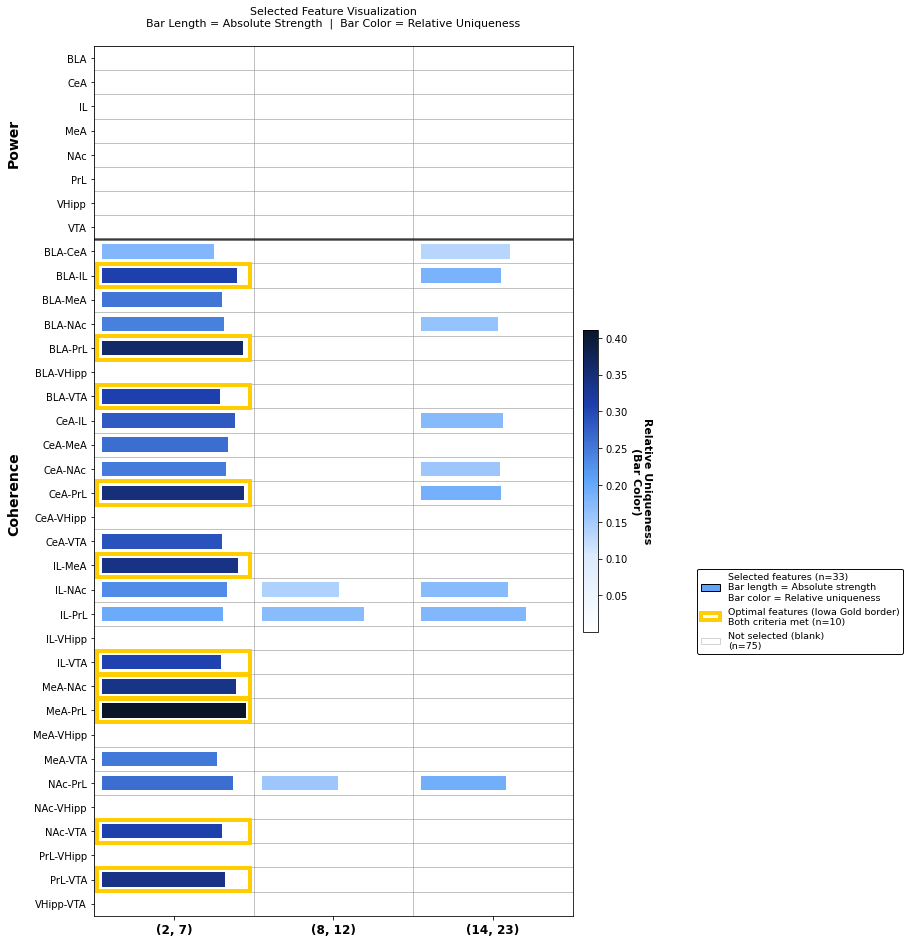

In [6]:
# ===== （outputtable）=====
# Step1：data（ - ，process_W_nmf_allverbose）
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.8, 
    rel_val=0.3
)

# Step2：
fig = create_bar_heatmap_selective(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

# Step3：save
plt.savefig('Selection_Licking_80.png', dpi=300, bbox_inches='tight')
plt.savefig('Selection_Licking_80.pdf', bbox_inches='tight')

plt.show()

Step 1: Check Row L2 Norms
Factor 0: 10.3923063278
Factor 1: 10.3923053741
Factor 2: 10.3923044205
Factor 3: 10.3923053741
Factor 4: 10.3923034668
Factor 5: 10.3923034668
Factor 6: 10.3923053741
Factor 7: 10.3923034668
Factor 8: 10.3923034668
Factor 9: 10.3923025131
✓ All row L2 norms are equal: 10.392306

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.7
Selected features: 25/108

--- Absolute Strength (After Cutoff) ---
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA    1.5807      NaN    1.2546
BLA-IL     1.9167      NaN       NaN
BLA-MeA    1.7046      NaN       NaN
BLA-NAc    1.7285      NaN       NaN
BLA-PrL    1.9978      NaN       NaN
BLA-VHipp

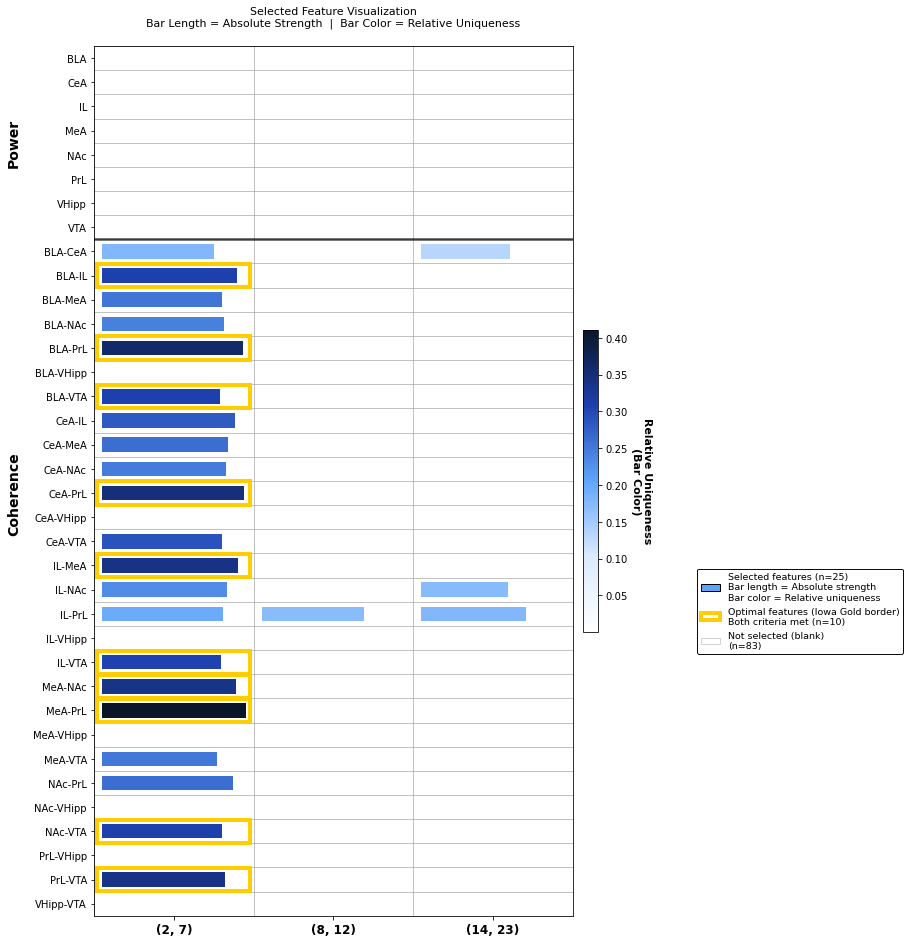

In [7]:
# ===== （outputtable）=====
# Step1：data（ - ，process_W_nmf_allverbose）
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.7, 
    rel_val=0.3
)

# Step2：
fig = create_bar_heatmap_selective(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

# Step3：save
plt.savefig('Selection_Licking_70.png', dpi=300, bbox_inches='tight')
plt.savefig('Selection_Licking_70.pdf', bbox_inches='tight')

plt.show()

Step 1: Check Row L2 Norms
Factor 0: 10.3923063278
Factor 1: 10.3923053741
Factor 2: 10.3923044205
Factor 3: 10.3923053741
Factor 4: 10.3923034668
Factor 5: 10.3923034668
Factor 6: 10.3923053741
Factor 7: 10.3923034668
Factor 8: 10.3923034668
Factor 9: 10.3923025131
✓ All row L2 norms are equal: 10.392306

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.6
Selected features: 19/108

--- Absolute Strength (After Cutoff) ---
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA       NaN      NaN       NaN
BLA-IL     1.9167      NaN       NaN
BLA-MeA    1.7046      NaN       NaN
BLA-NAc    1.7285      NaN       NaN
BLA-PrL    1.9978      NaN       NaN
BLA-VHipp

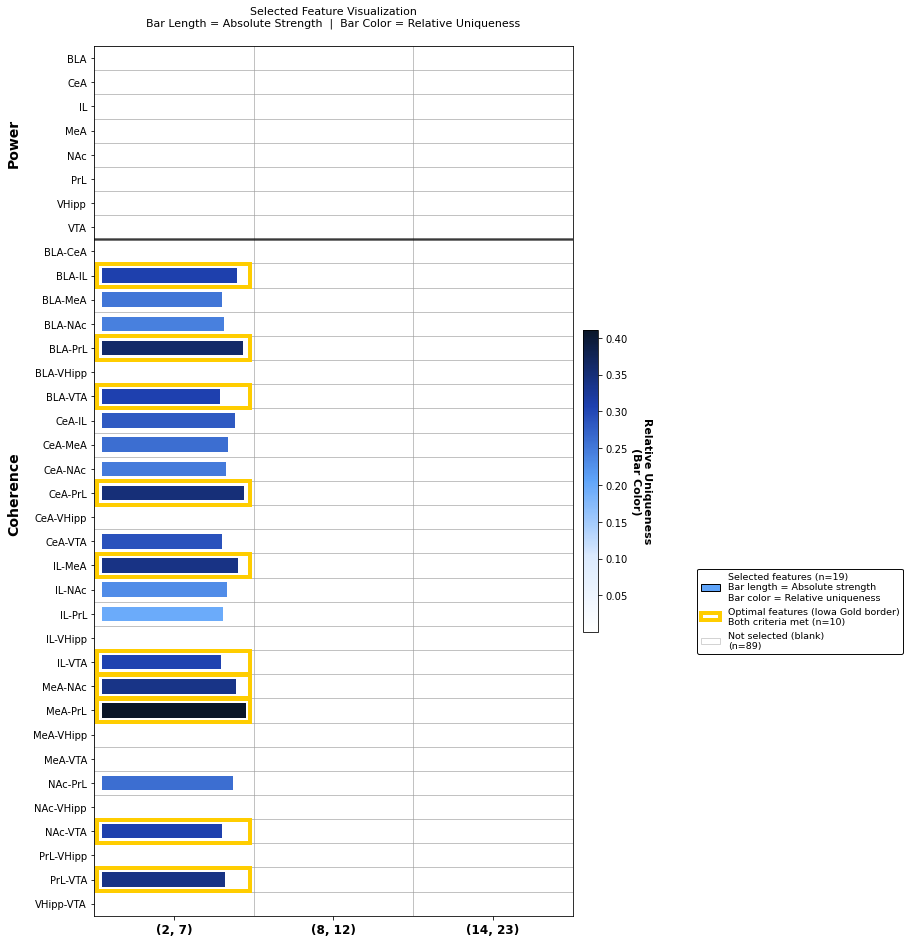

In [8]:
# ===== （outputtable）=====
# Step1：data（ - ，process_W_nmf_allverbose）
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.6, 
    rel_val=0.3
)

# Step2：
fig = create_bar_heatmap_selective(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

# Step3：save
plt.savefig('Selection_Licking_60.png', dpi=300, bbox_inches='tight')
plt.savefig('Selection_Licking_60.pdf', bbox_inches='tight')

plt.show()

Step 1: Check Row L2 Norms
Factor 0: 10.3923063278
Factor 1: 10.3923053741
Factor 2: 10.3923044205
Factor 3: 10.3923053741
Factor 4: 10.3923034668
Factor 5: 10.3923034668
Factor 6: 10.3923053741
Factor 7: 10.3923034668
Factor 8: 10.3923034668
Factor 9: 10.3923025131
✓ All row L2 norms are equal: 10.392306

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.5
Selected features: 15/108

--- Absolute Strength (After Cutoff) ---
           (2, 7)  (8, 12)  (14, 23)
BLA           NaN      NaN       NaN
CeA           NaN      NaN       NaN
IL            NaN      NaN       NaN
MeA           NaN      NaN       NaN
NAc           NaN      NaN       NaN
PrL           NaN      NaN       NaN
VHipp         NaN      NaN       NaN
VTA           NaN      NaN       NaN
BLA-CeA       NaN      NaN       NaN
BLA-IL     1.9167      NaN       NaN
BLA-MeA    1.7046      NaN       NaN
BLA-NAc    1.7285      NaN       NaN
BLA-PrL    1.9978      NaN       NaN
BLA-VHipp

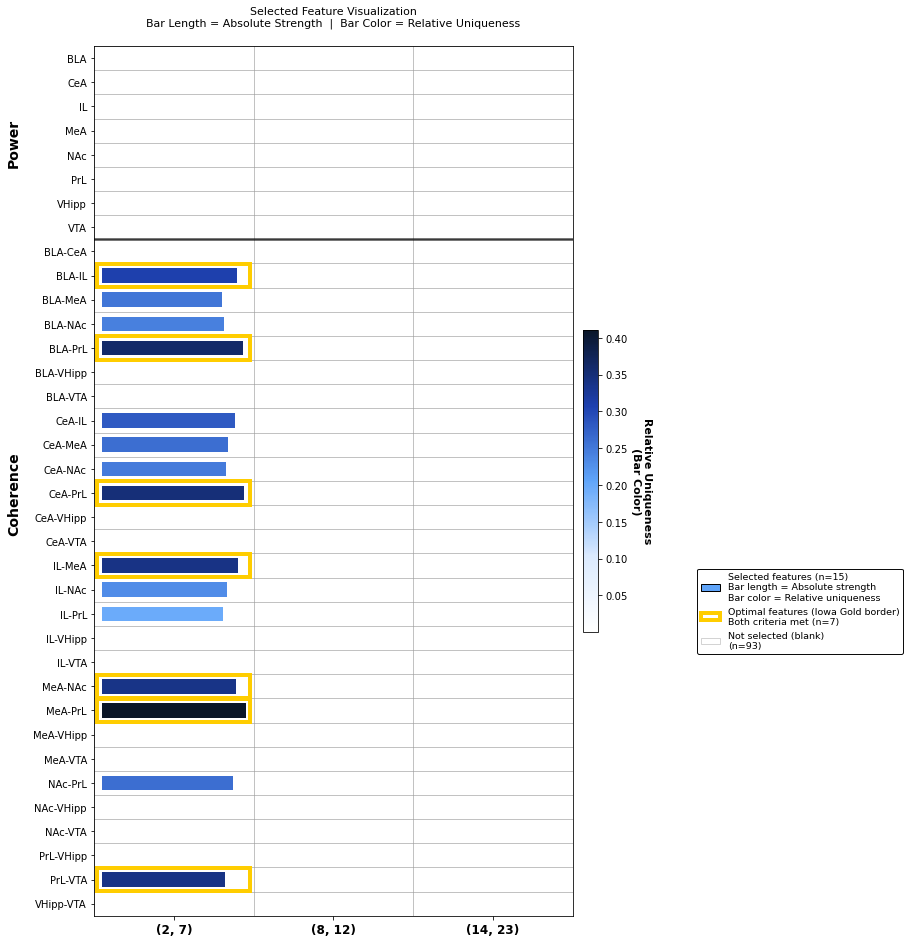

In [9]:
# ===== （outputtable）=====
# Step1：data（ - ，process_W_nmf_allverbose）
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.5, 
    rel_val=0.3
)

# Step2：
fig = create_bar_heatmap_selective(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

# Step3：save
plt.savefig('Selection_Licking_50.png', dpi=300, bbox_inches='tight')
plt.savefig('Selection_Licking_50.pdf', bbox_inches='tight')

plt.show()

# Test on Other data/validation

In [37]:
MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"
model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'
model.eval()

dCSFA_NMF(
  (recon_loss_f): MSELoss()
  (Encoder): Sequential(
    (0): Linear(in_features=108, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=64, out_features=10, bias=True)
    (4): Softplus(beta=1, threshold=20)
  )
  (phi_list): ParameterList(  (0): Parameter containing: [torch.FloatTensor of size 1])
  (beta_list): ParameterList(  (0): Parameter containing: [torch.FloatTensor of size 1x1])
)

In [38]:
# ================================================================
# Test Model on All Datasets
# ================================================================

def calculate_per_mouse_auc(model, X, y_true, mouse_ids, dataset_name):
    """Calculate overall and per-mouse AUC statistics"""
    # Ensure eval mode
    model.eval()
    with torch.no_grad():
        y_pred_proba, s = model.predict_proba(X, include_scores=True)
    
    # Flatten arrays
    y_true_flat = y_true.flatten() if len(y_true.shape) > 1 else y_true
    y_pred_flat = y_pred_proba.flatten() if len(y_pred_proba.shape) > 1 else y_pred_proba
    
    # Overall AUC
    overall_auc = roc_auc_score(y_true_flat, y_pred_flat)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name}")
    print(f"{'='*60}")
    print(f"Overall AUC: {overall_auc:.4f}")
    
    # Per-mouse AUC
    unique_mouse_ids = np.unique(mouse_ids)
    per_mouse_results = []
    
    print("\nPer-mouse AUC:")
    for mouse_id in unique_mouse_ids:
        mouse_mask = mouse_ids == mouse_id
        y_true_mouse = y_true_flat[mouse_mask]
        y_pred_mouse = y_pred_flat[mouse_mask]
        
        if len(np.unique(y_true_mouse)) > 1:
            mouse_auc = roc_auc_score(y_true_mouse, y_pred_mouse)
            per_mouse_results.append({
                'Mouse_ID': mouse_id,
                'AUC': mouse_auc,
                'N_samples': len(y_true_mouse),
                'N_label_0': int(np.sum(y_true_mouse == 0)),
                'N_label_1': int(np.sum(y_true_mouse == 1))
            })
            print(f"  {mouse_id}: {mouse_auc:.4f}")
        else:
            print(f"  {mouse_id}: SKIPPED (single class)")
    
    # Mouse-wise statistics
    per_mouse_aucs = [r['AUC'] for r in per_mouse_results]
    
    if per_mouse_aucs:
        mean_auc = np.mean(per_mouse_aucs)
        std_auc = np.std(per_mouse_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(per_mouse_aucs))
        
        print(f"\nMouse-wise AUC statistics:")
        print(f"  Mean: {mean_auc:.4f}")
        print(f"  SEM: {sem_auc:.4f}")
        print(f"  STD: {std_auc:.4f}")
        print(f"  N mice: {len(per_mouse_aucs)}")
        
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': per_mouse_aucs,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_mice': len(per_mouse_aucs),
            'per_mouse_details': per_mouse_results,
            's_scores': s,
            'y_pred_proba': y_pred_flat
        }
    else:
        print("\n⚠️  No mice with both classes")
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': [],
            'mean_auc': None,
            'std_auc': None,
            'sem_auc': None,
            'n_mice': 0,
            'per_mouse_details': [],
            's_scores': s,
            'y_pred_proba': y_pred_flat
        }


# ================================================================
# Test on All Datasets
# ================================================================

from scipy.stats import wilcoxon

print("=" * 60)
print("Testing Model on All 4 Datasets")
print("=" * 60)

# Test datasets
test_datasets = [
    ("Licking_C (Training)", X_Licking_C, y_Licking_C, mouse_ids_Licking_C),
    ("Licking_E", X_Licking_E, y_Licking_E, mouse_ids_Licking_E),
    ("Onnest_C", X_Onnest_C, y_Onnest_C, mouse_ids_Onnest_C),
    ("Onnest_E", X_Onnest_E, y_Onnest_E, mouse_ids_Onnest_E)
]

# Store results for summary
all_results = []

# Test on each dataset
for dataset_name, X_test, y_test, mouse_ids_test in test_datasets:
    # Calculate AUC - 
    result = calculate_per_mouse_auc(model, X_test, y_test, mouse_ids_test, dataset_name)
    
    # Add dataset name to result
    result['dataset'] = dataset_name
    result['n_samples'] = len(X_test)
    
    all_results.append(result)

# ================================================================
# Statistical Tests
# ================================================================

print(f"\n{'='*80}")
print("STATISTICAL TESTS - Wilcoxon Signed-Rank Test (One-Sided)")
print(f"{'='*80}")

for result in all_results:
    dataset_name = result['dataset']
    per_mouse_aucs = result['per_mouse_aucs']
    mean_auc = result['mean_auc']
    sem_auc = result['sem_auc']
    
    print(f"\n{dataset_name}:")
    
    if per_mouse_aucs and len(per_mouse_aucs) > 0:
        aucs_array = np.array(per_mouse_aucs)
        n_mice = len(aucs_array)
        
        # Compute differences from 0.5
        differences = aucs_array - 0.5
        
        # Perform one-sided Wilcoxon signed-rank test
        statistic, p_value = wilcoxon(differences, alternative='greater')
        
        if p_value < 0.001:
            significance = "***"
        elif p_value < 0.01:
            significance = "**"
        elif p_value < 0.05:
            significance = "*"
        else:
            significance = "ns"
        
        n_above = np.sum(aucs_array > 0.5)
        
        print(f"  Mean±SEM: {mean_auc:.4f}±{sem_auc:.4f} (n={n_mice} mice)")
        print(f"  Wilcoxon test: statistic={statistic}, p={p_value:.6f} {significance}")
        print(f"  Mice with AUC>0.5: {n_above}/{n_mice}")
        
        # Store test results
        result['p_value'] = p_value
        result['significance'] = significance
    else:
        print(f"  No valid data for statistical test")
        result['p_value'] = None
        result['significance'] = 'N/A'

# ================================================================
# Summary Table
# ================================================================

print(f"\n{'='*100}")
print("SUMMARY OF ALL TESTS")
print(f"{'='*100}")
print(f"{'Dataset':<23} {'N_Samples':<10} {'N_Mice':<8} {'Overall_AUC':<12} {'Mean±SEM':<20} {'p-value':<12} {'Sig':<8}")
print(f"{'-'*100}")

for result in all_results:
    dataset = result['dataset']
    n_samples = result['n_samples']
    n_mice = result['n_mice']
    overall_auc = result['overall_auc']
    mean_auc = result['mean_auc']
    sem_auc = result['sem_auc']
    p_value = result.get('p_value')
    significance = result.get('significance', 'N/A')
    
    if mean_auc is not None and sem_auc is not None:
        mean_sem_str = f"{mean_auc:.4f}±{sem_auc:.4f}"
    else:
        mean_sem_str = "N/A"
    
    p_value_str = f"{p_value:.6f}" if p_value is not None else "N/A"
    
    print(f"{dataset:<23} {n_samples:<10} {n_mice:<8} {overall_auc:<12.4f} {mean_sem_str:<20} {p_value_str:<12} {significance:<8}")

# ================================================================
# Interpretation
# ================================================================

print(f"\n{'='*100}")
print("INTERPRETATION:")
print(f"{'='*100}")
print("- Licking_C (Training): Performance on training data")
print("- Licking_E: Cross-mouse generalization (same task)")
print("- Onnest_C: Cross-task generalization (same mice)")  
print("- Onnest_E: Cross-mouse AND cross-task generalization")
print("\nNote: Model was trained on Licking_C to predict licking behavior")
print("Cross-task tests (Onnest_C/E) show how well licking features predict nest behavior")
print("\nStatistical Testing:")
print("  - Wilcoxon signed-rank test (one-sided) tests if AUC > 0.5 (chance level)")
print("  - Significance: *** p<0.001, ** p<0.01, * p<0.05, ns: not significant")
print("  - Reporting: Mean ± SEM (Standard Error of Mean) for publication")

# ================================================================
# Performance Comparison
# ================================================================

print(f"\n{'='*100}")
print("PERFORMANCE COMPARISON:")
print(f"{'='*100}")

if all_results[0]['mean_auc'] is not None:
    training_auc = all_results[0]['mean_auc']
    print(f"Training (Licking_C): {training_auc:.4f}")
    
    for i in range(1, len(all_results)):
        if all_results[i]['mean_auc'] is not None:
            test_auc = all_results[i]['mean_auc']
            diff = test_auc - training_auc
            dataset_name = all_results[i]['dataset']
            print(f"{dataset_name}: {test_auc:.4f} (Δ = {diff:+.4f})")

print(f"\n{'='*100}")

Testing Model on All 4 Datasets

Licking_C (Training)
Overall AUC: 0.7833

Per-mouse AUC:
  C1ELS32: 0.4558
  C2ELS18: 0.8898
  C5ELS20: 0.7472
  C5ELS40: 0.8613
  C6ELS42: 0.7104
  C7ELS11: 0.9252
  C7ELS22: 0.9172
  C7ELS45: 0.8922

Mouse-wise AUC statistics:
  Mean: 0.7999
  SEM: 0.0565
  STD: 0.1599
  N mice: 8

Licking_E
Overall AUC: 0.8093

Per-mouse AUC:
  E1ELS33: 0.7359
  E2ELS3: 0.4401
  E3ELS37: 0.8571
  E4ELS39: 0.9116
  E5ELS41: 0.4943
  E6ELS44: 0.7972

Mouse-wise AUC statistics:
  Mean: 0.7060
  SEM: 0.0795
  STD: 0.1948
  N mice: 6

Onnest_C
Overall AUC: 0.2963

Per-mouse AUC:
  C1ELS32: 0.4251
  C2ELS18: 0.1853
  C5ELS20: 0.3159
  C5ELS40: 0.1497
  C6ELS42: 0.2929
  C7ELS11: 0.1867
  C7ELS22: 0.1269
  C7ELS45: 0.3148

Mouse-wise AUC statistics:
  Mean: 0.2497
  SEM: 0.0365
  STD: 0.1031
  N mice: 8

Onnest_E
Overall AUC: 0.2410

Per-mouse AUC:
  E1ELS33: 0.3221
  E2ELS3: 0.5861
  E3ELS37: 0.1878
  E4ELS39: 0.2035
  E5ELS41: 0.4731
  E6ELS44: 0.2860

Mouse-wise AUC stat

# Backproject on the FULL Stages

In [48]:
TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combine/full_spec_features_8roi.pkl"
X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]


with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

X_data = np.hstack([train_dict[feature]*weight for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS)])
mouse_id = train_dict['mouse_id']

def clean_mouse_id(mouse_id):
    import re
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in mouse_id])
print(f"Original mouse IDs sample: {mouse_id[:5]}")
print(f"Cleaned mouse IDs sample: {cleaned_mouse_ids[:5]}")
print(f"Unique cleaned mouse IDs: {np.unique(cleaned_mouse_ids)}")


# Define mouse ID classification
c_mice_ids = ['C6ELS9', 'C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
              'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
e_mice_ids = ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']

Original mouse IDs sample: ['MouseC1ELS1' 'MouseC1ELS1' 'MouseC1ELS1' 'MouseC1ELS1' 'MouseC1ELS1']
Cleaned mouse IDs sample: ['C1ELS1' 'C1ELS1' 'C1ELS1' 'C1ELS1' 'C1ELS1']
Unique cleaned mouse IDs: ['C1ELS1' 'C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C6ELS9'
 'C7ELS11' 'C7ELS22' 'C7ELS45' 'E1ELS33' 'E2ELS3' 'E2ELS35' 'E3ELS37'
 'E4ELS39' 'E5ELS41' 'E6ELS43' 'E6ELS44']


In [50]:
MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"

model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'

model.eval()
_, scores = model.predict_proba(X_data, include_scores=True)

In [51]:
def assign_mouse_type(mouse_id):
    if mouse_id in c_mice_ids:
        return 'C mice'
    elif mouse_id in e_mice_ids:
        return 'E mice'
    else:
        return 'Other'

def categorize_period_six_groups(period):
    if period in ['Pre home', 'Pre pup']:
        return 'Pre'
    elif period == 'Ges':
        return 'Ges'
    elif period == 'P1':
        return 'P1'
    elif period == 'P3':
        return 'P3'
    elif period in ['P4 home', 'P4 open']:
        return 'P4'
    elif period == 'P8':
        return 'P8'
    elif period == 'P14':
        return 'P14'
    elif period == 'P20':
        return 'P20'
    else:
        return 'Other'

from scipy.stats import wilcoxon

# Filter to only target mice with at least 3 stages
def filter_target_mice_with_3plus_stages(df, target_c_ids, target_e_ids, min_stages=3):
    """Filter to only target mice with at least min_stages stages"""
    # Filter to only target mice
    target_mice = df[df['mouse_id'].isin(target_c_ids + target_e_ids)].copy()
    
    # Count stages per mouse
    mouse_stage_counts = target_mice.groupby('mouse_id')['stage'].nunique()
    
    # Get mice with at least min_stages stages
    mice_with_enough_stages = mouse_stage_counts[mouse_stage_counts >= min_stages].index.tolist()
    
    # Filter dataframe
    filtered_df = target_mice[target_mice['mouse_id'].isin(mice_with_enough_stages)].copy()
    
    return filtered_df, mice_with_enough_stages

In [52]:
from scipy import stats
def create_four_visualizations_with_tables(filtered_df, selected_mice, order):
    """Create all four requested visualizations with detailed tables
    
    Note: For P4 stage, only the first 20 minutes (400 time windows) are used per mouse
    """
    
    # ================================================================
    # DATA FILTERING: Keep only first 20 minutes of P4 recordings
    # ================================================================
    print("\n" + "="*80)
    print("DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY")
    print("="*80)
    
    filtered_df = filtered_df.copy()
    
    # Process P4 data for each mouse
    p4_filtering_stats = []
    rows_to_drop = []
    
    for mouse_id in selected_mice:
        # Get P4 data for this mouse
        p4_mask = (filtered_df['mouse_id'] == mouse_id) & (filtered_df['stage'] == 'P4')
        p4_indices = filtered_df[p4_mask].index
        
        if len(p4_indices) > 0:
            original_count = len(p4_indices)
            
            # Keep only first 400 windows (20 minutes * 60 seconds / 3 seconds per window)
            max_windows = 400
            
            if original_count > max_windows:
                # Mark indices to drop (everything after first 400 windows)
                indices_to_drop = p4_indices[max_windows:]
                rows_to_drop.extend(indices_to_drop.tolist())
                kept_count = max_windows
            else:
                kept_count = original_count
            
            removed_count = original_count - kept_count
            
            p4_filtering_stats.append({
                'Mouse_ID': mouse_id,
                'Original_Windows': original_count,
                'Kept_Windows': kept_count,
                'Removed_Windows': removed_count,
                'Total_Minutes': original_count * 3 / 60,
                'Kept_Minutes': kept_count * 3 / 60
            })
    
    # Drop the rows
    if rows_to_drop:
        print(f"\nRemoving {len(rows_to_drop)} time windows from P4 data...")
        filtered_df = filtered_df.drop(rows_to_drop)
        print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    if p4_filtering_stats:
        p4_stats_df = pd.DataFrame(p4_filtering_stats)
        print("\nP4 Data Filtering Summary:")
        print(p4_stats_df.to_string(index=False))
        print(f"\nTotal windows removed from P4: {p4_stats_df['Removed_Windows'].sum()}")
    else:
        print("\nNo P4 data found for selected mice.")
    
    print("\n" + "="*80)
    print("PROCEEDING WITH FILTERED DATA")
    print("="*80)
    
    # Calculate global y-axis limits for consistent scaling
    global_min = filtered_df['s0'].min()
    global_max = filtered_df['s0'].max()
    y_padding = (global_max - global_min) * 0.1
    global_ylim = [global_min - y_padding, global_max + y_padding]
    
    # Split mice by type
    c_mice_selected = [m for m in selected_mice if m in c_mice_ids]
    e_mice_selected = [m for m in selected_mice if m in e_mice_ids]
    
    print(f"\nSelected mice for analysis:")
    print(f"C mice ({len(c_mice_selected)}): {c_mice_selected}")
    print(f"E mice ({len(e_mice_selected)}): {e_mice_selected}")
    
    # Verify P4 filtering worked
    print("\nVerifying P4 data after filtering:")
    for mouse_id in selected_mice:
        p4_count = len(filtered_df[(filtered_df['mouse_id'] == mouse_id) & 
                                   (filtered_df['stage'] == 'P4')])
        if p4_count > 0:
            print(f"  {mouse_id}: {p4_count} P4 windows ({p4_count * 3 / 60:.1f} minutes)")
    
    # ================================================================
    # TABLE 1: Individual Mouse Scores by Stage
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 1: INDIVIDUAL MOUSE MEDIAN SCORES BY STAGE")
    print("="*80)
    
    individual_scores_data = []
    
    for mouse_id in selected_mice:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        mouse_type = mouse_data['mouse_type'].iloc[0]
        
        row = {'Mouse_ID': mouse_id, 'Type': mouse_type}
        
        for stage in order:
            stage_scores = mouse_data[mouse_data['stage'] == stage]['s0']
            if len(stage_scores) > 0:
                row[f'{stage}_median'] = stage_scores.median()
                row[f'{stage}_mean'] = stage_scores.mean()
                row[f'{stage}_std'] = stage_scores.std()
                row[f'{stage}_n'] = len(stage_scores)
            else:
                row[f'{stage}_median'] = np.nan
                row[f'{stage}_mean'] = np.nan
                row[f'{stage}_std'] = np.nan
                row[f'{stage}_n'] = 0
        
        individual_scores_data.append(row)
    
    individual_scores_df = pd.DataFrame(individual_scores_data)
    
    # Display median scores table
    median_cols = ['Mouse_ID', 'Type'] + [f'{stage}_median' for stage in order]
    print("\nMedian Scores:")
    print(individual_scores_df[median_cols].to_string(index=False))
    
    # Display sample counts
    n_cols = ['Mouse_ID', 'Type'] + [f'{stage}_n' for stage in order]
    print("\nSample Counts (note: P4 limited to first 20 minutes = 400 windows max):")
    print(individual_scores_df[n_cols].to_string(index=False))
    
    # ================================================================
    # TABLE 2: Individual Mouse Percentage Changes from Pre Baseline
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 2: INDIVIDUAL MOUSE PERCENTAGE CHANGES FROM PRE BASELINE")
    print("="*80)
    
    mouse_pct_changes = {}
    mouse_median_scores = {}  # NEW: Store median scores for each mouse/stage
    pct_change_data = []
    
    for mouse_id in selected_mice:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        mouse_type = mouse_data['mouse_type'].iloc[0]
        
        # Get Pre baseline
        pre_data = mouse_data[mouse_data['stage'] == 'Pre']['s0']
        if len(pre_data) == 0:
            continue
        
        pre_baseline = pre_data.median()
        
        row = {
            'Mouse_ID': mouse_id, 
            'Type': mouse_type,
            'Pre_baseline': pre_baseline
        }
        
        # Calculate percentage changes and store median scores
        pct_changes = {}
        median_scores = {}
        
        for stage in order:
            stage_data = mouse_data[mouse_data['stage'] == stage]['s0']
            
            if len(stage_data) > 0:
                stage_median = stage_data.median()
                median_scores[stage] = stage_median  # Store median score
                
                if stage == 'Pre':
                    pct_changes[stage] = 0
                    row[stage] = 0.0
                else:
                    pct_change = ((stage_median - pre_baseline) / abs(pre_baseline)) * 100
                    pct_changes[stage] = pct_change
                    row[stage] = pct_change
            else:
                median_scores[stage] = np.nan
                pct_changes[stage] = np.nan
                row[stage] = np.nan
        
        mouse_pct_changes[mouse_id] = pct_changes
        mouse_median_scores[mouse_id] = median_scores  # NEW: Store median scores
        pct_change_data.append(row)
    
    pct_change_df = pd.DataFrame(pct_change_data)
    print(pct_change_df.to_string(index=False, float_format='%.2f'))
    
    # ================================================================
    # TABLE 3: Group Average Scores (C vs E)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 3: GROUP AVERAGE SCORES BY STAGE")
    print("="*80)
    
    group_scores_data = []
    
    for mouse_type in ['C mice', 'E mice']:
        row = {'Group': mouse_type}
        
        for stage in order:
            stage_type_data = filtered_df[
                (filtered_df['stage'] == stage) & 
                (filtered_df['mouse_type'] == mouse_type)
            ]['s0']
            
            if len(stage_type_data) > 0:
                row[f'{stage}_mean'] = stage_type_data.mean()
                row[f'{stage}_median'] = stage_type_data.median()
                row[f'{stage}_std'] = stage_type_data.std()
                row[f'{stage}_sem'] = stage_type_data.sem()
                row[f'{stage}_n'] = len(stage_type_data)
            else:
                row[f'{stage}_mean'] = np.nan
                row[f'{stage}_median'] = np.nan
                row[f'{stage}_std'] = np.nan
                row[f'{stage}_sem'] = np.nan
                row[f'{stage}_n'] = 0
        
        group_scores_data.append(row)
    
    group_scores_df = pd.DataFrame(group_scores_data)
    
    # Display mean ± SEM
    print("\nMean ± SEM:")
    for _, row in group_scores_df.iterrows():
        print(f"\n{row['Group']}:")
        for stage in order:
            mean_val = row[f'{stage}_mean']
            sem_val = row[f'{stage}_sem']
            n_val = row[f'{stage}_n']
            if not np.isnan(mean_val):
                print(f"  {stage:12s}: {mean_val:7.4f} ± {sem_val:7.4f} (n={int(n_val)})")
            else:
                print(f"  {stage:12s}: No data")
    
    # ================================================================
    # TABLE 4: Group Average Percentage Changes from Pre
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 4: GROUP AVERAGE PERCENTAGE CHANGES FROM PRE BASELINE")
    print("="*80)
    
    group_pct_data = []
    
    for mouse_type_name in ['C mice', 'E mice']:
        row = {'Group': mouse_type_name}
        
        mice_list = c_mice_selected if mouse_type_name == 'C mice' else e_mice_selected
        
        for stage in order:
            if stage == 'Pre':
                row[f'{stage}_mean'] = 0.0
                row[f'{stage}_std'] = 0.0
                row[f'{stage}_sem'] = 0.0
                row[f'{stage}_n'] = len(mice_list)
            else:
                stage_changes = []
                for mouse_id in mice_list:
                    if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                        if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                            stage_changes.append(mouse_pct_changes[mouse_id][stage])
                
                if stage_changes:
                    row[f'{stage}_mean'] = np.mean(stage_changes)
                    row[f'{stage}_std'] = np.std(stage_changes, ddof=1)
                    row[f'{stage}_sem'] = np.std(stage_changes, ddof=1) / np.sqrt(len(stage_changes))
                    row[f'{stage}_n'] = len(stage_changes)
                else:
                    row[f'{stage}_mean'] = np.nan
                    row[f'{stage}_std'] = np.nan
                    row[f'{stage}_sem'] = np.nan
                    row[f'{stage}_n'] = 0
        
        group_pct_data.append(row)
    
    group_pct_df = pd.DataFrame(group_pct_data)
    
    # Display
    print("\nMean ± SEM (%):")
    for _, row in group_pct_df.iterrows():
        print(f"\n{row['Group']}:")
        for stage in order:
            mean_val = row[f'{stage}_mean']
            sem_val = row[f'{stage}_sem']
            n_val = row[f'{stage}_n']
            if not np.isnan(mean_val):
                print(f"  {stage:12s}: {mean_val:7.2f}% ± {sem_val:7.2f}% (n={int(n_val)})")
            else:
                print(f"  {stage:12s}: No data")
    
    # ================================================================
    # TABLE 5: Statistical Tests (Wilcoxon Rank-Sum on Percentage Changes)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 5: WILCOXON RANK-SUM TEST ON PERCENTAGE CHANGES (C mice vs E mice)")
    print("="*80)
    
    statistical_tests_data = []
    
    for stage in order:
        if stage == 'Pre':
            statistical_tests_data.append({
                'Stage': stage,
                'C_n_mice': len(c_mice_selected),
                'C_mean_pct': 0.0,
                'C_median_pct': 0.0,
                'C_std_pct': 0.0,
                'E_n_mice': len(e_mice_selected),
                'E_mean_pct': 0.0,
                'E_median_pct': 0.0,
                'E_std_pct': 0.0,
                'U_statistic': np.nan,
                'p_value': np.nan,
                'rank_biserial': np.nan,
                'significance': 'N/A (baseline)'
            })
            continue
        
        # Collect C group percentage changes
        c_pct_changes = []
        for mouse_id in c_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    c_pct_changes.append(mouse_pct_changes[mouse_id][stage])
        
        # Collect E group percentage changes
        e_pct_changes = []
        for mouse_id in e_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    e_pct_changes.append(mouse_pct_changes[mouse_id][stage])
        
        # Perform statistical test
        if len(c_pct_changes) > 0 and len(e_pct_changes) > 0:
            statistic, p_value = stats.mannwhitneyu(c_pct_changes, e_pct_changes, alternative='two-sided')
            
            n1, n2 = len(c_pct_changes), len(e_pct_changes)
            u_statistic = statistic
            rank_biserial = 1 - (2*u_statistic) / (n1 * n2)
            
            if p_value < 0.001:
                significance = '***'
            elif p_value < 0.01:
                significance = '**'
            elif p_value < 0.05:
                significance = '*'
            else:
                significance = 'ns'
            
            statistical_tests_data.append({
                'Stage': stage,
                'C_n_mice': n1,
                'C_mean_pct': np.mean(c_pct_changes),
                'C_median_pct': np.median(c_pct_changes),
                'C_std_pct': np.std(c_pct_changes, ddof=1),
                'E_n_mice': n2,
                'E_mean_pct': np.mean(e_pct_changes),
                'E_median_pct': np.median(e_pct_changes),
                'E_std_pct': np.std(e_pct_changes, ddof=1), 
                'U_statistic': u_statistic,
                'p_value': p_value,
                'rank_biserial': rank_biserial,
                'significance': significance
            })
        else:
            statistical_tests_data.append({
                'Stage': stage,
                'C_n_mice': len(c_pct_changes),
                'C_mean_pct': np.nan,
                'C_median_pct': np.nan,
                'C_std_pct': np.nan,
                'E_n_mice': len(e_pct_changes),
                'E_mean_pct': np.nan,
                'E_median_pct': np.nan,
                'E_std_pct': np.nan,
                'U_statistic': np.nan,
                'p_value': np.nan,
                'rank_biserial': np.nan,
                'significance': 'N/A'
            })
    
    statistical_tests_df = pd.DataFrame(statistical_tests_data)
    
    # Display results
    print("\nWilcoxon Rank-Sum Test Results (% change from Pre baseline):")
    print("-" * 80)
    for _, row in statistical_tests_df.iterrows():
        if row['Stage'] == 'Pre':
            print(f"{row['Stage']:12s}: Baseline (no comparison)")
        elif not np.isnan(row['p_value']):
            print(f"{row['Stage']:12s}: "
                  f"C(n={int(row['C_n_mice'])}, mean={row['C_mean_pct']:6.2f}%, std={row['C_std_pct']:5.2f}) vs "
                  f"E(n={int(row['E_n_mice'])}, mean={row['E_mean_pct']:6.2f}%, std={row['E_std_pct']:5.2f}) | "
                  f"U={row['U_statistic']:.1f}, p={row['p_value']:.4f} {row['significance']}")
        else:
            print(f"{row['Stage']:12s}: Insufficient data")
    
    print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
    print("Note: Test compares percentage changes from Pre baseline between C and E groups")
    print("      Each mouse's percentage change is calculated relative to its own Pre baseline")
    print("      P4 data limited to first 20 minutes per mouse")
    
    # ================================================================
    # Save all tables to CSV
    # ================================================================
    individual_scores_df.to_csv('individual_scores_by_stage.csv', index=False)
    pct_change_df.to_csv('individual_percentage_changes.csv', index=False)
    group_scores_df.to_csv('group_scores_by_stage.csv', index=False)
    group_pct_df.to_csv('group_percentage_changes.csv', index=False)
    statistical_tests_df.to_csv('statistical_tests_c_vs_e.csv', index=False)
    
    if p4_filtering_stats:
        p4_stats_df.to_csv('p4_filtering_summary.csv', index=False)
    
    # ================================================================
    # Continue with original visualizations
    # ================================================================
    n_mice = len(selected_mice)
    n_cols = 4
    n_rows = (n_mice + n_cols - 1) // n_cols
    
    # FIGURE 1: Individual mouse boxplots
    fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    fig1.suptitle('Individual Mouse Score Distributions by Stage\n(P4: First 20 minutes only)', 
                  fontsize=16, y=0.95)
    
    if n_rows == 1:
        axes1 = axes1.reshape(1, -1)
    
    for i, mouse_id in enumerate(selected_mice):
        row, col = i // n_cols, i % n_cols
        ax = axes1[row, col]
        
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        mouse_type = mouse_data['mouse_type'].iloc[0]
        
        stage_data = []
        stage_labels = []
        for stage in order:
            stage_scores = mouse_data[mouse_data['stage'] == stage]['s0']
            if len(stage_scores) > 0:
                stage_data.append(stage_scores.values)
                stage_labels.append(stage)
        
        if stage_data:
            bp = ax.boxplot(stage_data, labels=stage_labels, patch_artist=True)
            color = 'lightblue' if mouse_type == 'C mice' else 'lightcoral'
            for patch in bp['boxes']:
                patch.set_facecolor(color)
        
        ax.set_title(f'{mouse_id} ({mouse_type})', fontsize=12)
        ax.set_ylabel('Score (s0)' if col == 0 else '')
        ax.set_ylim(global_ylim)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
    
    for i in range(n_mice, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes1[row, col].set_visible(False)
    
    plt.tight_layout()
    
    # FIGURE 2: Individual percentage changes
    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    fig2.suptitle('Individual Mouse Percentage Changes from Pre Baseline\n(P4: First 20 minutes only)', 
                  fontsize=16, y=0.95)
    
    if n_rows == 1:
        axes2 = axes2.reshape(1, -1)
    
    for i, mouse_id in enumerate(selected_mice):
        if mouse_id not in mouse_pct_changes:
            continue
            
        row, col = i // n_cols, i % n_cols
        ax = axes2[row, col]
        
        mouse_type = filtered_df[filtered_df['mouse_id'] == mouse_id]['mouse_type'].iloc[0]
        pct_data = mouse_pct_changes[mouse_id]
        
        stages = list(pct_data.keys())
        values = list(pct_data.values())
        
        color = 'blue' if mouse_type == 'C mice' else 'red'
        ax.plot(stages, values, 'o-', color=color, linewidth=2, markersize=6)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
        
        ax.set_title(f'{mouse_id} ({mouse_type})', fontsize=12)
        ax.set_ylabel('% Change from Pre' if col == 0 else '')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        for stage, value in pct_data.items():
            if not np.isnan(value):
                ax.text(stage, value + 2, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
    
    for i in range(len(selected_mice), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes2[row, col].set_visible(False)
    
    plt.tight_layout()
    
    # FIGURE 3: Group comparison
    fig3, ax3 = plt.subplots(figsize=(12, 8))
    
    plot_data = []
    for stage in order:
        for mouse_type in ['C mice', 'E mice']:
            stage_type_data = filtered_df[
                (filtered_df['stage'] == stage) & 
                (filtered_df['mouse_type'] == mouse_type)
            ]['s0']
            
            for value in stage_type_data:
                plot_data.append({
                    'Stage': stage,
                    'Mouse_Type': mouse_type,
                    'Score': value
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    if not plot_df.empty:
        sns.boxplot(data=plot_df, x='Stage', y='Score', hue='Mouse_Type', 
                   palette={'C mice': 'lightblue', 'E mice': 'lightcoral'}, ax=ax3)
        
        ax3.set_title('Score Distributions by Stage and Mouse Type\n(P4: First 20 minutes only)', 
                     fontsize=14)
        ax3.set_ylabel('Score (s0)', fontsize=12)
        ax3.set_xlabel('Developmental Stage', fontsize=12)
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
        ax3.legend(title='Mouse Type')
    
    plt.tight_layout()
    
    # FIGURE 4: Group average percentage changes
    fig4, ax4 = plt.subplots(figsize=(12, 8))
    
    c_mice_changes = []
    e_mice_changes = []
    c_mice_sem = []
    e_mice_sem = []
    
    for stage in order:
        if stage == 'Pre':
            c_mice_changes.append(0)
            e_mice_changes.append(0)
            c_mice_sem.append(0)
            e_mice_sem.append(0)
            continue
        
        c_stage_changes = []
        for mouse_id in c_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    c_stage_changes.append(mouse_pct_changes[mouse_id][stage])
        
        e_stage_changes = []
        for mouse_id in e_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    e_stage_changes.append(mouse_pct_changes[mouse_id][stage])
        
        c_mice_changes.append(np.mean(c_stage_changes) if c_stage_changes else np.nan)
        e_mice_changes.append(np.mean(e_stage_changes) if e_stage_changes else np.nan)
        c_mice_sem.append(np.std(c_stage_changes, ddof=1) / np.sqrt(len(c_stage_changes)) if len(c_stage_changes) > 1 else 0)
        e_mice_sem.append(np.std(e_stage_changes, ddof=1) / np.sqrt(len(e_stage_changes)) if len(e_stage_changes) > 1 else 0)
    
    x = np.arange(len(order))
    offset = 0.1
    
    # Plot with error bars
    ax4.errorbar(x - offset, c_mice_changes, yerr=c_mice_sem, fmt='o-', color='blue', 
                 linewidth=3, markersize=10, capsize=5, label='C mice')
    ax4.errorbar(x + offset, e_mice_changes, yerr=e_mice_sem, fmt='o-', color='red', 
                 linewidth=3, markersize=10, capsize=5, label='E mice')
    
    ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    ax4.set_ylabel('Average % Change from Pre Baseline', fontsize=12)
    ax4.set_xlabel('Developmental Stage', fontsize=12)
    ax4.set_title('Group Average Percentage Growth from Pre Baseline\n(Mean ± SEM, P4: First 20 minutes only)', 
                 fontsize=14)
    ax4.set_xticks(x)
    ax4.set_xticklabels(order)
    ax4.grid(axis='y', alpha=0.3)
    ax4.legend()
    
    for i, (c_val, e_val) in enumerate(zip(c_mice_changes, e_mice_changes)):
        if not np.isnan(c_val):
            ax4.text(i - offset, c_val - c_mice_sem[i] - 2, f'{c_val:.1f}%', ha='center', va='top', 
                    fontsize=10, color='blue', weight='bold')
        if not np.isnan(e_val):
            ax4.text(i + offset, e_val + e_mice_sem[i] + 1, f'{e_val:.1f}%', ha='center', va='bottom', 
                    fontsize=10, color='red', weight='bold')
    
    plt.tight_layout()
    
    # ================================================================
    # Export Data to Excel (Enhanced Version with All Details)
    # ================================================================
    print("\n" + "="*80)
    print("EXPORTING DATA TO EXCEL (ENHANCED VERSION)")
    print("="*80)
    
    # ================================================================
    # Sheet 1: Summary_Mean_SEM
    # ================================================================
    mean_sem_export_data = []
    for i, stage in enumerate(order):
        row = {
            'Stage': stage,
            'C_mice_mean': c_mice_changes[i],
            'C_mice_SEM': c_mice_sem[i],
            'E_mice_mean': e_mice_changes[i],
            'E_mice_SEM': e_mice_sem[i]
        }
        mean_sem_export_data.append(row)
    
    mean_sem_df = pd.DataFrame(mean_sem_export_data)
    
    # ================================================================
    # Sheet 2: Summary_Median_IQR
    # ================================================================
    print("\nCalculating group-level median and IQR...")
    
    def get_group_stage_pct_changes(group_mice, stage):
        """Get percentage changes for a group at a specific stage"""
        changes = []
        for mouse_id in group_mice:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                val = mouse_pct_changes[mouse_id][stage]
                if not np.isnan(val):
                    changes.append(val)
        return np.array(changes)
    
    # Calculate median and IQR for each group and stage
    median_iqr_export_data = []
    for i, stage in enumerate(order):
        row = {'Stage': stage}
        
        # C mice
        c_changes = get_group_stage_pct_changes(c_mice_selected, stage)
        if len(c_changes) > 0:
            row['C_mice_median'] = np.median(c_changes)
            row['C_mice_Q1'] = np.percentile(c_changes, 25)
            row['C_mice_Q3'] = np.percentile(c_changes, 75)
            row['C_mice_IQR'] = row['C_mice_Q3'] - row['C_mice_Q1']
            row['C_mice_n'] = len(c_changes)
        else:
            row['C_mice_median'] = np.nan
            row['C_mice_Q1'] = np.nan
            row['C_mice_Q3'] = np.nan
            row['C_mice_IQR'] = np.nan
            row['C_mice_n'] = 0
        
        # E mice
        e_changes = get_group_stage_pct_changes(e_mice_selected, stage)
        if len(e_changes) > 0:
            row['E_mice_median'] = np.median(e_changes)
            row['E_mice_Q1'] = np.percentile(e_changes, 25)
            row['E_mice_Q3'] = np.percentile(e_changes, 75)
            row['E_mice_IQR'] = row['E_mice_Q3'] - row['E_mice_Q1']
            row['E_mice_n'] = len(e_changes)
        else:
            row['E_mice_median'] = np.nan
            row['E_mice_Q1'] = np.nan
            row['E_mice_Q3'] = np.nan
            row['E_mice_IQR'] = np.nan
            row['E_mice_n'] = 0
        
        median_iqr_export_data.append(row)
    
    median_iqr_df = pd.DataFrame(median_iqr_export_data)
    
    print("\nGroup Median ± IQR Summary:")
    print(median_iqr_df.to_string(index=False, float_format='%.2f'))
    
    # ================================================================
    # Sheet 3: C_mice_stage_detail (with Median_Score added)
    # ================================================================
    print("\nPreparing C_mice_stage_detail with median scores...")
    c_mice_stage_detail = []
    for stage in order:
        for mouse_id in c_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                row = {
                    'Stage': stage,
                    'Mouse_ID': mouse_id,
                    'Median_Score': mouse_median_scores[mouse_id][stage],
                    'Percentage_Change': mouse_pct_changes[mouse_id][stage]
                }
                c_mice_stage_detail.append(row)
    c_mice_stage_detail_df = pd.DataFrame(c_mice_stage_detail)
    
    # ================================================================
    # Sheet 4: E_mice_stage_detail (with Median_Score added)
    # ================================================================
    print("Preparing E_mice_stage_detail with median scores...")
    e_mice_stage_detail = []
    for stage in order:
        for mouse_id in e_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                row = {
                    'Stage': stage,
                    'Mouse_ID': mouse_id,
                    'Median_Score': mouse_median_scores[mouse_id][stage],
                    'Percentage_Change': mouse_pct_changes[mouse_id][stage]
                }
                e_mice_stage_detail.append(row)
    e_mice_stage_detail_df = pd.DataFrame(e_mice_stage_detail)
    
    # ================================================================
    # Sheet 5: C_All_TimeWindow (ALL raw time window scores)
    # ================================================================
    print("\nPreparing C_All_TimeWindow (this may take a while for large datasets)...")
    c_all_timewindow = []
    for mouse_id in c_mice_selected:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        for stage in order:
            stage_data = mouse_data[mouse_data['stage'] == stage]
            if len(stage_data) > 0:
                # Reset time window numbering for each mouse-stage combination
                for idx, (_, row) in enumerate(stage_data.iterrows(), start=1):
                    c_all_timewindow.append({
                        'Stage': stage,
                        'Mouse_ID': mouse_id,
                        'TimeWindow': idx,
                        'LoadingScore': row['s0']
                    })
    c_all_timewindow_df = pd.DataFrame(c_all_timewindow)
    print(f"  Total rows for C mice: {len(c_all_timewindow_df)}")
    
    # ================================================================
    # Sheet 6: E_All_TimeWindow (ALL raw time window scores)
    # ================================================================
    print("Preparing E_All_TimeWindow (this may take a while for large datasets)...")
    e_all_timewindow = []
    for mouse_id in e_mice_selected:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        for stage in order:
            stage_data = mouse_data[mouse_data['stage'] == stage]
            if len(stage_data) > 0:
                # Reset time window numbering for each mouse-stage combination
                for idx, (_, row) in enumerate(stage_data.iterrows(), start=1):
                    e_all_timewindow.append({
                        'Stage': stage,
                        'Mouse_ID': mouse_id,
                        'TimeWindow': idx,
                        'LoadingScore': row['s0']
                    })
    e_all_timewindow_df = pd.DataFrame(e_all_timewindow)
    print(f"  Total rows for E mice: {len(e_all_timewindow_df)}")
    
    # ================================================================
    # Sheet 7: C_mice_stage_detail_wide (pivot by Mouse_ID)
    # ================================================================
    print("\nPreparing C_mice_stage_detail_wide (pivot by Mouse_ID)...")
    if len(c_mice_stage_detail_df) > 0:
        # Create pivot table with Mouse_ID as columns
        c_mice_wide = c_mice_stage_detail_df.pivot(
            index='Stage',
            columns='Mouse_ID',
            values=['Median_Score', 'Percentage_Change']
        )
        # Flatten column names: (Median_Score, C1) -> C1_Median_Score
        c_mice_wide.columns = [f'{col[1]}_{col[0]}' for col in c_mice_wide.columns]
        c_mice_wide = c_mice_wide.reset_index()
        # Reorder columns: Stage, then for each mouse: Median_Score, Percentage_Change
        stage_col = ['Stage']
        mouse_cols = []
        for mouse_id in c_mice_selected:
            if f'{mouse_id}_Median_Score' in c_mice_wide.columns:
                mouse_cols.extend([f'{mouse_id}_Median_Score', f'{mouse_id}_Percentage_Change'])
        c_mice_stage_detail_wide_df = c_mice_wide[stage_col + mouse_cols]
    else:
        c_mice_stage_detail_wide_df = pd.DataFrame()
    
    print(f"  Shape: {c_mice_stage_detail_wide_df.shape}")
    
    # ================================================================
    # Sheet 8: E_mice_stage_detail_wide (pivot by Mouse_ID)
    # ================================================================
    print("Preparing E_mice_stage_detail_wide (pivot by Mouse_ID)...")
    if len(e_mice_stage_detail_df) > 0:
        # Create pivot table with Mouse_ID as columns
        e_mice_wide = e_mice_stage_detail_df.pivot(
            index='Stage',
            columns='Mouse_ID',
            values=['Median_Score', 'Percentage_Change']
        )
        # Flatten column names
        e_mice_wide.columns = [f'{col[1]}_{col[0]}' for col in e_mice_wide.columns]
        e_mice_wide = e_mice_wide.reset_index()
        # Reorder columns
        stage_col = ['Stage']
        mouse_cols = []
        for mouse_id in e_mice_selected:
            if f'{mouse_id}_Median_Score' in e_mice_wide.columns:
                mouse_cols.extend([f'{mouse_id}_Median_Score', f'{mouse_id}_Percentage_Change'])
        e_mice_stage_detail_wide_df = e_mice_wide[stage_col + mouse_cols]
    else:
        e_mice_stage_detail_wide_df = pd.DataFrame()
    
    print(f"  Shape: {e_mice_stage_detail_wide_df.shape}")
    
    # ================================================================
    # Sheet 9: C_All_TimeWindow_wide (pivot by Mouse_ID)
    # ================================================================
    print("Preparing C_All_TimeWindow_wide (pivot by Mouse_ID)...")
    if len(c_all_timewindow_df) > 0:
        # Pivot: Stage & TimeWindow as index, Mouse_ID as columns, LoadingScore as values
        c_timewindow_wide = c_all_timewindow_df.pivot(
            index=['Stage', 'TimeWindow'],
            columns='Mouse_ID',
            values='LoadingScore'
        )
        c_timewindow_wide = c_timewindow_wide.reset_index()
        c_all_timewindow_wide_df = c_timewindow_wide
    else:
        c_all_timewindow_wide_df = pd.DataFrame()
    
    print(f"  Shape: {c_all_timewindow_wide_df.shape}")
    
    # ================================================================
    # Sheet 10: E_All_TimeWindow_wide (pivot by Mouse_ID)
    # ================================================================
    print("Preparing E_All_TimeWindow_wide (pivot by Mouse_ID)...")
    if len(e_all_timewindow_df) > 0:
        # Pivot: Stage & TimeWindow as index, Mouse_ID as columns, LoadingScore as values
        e_timewindow_wide = e_all_timewindow_df.pivot(
            index=['Stage', 'TimeWindow'],
            columns='Mouse_ID',
            values='LoadingScore'
        )
        e_timewindow_wide = e_timewindow_wide.reset_index()
        e_all_timewindow_wide_df = e_timewindow_wide
    else:
        e_all_timewindow_wide_df = pd.DataFrame()
    
    print(f"  Shape: {e_all_timewindow_wide_df.shape}")
    
    # ================================================================
    # Save to Excel with multiple sheets (now with 10 sheets!)
    # ================================================================
    print("\nWriting to Excel file (this may take a moment)...")
    with pd.ExcelWriter('LickingEF.xlsx', engine='openpyxl') as writer:
        mean_sem_df.to_excel(writer, sheet_name='Summary_Mean_SEM', index=False)
        median_iqr_df.to_excel(writer, sheet_name='Summary_Median_IQR', index=False)
        c_mice_stage_detail_df.to_excel(writer, sheet_name='C_mice_stage_detail', index=False)
        e_mice_stage_detail_df.to_excel(writer, sheet_name='E_mice_stage_detail', index=False)
        c_all_timewindow_df.to_excel(writer, sheet_name='C_All_TimeWindow', index=False)
        e_all_timewindow_df.to_excel(writer, sheet_name='E_All_TimeWindow', index=False)
        # New wide format sheets
        c_mice_stage_detail_wide_df.to_excel(writer, sheet_name='C_mice_stage_detail_wide', index=False)
        e_mice_stage_detail_wide_df.to_excel(writer, sheet_name='E_mice_stage_detail_wide', index=False)
        c_all_timewindow_wide_df.to_excel(writer, sheet_name='C_All_TimeWindow_wide', index=False)
        e_all_timewindow_wide_df.to_excel(writer, sheet_name='E_All_TimeWindow_wide', index=False)
    
    print("\n" + "="*80)
    print("Excel file created: LickingEF.xlsx")
    print("="*80)
    print("\nSheet 1 - Summary_Mean_SEM: Mean ± SEM for each group and stage")
    print(mean_sem_df.to_string(index=False, float_format='%.4f'))
    print("\nSheet 2 - Summary_Median_IQR: Median ± IQR for each group and stage")
    print(median_iqr_df.to_string(index=False, float_format='%.2f'))
    print(f"\nSheet 3 - C_mice_stage_detail: {len(c_mice_stage_detail_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, Median_Score, Percentage_Change)")
    print(f"\nSheet 4 - E_mice_stage_detail: {len(e_mice_stage_detail_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, Median_Score, Percentage_Change)")
    print(f"\nSheet 5 - C_All_TimeWindow: {len(c_all_timewindow_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, TimeWindow, LoadingScore)")
    print(f"\nSheet 6 - E_All_TimeWindow: {len(e_all_timewindow_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, TimeWindow, LoadingScore)")
    print(f"\nSheet 7 - C_mice_stage_detail_wide: {c_mice_stage_detail_wide_df.shape} (WIDE format)")
    print("  (Stage, C1_Median_Score, C1_Percentage_Change, C2_Median_Score, ...)")
    print(f"\nSheet 8 - E_mice_stage_detail_wide: {e_mice_stage_detail_wide_df.shape} (WIDE format)")
    print("  (Stage, E1_Median_Score, E1_Percentage_Change, E2_Median_Score, ...)")
    print(f"\nSheet 9 - C_All_TimeWindow_wide: {c_all_timewindow_wide_df.shape} (WIDE format)")
    print("  (Stage, TimeWindow, C1, C2, C3, ... - each mouse as column)")
    print(f"\nSheet 10 - E_All_TimeWindow_wide: {e_all_timewindow_wide_df.shape} (WIDE format)")
    print("  (Stage, TimeWindow, E1, E2, E3, ... - each mouse as column)")
    print("="*80)
    
    print("\n" + "="*80)
    print("Files saved:")
    print("  CSV files:")
    print("    - individual_scores_by_stage.csv")
    print("    - individual_percentage_changes.csv")
    print("    - group_scores_by_stage.csv")
    print("    - group_percentage_changes.csv")
    print("    - statistical_tests_c_vs_e.csv")
    if p4_filtering_stats:
        print("    - p4_filtering_summary.csv")
    print("  Excel file:")
    print("    - LickingEF.xlsx (10 sheets)")
    print("      * Summary_Mean_SEM")
    print("      * Summary_Median_IQR")
    print("      * C_mice_stage_detail (LONG format)")
    print("      * E_mice_stage_detail (LONG format)")
    print("      * C_All_TimeWindow (LONG format)")
    print("      * E_All_TimeWindow (LONG format)")
    print("      * C_mice_stage_detail_wide (WIDE format - pivoted by Mouse_ID)")
    print("      * E_mice_stage_detail_wide (WIDE format - pivoted by Mouse_ID)")
    print("      * C_All_TimeWindow_wide (WIDE format - pivoted by Mouse_ID)")
    print("      * E_All_TimeWindow_wide (WIDE format - pivoted by Mouse_ID)")
    print("="*80)
    
    plt.show()
    
    return fig1, fig2, fig3, fig4, individual_scores_df, pct_change_df, group_scores_df, group_pct_df, statistical_tests_df


DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY

Removing 4108 time windows from P4 data...
Filtered dataframe shape: (185015, 5)

P4 Data Filtering Summary:
Mouse_ID  Original_Windows  Kept_Windows  Removed_Windows  Total_Minutes  Kept_Minutes
 C1ELS32               759           400              359        37.9500       20.0000
 C5ELS40               600           400              200        30.0000       20.0000
 C6ELS42               765           400              365        38.2500       20.0000
 C7ELS45               819           400              419        40.9500       20.0000
 E1ELS33               756           400              356        37.8000       20.0000
 E3ELS37               893           400              493        44.6500       20.0000
 E4ELS39               795           400              395        39.7500       20.0000
 E5ELS41              1652           400             1252        82.6000       20.0000
 E6ELS44               669           400              269


EXPORTING DATA TO EXCEL (ENHANCED VERSION)

Calculating group-level median and IQR...

Group Median ± IQR Summary:
Stage  C_mice_median  C_mice_Q1  C_mice_Q3  C_mice_IQR  C_mice_n  E_mice_median  E_mice_Q1  E_mice_Q3  E_mice_IQR  E_mice_n
  Pre           0.00       0.00       0.00        0.00         9           0.00       0.00       0.00        0.00         6
  Ges          -0.16      -7.43       2.23        9.66         9          -4.10      -6.25       4.79       11.05         6
   P1          -6.98     -11.77       2.11       13.88         7         -13.35     -18.05       2.89       20.94         4
   P3          -4.94      -9.44       4.09       13.52         8          -7.62     -10.01      19.21       29.22         6
   P4          -7.47      -8.57       3.93       12.50         4          -2.71      -4.41      -2.02        2.39         5
   P8          -9.33     -13.22      -1.81       11.41         8         -13.15     -21.41     -10.46       10.95         6
  P14          -

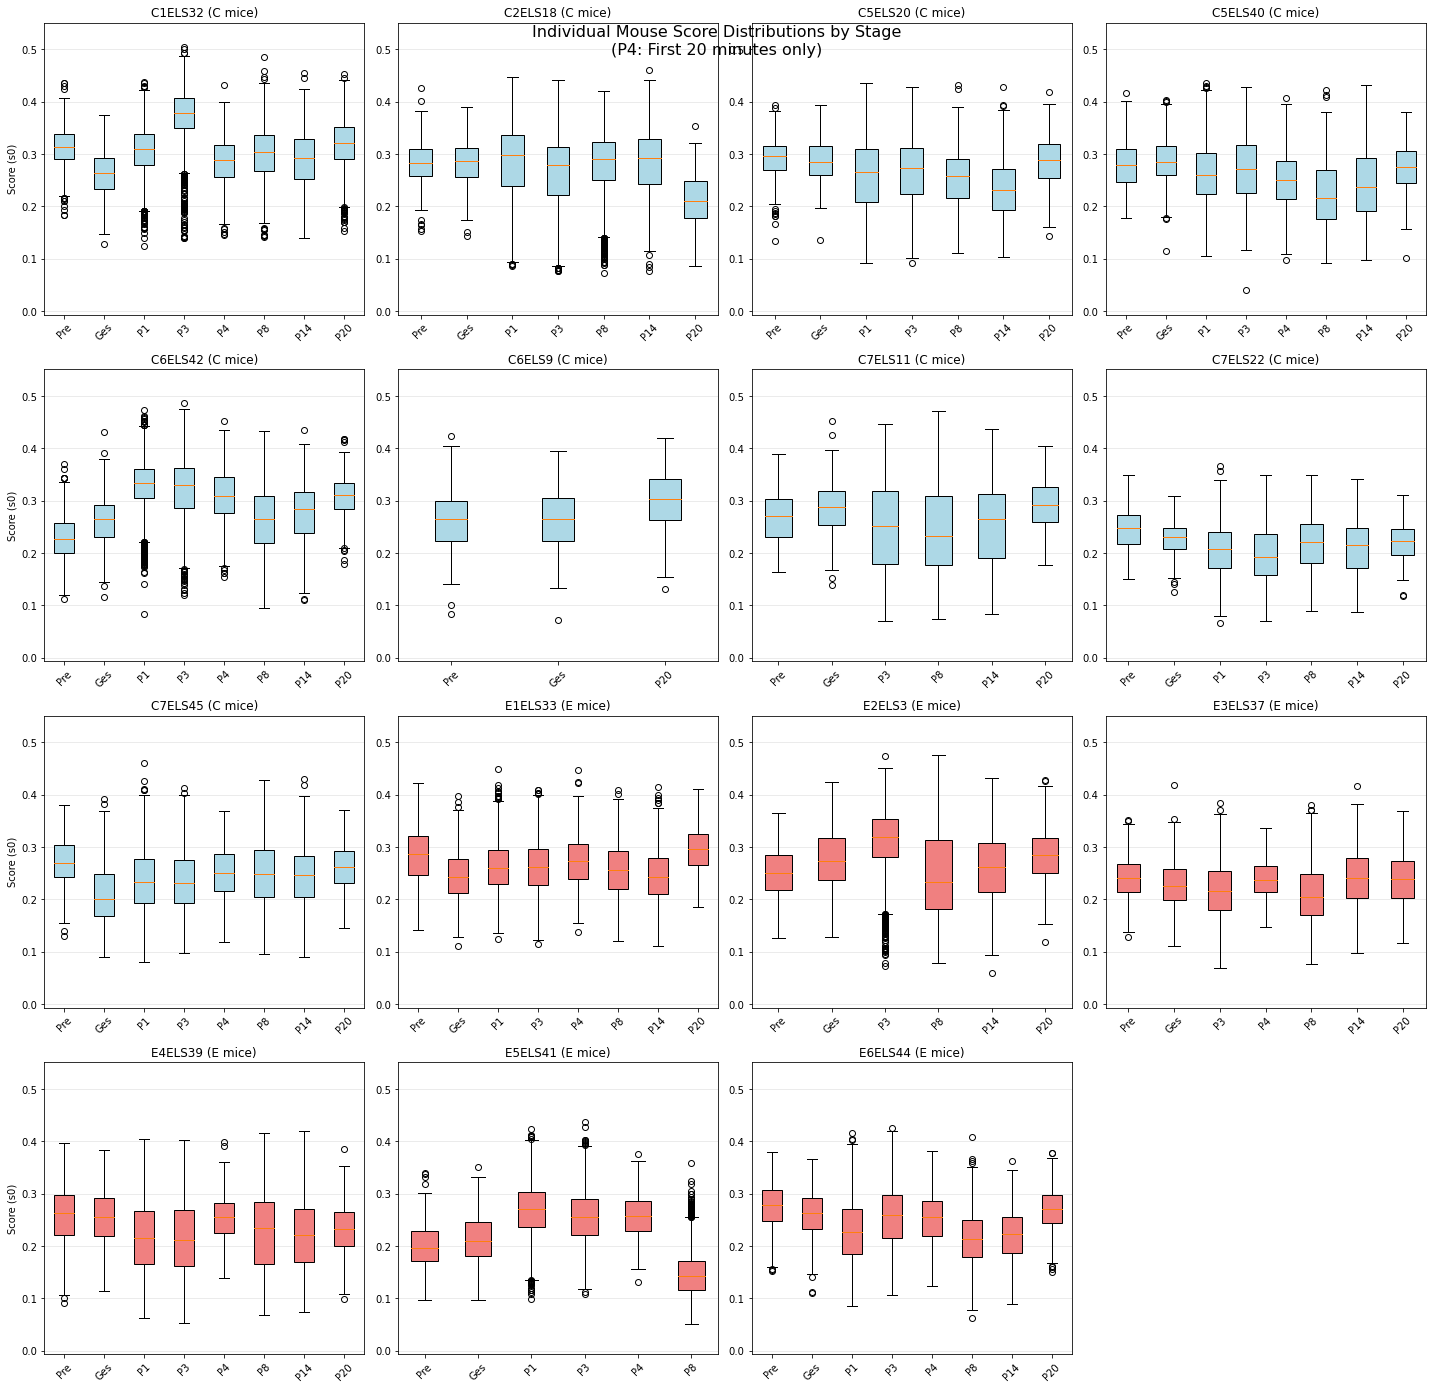

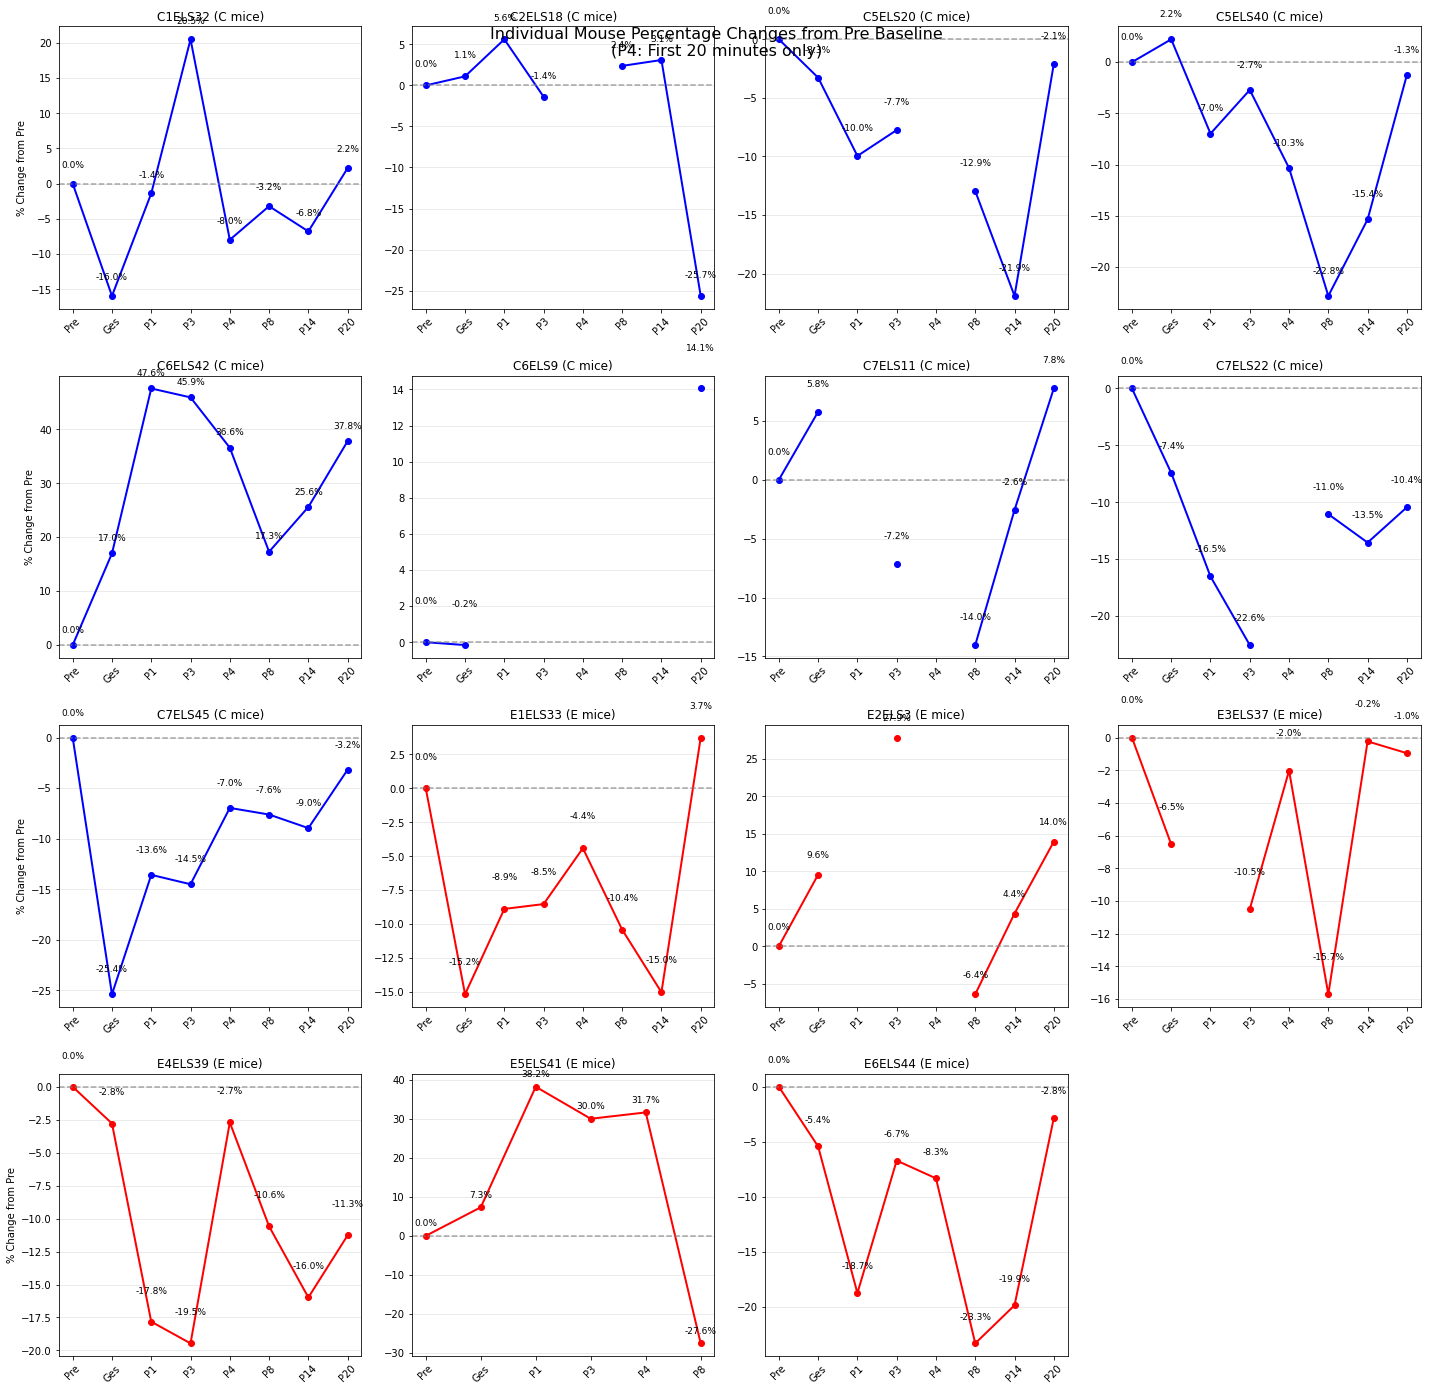

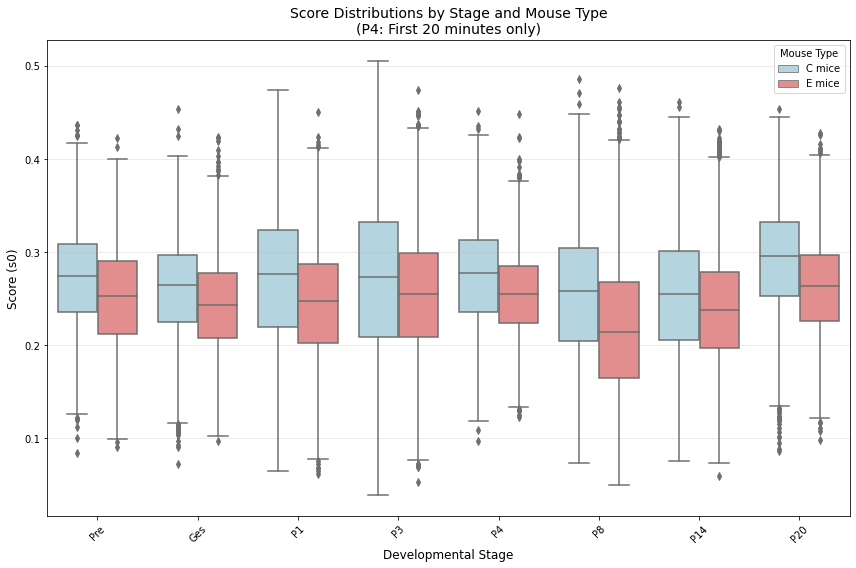

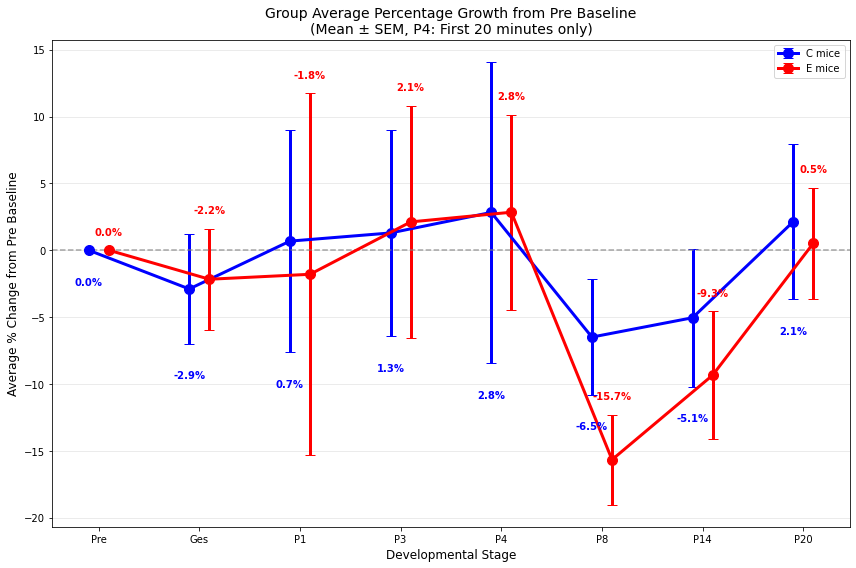

(<Figure size 1440x1440 with 16 Axes>,
 <Figure size 1440x1440 with 16 Axes>,
 <Figure size 864x576 with 1 Axes>,
 <Figure size 864x576 with 1 Axes>,
    Mouse_ID    Type  Pre_median  Pre_mean  Pre_std  Pre_n  Ges_median  \
 0   C1ELS32  C mice      0.3144    0.3135   0.0407    404      0.2643   
 1   C2ELS18  C mice      0.2832    0.2842   0.0462    208      0.2864   
 2   C5ELS20  C mice      0.2955    0.2920   0.0418    213      0.2859   
 3   C5ELS40  C mice      0.2795    0.2807   0.0452    402      0.2857   
 4   C6ELS42  C mice      0.2259    0.2289   0.0467    410      0.2643   
 5    C6ELS9  C mice      0.2652    0.2606   0.0585    203      0.2648   
 6   C7ELS11  C mice      0.2715    0.2672   0.0485    204      0.2872   
 7   C7ELS22  C mice      0.2485    0.2436   0.0394    210      0.2300   
 8   C7ELS45  C mice      0.2700    0.2713   0.0461    403      0.2015   
 9   E1ELS33  E mice      0.2865    0.2836   0.0516    402      0.2430   
 10   E2ELS3  E mice      0.2504    

In [53]:
combined_df = pd.DataFrame({
    'mouse_id': cleaned_mouse_ids,
    'period': train_dict['period'],
    's0': scores[:, 0],
    'mouse_type': [assign_mouse_type(mid) for mid in cleaned_mouse_ids]
})

# Apply stage categorization
combined_df['stage'] = combined_df['period'].apply(categorize_period_six_groups)

# Step 1: Filter your data
filtered_df, selected_mice = filter_target_mice_with_3plus_stages(combined_df, c_mice_ids, e_mice_ids, 3)
# Step 2: Create visualizations
order = ['Pre', 'Ges', 'P1', 'P3', 'P4', 'P8', 'P14', 'P20']
create_four_visualizations_with_tables(filtered_df, selected_mice, order)

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from math import comb

def exact_permutation_test_hl(c_vec, e_vec, observed_hl, n_max=100000):
    """
    Exact permutation test for Hodges-Lehmann statistic.
    
    Parameters:
    -----------
    c_vec : array-like
        C group values
    e_vec : array-like
        E group values
    observed_hl : float
        Observed HL statistic (median of all pairwise differences C - E)
    n_max : int
        Maximum number of permutations to compute (for safety)
    
    Returns:
    --------
    p_value : float
        Two-sided p-value
    n_perms : int
        Total number of permutations computed
    """
    c_vec = np.array(c_vec, dtype=float)
    e_vec = np.array(e_vec, dtype=float)
    
    n_c = len(c_vec)
    n_e = len(e_vec)
    n_total = n_c + n_e
    
    # Combined data
    combined = np.concatenate([c_vec, e_vec])
    
    # Total number of ways to choose n_c items from n_total
    total_perms = comb(n_total, n_c)
    
    print(f"    Total possible permutations: {total_perms}")
    
    if total_perms > n_max:
        print(f"    Warning: {total_perms} permutations exceed limit {n_max}")
        print(f"    Consider using approximate permutation test instead")
        return np.nan, total_perms
    
    # Generate all combinations
    count_extreme = 0
    abs_observed = abs(observed_hl)
    
    # Enumerate all ways to split into groups of size n_c and n_e
    for c_indices in combinations(range(n_total), n_c):
        # Indices for permuted C group
        c_indices_set = set(c_indices)
        e_indices = [i for i in range(n_total) if i not in c_indices_set]
        
        perm_c = combined[list(c_indices)]
        perm_e = combined[e_indices]
        
        # Calculate HL for this permutation
        perm_hl = np.median(perm_c[:, None] - perm_e[None, :])
        
        # Two-sided test: count if |perm_hl| >= |observed_hl|
        if abs(perm_hl) >= abs_observed:
            count_extreme += 1
    
    p_value = count_extreme / total_perms
    
    return p_value, total_perms


def exact_permutation_test_median_diff(c_vec, e_vec, observed_diff, n_max=100000):
    """
    Exact permutation test for difference of medians (C_median - E_median).
    
    Parameters:
    -----------
    c_vec : array-like
        C group values
    e_vec : array-like
        E group values
    observed_diff : float
        Observed difference (median_C - median_E)
    n_max : int
        Maximum number of permutations to compute
    
    Returns:
    --------
    p_value : float
        Two-sided p-value
    n_perms : int
        Total number of permutations computed
    """
    c_vec = np.array(c_vec, dtype=float)
    e_vec = np.array(e_vec, dtype=float)
    
    n_c = len(c_vec)
    n_e = len(e_vec)
    n_total = n_c + n_e
    
    # Combined data
    combined = np.concatenate([c_vec, e_vec])
    
    # Total number of permutations
    total_perms = comb(n_total, n_c)
    
    print(f"    Total possible permutations: {total_perms}")
    
    if total_perms > n_max:
        print(f"    Warning: {total_perms} permutations exceed limit {n_max}")
        print(f"    Consider using approximate permutation test instead")
        return np.nan, total_perms
    
    # Generate all combinations
    count_extreme = 0
    abs_observed = abs(observed_diff)
    
    for c_indices in combinations(range(n_total), n_c):
        c_indices_set = set(c_indices)
        e_indices = [i for i in range(n_total) if i not in c_indices_set]
        
        perm_c = combined[list(c_indices)]
        perm_e = combined[e_indices]
        
        # Calculate median difference for this permutation
        perm_diff = np.median(perm_c) - np.median(perm_e)
        
        # Two-sided test
        if abs(perm_diff) >= abs_observed:
            count_extreme += 1
    
    p_value = count_extreme / total_perms
    
    return p_value, total_perms


def fisher_combine_pvalues(p_values, method_name=""):
    """
    Fisher's method for combining p-values.
    
    Parameters:
    -----------
    p_values : array-like
        List of p-values to combine (must be independent tests)
    method_name : str
        Name of the statistical method (for display)
    
    Returns:
    --------
    combined_p : float
        Combined p-value
    chi2_stat : float
        Fisher's chi-square statistic
    df : int
        Degrees of freedom (2k)
    k : int
        Number of valid p-values used
    """
    # Filter out NaN and invalid p-values
    p_values = np.array(p_values)
    valid_mask = ~np.isnan(p_values) & (p_values > 0) & (p_values <= 1)
    valid_p = p_values[valid_mask]
    
    k = len(valid_p)
    
    if k == 0:
        print(f"  [{method_name}] No valid p-values to combine")
        return np.nan, np.nan, 0, 0
    
    # Fisher's chi-square statistic: -2 * sum(ln(p_i))
    chi2_stat = -2 * np.sum(np.log(valid_p))
    
    # Degrees of freedom = 2k
    df = 2 * k
    
    # Combined p-value from chi-square distribution
    combined_p = 1 - stats.chi2.cdf(chi2_stat, df)
    
    print(f"  [{method_name}] Fisher's method:")
    print(f"    - Number of stages combined: {k}")
    print(f"    - Individual p-values: {valid_p}")
    print(f"    - Chi-square statistic: {chi2_stat:.4f}")
    print(f"    - Degrees of freedom: {df}")
    print(f"    - Combined p-value: {combined_p:.6f}")
    
    return combined_p, chi2_stat, df, k


def create_four_visualizations_with_tables(filtered_df, selected_mice, order, c_mice_ids, e_mice_ids):
    """
    Revised: no individual plots. Make a single group plot using median + IQR (Q1–Q3)
    on percentage changes from Pre, and compute per-stage HL median difference and
    Wilcoxon rank-sum test (C vs E). 
    
    NEW: Added exact permutation tests for HL statistic and median difference.
    NEW: Added Fisher's method to combine p-values across all stages (except Pre).
    NEW: Filter P4 data to first 20 minutes (400 windows) per mouse.
    Save tidy tables as CSV.
    """
    
    # ================================================================
    # DATA FILTERING: Keep only first 20 minutes of P4 recordings
    # ================================================================
    print("\n" + "="*80)
    print("DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY")
    print("="*80)
    
    filtered_df = filtered_df.copy()
    
    # Process P4 data for each mouse
    p4_filtering_stats = []
    rows_to_drop = []
    
    for mouse_id in selected_mice:
        # Get P4 data for this mouse
        p4_mask = (filtered_df['mouse_id'] == mouse_id) & (filtered_df['stage'] == 'P4')
        p4_indices = filtered_df[p4_mask].index
        
        if len(p4_indices) > 0:
            original_count = len(p4_indices)
            
            # Keep only first 400 windows (20 minutes * 60 seconds / 3 seconds per window)
            max_windows = 400
            
            if original_count > max_windows:
                # Mark indices to drop (everything after first 400 windows)
                indices_to_drop = p4_indices[max_windows:]
                rows_to_drop.extend(indices_to_drop.tolist())
                kept_count = max_windows
            else:
                kept_count = original_count
            
            removed_count = original_count - kept_count
            
            p4_filtering_stats.append({
                'Mouse_ID': mouse_id,
                'Original_Windows': original_count,
                'Kept_Windows': kept_count,
                'Removed_Windows': removed_count,
                'Total_Minutes': original_count * 3 / 60,
                'Kept_Minutes': kept_count * 3 / 60
            })
    
    # Drop the rows
    if rows_to_drop:
        print(f"\nRemoving {len(rows_to_drop)} time windows from P4 data...")
        filtered_df = filtered_df.drop(rows_to_drop)
        print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    if p4_filtering_stats:
        p4_stats_df = pd.DataFrame(p4_filtering_stats)
        print("\nP4 Data Filtering Summary:")
        print(p4_stats_df.to_string(index=False))
        print(f"\nTotal windows removed from P4: {p4_stats_df['Removed_Windows'].sum()}")
    else:
        print("\nNo P4 data found for selected mice.")
    
    # Verify P4 filtering worked
    print("\nVerifying P4 data after filtering:")
    for mouse_id in selected_mice:
        p4_count = len(filtered_df[(filtered_df['mouse_id'] == mouse_id) & 
                                   (filtered_df['stage'] == 'P4')])
        if p4_count > 0:
            print(f"  {mouse_id}: {p4_count} P4 windows ({p4_count * 3 / 60:.1f} minutes)")
    
    print("\n" + "="*80)
    print("PROCEEDING WITH FILTERED DATA")
    print("="*80)
    
    # --- split mice by type
    c_mice_selected = [m for m in selected_mice if m in c_mice_ids]
    e_mice_selected = [m for m in selected_mice if m in e_mice_ids]

    print(f"\nSelected mice for analysis:")
    print(f"C mice ({len(c_mice_selected)}): {c_mice_selected}")
    print(f"E mice ({len(e_mice_selected)}): {e_mice_selected}")

    # ================================================================
    # TABLE 1: Individual Mouse Median Scores by Stage (computed but not printed)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 1: INDIVIDUAL MOUSE MEDIAN SCORES BY STAGE")
    print("="*80)
    print("(Computed and saved to CSV, not displayed here)")
    print("Note: P4 data limited to first 20 minutes per mouse")

    individual_scores_data = []
    for mouse_id in selected_mice:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        if mouse_data.empty:
            continue
        mouse_type = mouse_data['mouse_type'].iloc[0]
        row = {'Mouse_ID': mouse_id, 'Type': mouse_type}
        for stage in order:
            vals = mouse_data.loc[mouse_data['stage'] == stage, 's0']
            row[f'{stage}_median'] = vals.median() if len(vals) else np.nan
            row[f'{stage}_mean']   = vals.mean()   if len(vals) else np.nan
            row[f'{stage}_std']    = vals.std()    if len(vals) else np.nan
            row[f'{stage}_n']      = len(vals)
        individual_scores_data.append(row)
    individual_scores_df = pd.DataFrame(individual_scores_data)

    # ================================================================
    # TABLE 2: INDIVIDUAL MOUSE % CHANGES FROM PRE
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 2: INDIVIDUAL MOUSE % CHANGES FROM PRE BASELINE")
    print("="*80)
    print("(Computed and saved to CSV, not displayed here)")

    mouse_pct_changes = {}
    pct_change_rows = []
    for mouse_id in selected_mice:
        md = filtered_df[filtered_df['mouse_id'] == mouse_id]
        if md.empty:
            continue
        mtype = md['mouse_type'].iloc[0]
        pre_vals = md.loc[md['stage']=='Pre','s0']
        if len(pre_vals)==0 or np.isnan(pre_vals.median()):
            continue
        pre_med = pre_vals.median()
        row = {'Mouse_ID': mouse_id, 'Type': mtype, 'Pre_baseline': pre_med}
        per_mouse = {}
        for stage in order:
            if stage=='Pre':
                per_mouse[stage] = 0.0
                row[stage] = 0.0
                continue
            vals = md.loc[md['stage']==stage, 's0']
            if len(vals):
                st_med = vals.median()
                pct = ((st_med - pre_med) / abs(pre_med)) * 100.0
            else:
                pct = np.nan
            per_mouse[stage] = pct
            row[stage] = pct
        mouse_pct_changes[mouse_id] = per_mouse
        pct_change_rows.append(row)
    pct_change_df = pd.DataFrame(pct_change_rows)

    # ================================================================
    # TABLE 3: GROUP-LEVEL SUMMARY ON % CHANGES (median, IQR, MAD)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 3: GROUP-LEVEL % CHANGE SUMMARY (median, IQR, MAD)")
    print("="*80)

    def group_stage_vector(group_mice, stage):
        out = []
        for m in group_mice:
            if m in mouse_pct_changes and stage in mouse_pct_changes[m]:
                v = mouse_pct_changes[m][stage]
                if not np.isnan(v):
                    out.append(float(v))
        return np.array(out, dtype=float)

    group_summary_rows = []
    for gname, g_mice in [('C mice', c_mice_selected), ('E mice', e_mice_selected)]:
        row = {'Group': gname}
        for stage in order:
            if stage=='Pre':
                vec = np.zeros(len(g_mice), dtype=float)
            else:
                vec = group_stage_vector(g_mice, stage)
            if vec.size>0:
                med = np.median(vec)
                q1  = np.percentile(vec, 25)
                q3  = np.percentile(vec, 75)
                iqr = q3 - q1
                mad = 1.4826 * np.median(np.abs(vec - med))
                n   = vec.size
            else:
                med=q1=q3=iqr=mad=np.nan; n=0
            row[f'{stage}_median'] = med
            row[f'{stage}_q1']     = q1
            row[f'{stage}_q3']     = q3
            row[f'{stage}_iqr']    = iqr
            row[f'{stage}_mad']    = mad
            row[f'{stage}_n']      = n
        group_summary_rows.append(row)
    group_pct_summary_df = pd.DataFrame(group_summary_rows)
    
    # Pretty print some key columns
    for _, r in group_pct_summary_df.iterrows():
        print(f"\n{r['Group']}:")
        for stage in order:
            med = r[f'{stage}_median']; q1=r[f'{stage}_q1']; q3=r[f'{stage}_q3']; n=int(r[f'{stage}_n'])
            if np.isnan(med):
                print(f"  {stage:12s}: No data")
            else:
                stage_note = " (first 20 min)" if stage == 'P4' else ""
                print(f"  {stage:12s}: median={med:6.2f}%  IQR=[{q1:6.2f}%, {q3:6.2f}%] (n={n}){stage_note}")

    # ================================================================
    # TABLE 4: PER-STAGE WILCOXON + HL + PERMUTATION TESTS (C−E) ON % CHANGES
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 4: PER-STAGE C vs E — Wilcoxon, HL, and Exact Permutation Tests (% scale)")
    print("="*80)

    stat_rows = []
    
    # Lists to collect p-values for Fisher's method (excluding Pre)
    wilcoxon_pvalues = []
    hl_perm_pvalues = []
    median_perm_pvalues = []
    
    for stage in order:
        if stage=='Pre':
            stat_rows.append({
                'Stage': stage,
                'C_n': len(c_mice_selected),
                'E_n': len(e_mice_selected),
                'C_median': 0.0,
                'C_q1': 0.0,
                'C_q3': 0.0,
                'E_median': 0.0,
                'E_q1': 0.0,
                'E_q3': 0.0,
                'U': np.nan, 
                'Wilcoxon_p_value': np.nan,
                'HL_diff_pct': 0.0,
                'perm_p_HL': np.nan,
                'median_diff_pct': 0.0,
                'perm_p_median': np.nan,
                'n_perms': np.nan
            })
            continue

        c_vec = group_stage_vector(c_mice_selected, stage)
        e_vec = group_stage_vector(e_mice_selected, stage)

        if c_vec.size>0 and e_vec.size>0:
            # Wilcoxon rank-sum (two-sided, exact method for small samples)
            U, p = stats.mannwhitneyu(c_vec, e_vec, alternative='two-sided', method='exact')
            
            # HL median difference: median over all pairwise (c - e)
            HL = np.median(c_vec[:, None] - e_vec[None, :])
            
            # Median difference (simple)
            median_diff = np.median(c_vec) - np.median(e_vec)
            
            # Exact permutation test for HL statistic
            stage_note = " (first 20 min)" if stage == 'P4' else ""
            print(f"\n  Computing exact permutation test for HL statistic at stage {stage}{stage_note}...")
            perm_p_hl, n_perms = exact_permutation_test_hl(c_vec, e_vec, HL)
            
            # Exact permutation test for median difference
            print(f"  Computing exact permutation test for median difference at stage {stage}{stage_note}...")
            perm_p_median, _ = exact_permutation_test_median_diff(c_vec, e_vec, median_diff)

            # Collect p-values for Fisher's method
            wilcoxon_pvalues.append(float(p))
            hl_perm_pvalues.append(float(perm_p_hl) if not np.isnan(perm_p_hl) else np.nan)
            median_perm_pvalues.append(float(perm_p_median) if not np.isnan(perm_p_median) else np.nan)

            stat_rows.append({
                'Stage': stage,
                'C_n': c_vec.size,
                'C_median': np.median(c_vec),
                'C_q1': np.percentile(c_vec,25),
                'C_q3': np.percentile(c_vec,75),
                'E_n': e_vec.size,
                'E_median': np.median(e_vec),
                'E_q1': np.percentile(e_vec,25),
                'E_q3': np.percentile(e_vec,75),
                'U': float(U),
                'Wilcoxon_p_value': float(p),
                'HL_diff_pct': float(HL),
                'perm_p_HL': float(perm_p_hl) if not np.isnan(perm_p_hl) else np.nan,
                'median_diff_pct': float(median_diff),
                'perm_p_median': float(perm_p_median) if not np.isnan(perm_p_median) else np.nan,
                'n_perms': n_perms
            })
        else:
            stat_rows.append({
                'Stage': stage,
                'C_n': c_vec.size if isinstance(c_vec, np.ndarray) else 0,
                'E_n': e_vec.size if isinstance(e_vec, np.ndarray) else 0,
                'C_median': np.nan,
                'C_q1': np.nan,
                'C_q3': np.nan,
                'E_median': np.nan,
                'E_q1': np.nan,
                'E_q3': np.nan,
                'U': np.nan, 
                'Wilcoxon_p_value': np.nan,
                'HL_diff_pct': np.nan,
                'perm_p_HL': np.nan,
                'median_diff_pct': np.nan,
                'perm_p_median': np.nan,
                'n_perms': 0
            })
            
            # Add NaN to p-value lists for stages with no data
            wilcoxon_pvalues.append(np.nan)
            hl_perm_pvalues.append(np.nan)
            median_perm_pvalues.append(np.nan)

    statistical_tests_df = pd.DataFrame(stat_rows)

    # Display concise per-stage line
    print("\n" + "="*80)
    print("Statistical Test Results (percent change from Pre):")
    print("="*80)
    for _, row in statistical_tests_df.iterrows():
        st = row['Stage']
        if st=='Pre':
            print(f"\n{st:12s}: Baseline (no comparison)")
            continue
        if not np.isnan(row['Wilcoxon_p_value']):
            stage_note = " (first 20 min)" if st == 'P4' else ""
            print(f"\n{st:12s}{stage_note}:")
            print(f"  C group: n={int(row['C_n'])}, median={row['C_median']:6.2f}%, IQR=[{row['C_q1']:6.2f}%, {row['C_q3']:6.2f}%]")
            print(f"  E group: n={int(row['E_n'])}, median={row['E_median']:6.2f}%, IQR=[{row['E_q1']:6.2f}%, {row['E_q3']:6.2f}%]")
            print(f"  ---")
            print(f"  Wilcoxon U={row['U']:.1f}, p={row['Wilcoxon_p_value']:.4f}")
            print(f"  HL difference (C-E) = {row['HL_diff_pct']:6.2f}%")
            if not np.isnan(row['perm_p_HL']):
                print(f"    → Exact perm test (HL): p={row['perm_p_HL']:.4f}")
            print(f"  Median difference (C-E) = {row['median_diff_pct']:6.2f}%")
            if not np.isnan(row['perm_p_median']):
                print(f"    → Exact perm test (median): p={row['perm_p_median']:.4f}")
            if not np.isnan(row['n_perms']):
                print(f"  Total permutations: {int(row['n_perms'])}")
        else:
            print(f"\n{st:12s}: Insufficient data")

    print("\n" + "="*80)

    # ================================================================
    # TABLE 5: FISHER'S COMBINED P-VALUES (ALL STAGES EXCEPT PRE)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 5: FISHER'S METHOD - COMBINED P-VALUES ACROSS ALL STAGES (EXCEPT PRE)")
    print("Note: P4 data limited to first 20 minutes per mouse")
    print("="*80)
    
    # Apply Fisher's method to each type of test
    print("\n1. Wilcoxon Rank-Sum Test:")
    wilcoxon_combined_p, wilcoxon_chi2, wilcoxon_df, wilcoxon_k = fisher_combine_pvalues(
        wilcoxon_pvalues, method_name="Wilcoxon"
    )
    
    print("\n2. Hodges-Lehmann Permutation Test:")
    hl_combined_p, hl_chi2, hl_df, hl_k = fisher_combine_pvalues(
        hl_perm_pvalues, method_name="HL Permutation"
    )
    
    print("\n3. Median Difference Permutation Test:")
    median_combined_p, median_chi2, median_df, median_k = fisher_combine_pvalues(
        median_perm_pvalues, method_name="Median Permutation"
    )
    
    # Create Fisher's combined table
    fisher_results = {
        'Test_Method': ['Wilcoxon Rank-Sum', 'HL Permutation', 'Median Permutation'],
        'N_Stages_Combined': [wilcoxon_k, hl_k, median_k],
        'Chi2_Statistic': [wilcoxon_chi2, hl_chi2, median_chi2],
        'Degrees_of_Freedom': [wilcoxon_df, hl_df, median_df],
        'Combined_P_Value': [wilcoxon_combined_p, hl_combined_p, median_combined_p]
    }
    fisher_combined_df = pd.DataFrame(fisher_results)
    
    print("\n" + "="*80)
    print("FISHER'S COMBINED P-VALUES SUMMARY:")
    print("="*80)
    print(fisher_combined_df.to_string(index=False, float_format='%.6f'))
    print("\n" + "="*80)
    
    # Interpretation
    print("\nINTERPRETATION:")
    print("-" * 80)
    for _, row in fisher_combined_df.iterrows():
        method = row['Test_Method']
        p = row['Combined_P_Value']
        if np.isnan(p):
            print(f"{method:25s}: No valid p-values to combine")
        elif p < 0.001:
            print(f"{method:25s}: p={p:.6f} (***) - HIGHLY SIGNIFICANT")
        elif p < 0.01:
            print(f"{method:25s}: p={p:.6f} (**) - VERY SIGNIFICANT")
        elif p < 0.05:
            print(f"{method:25s}: p={p:.6f} (*) - SIGNIFICANT")
        else:
            print(f"{method:25s}: p={p:.6f} (ns) - Not significant")
    print("-" * 80)

    # ================================================================
    # GROUP PLOT: median (point) + IQR (error bar) on % changes
    # ================================================================
    # Prepare series for plotting
    c_medians = []; c_q1 = []; c_q3 = []
    e_medians = []; e_q1 = []; e_q3 = []
    for stage in order:
        if stage=='Pre':
            c_medians.append(0.0); c_q1.append(0.0); c_q3.append(0.0)
            e_medians.append(0.0); e_q1.append(0.0); e_q3.append(0.0)
        else:
            c_medians.append(group_pct_summary_df.loc[group_pct_summary_df['Group']=='C mice', f'{stage}_median'].values[0])
            c_q1.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='C mice', f'{stage}_q1'].values[0])
            c_q3.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='C mice', f'{stage}_q3'].values[0])
            e_medians.append(group_pct_summary_df.loc[group_pct_summary_df['Group']=='E mice', f'{stage}_median'].values[0])
            e_q1.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='E mice', f'{stage}_q1'].values[0])
            e_q3.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='E mice', f'{stage}_q3'].values[0])

    x = np.arange(len(order))
    offset = 0.08
    fig, ax = plt.subplots(figsize=(12, 7))

    def plot_median_IQR(x_pos, med, q1, q3, label, color):
        med = np.array(med, dtype=float)
        q1  = np.array(q1, dtype=float)
        q3  = np.array(q3, dtype=float)
        yerr = np.vstack([np.maximum(0, med - q1), np.maximum(0, q3 - med)])
        ax.errorbar(x_pos, med, yerr=yerr, fmt='o-', linewidth=2.5, markersize=8, 
                   capsize=6, label=label, color=color)

    plot_median_IQR(x - offset, c_medians, c_q1, c_q3, 'C mice (median ± IQR)', 'blue')
    plot_median_IQR(x + offset, e_medians, e_q1, e_q3, 'E mice (median ± IQR)', 'red')

    ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=0)
    ax.set_ylabel('% Change from Pre (median ± IQR)')
    ax.set_title('Group % Change from Pre — Median with IQR (per mouse)\n(P4: First 20 minutes only)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

    # annotate medians
    for i, (cm, em, cq3_val, eq1_val) in enumerate(zip(c_medians, e_medians, c_q3, e_q1)):
        if not np.isnan(cm):
            ax.text(i - offset, cq3_val + 2, f'{cm:.0f}%', va='bottom', ha='center', 
                   fontsize=9, color='blue', weight='bold')
        if not np.isnan(em):
            ax.text(i + offset, eq1_val - 2, f'{em:.0f}%', va='top', ha='center', 
                   fontsize=9, color='red', weight='bold')

    plt.tight_layout()
    plt.show()

    # ================================================================
    # SAVE TABLES
    # ================================================================
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE - All tables generated")
    print("P4 data limited to first 20 minutes (400 time windows) per mouse")
    print("="*80)
    
    return (fig, individual_scores_df, pct_change_df,
            group_pct_summary_df, statistical_tests_df, fisher_combined_df)


DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY

Removing 4108 time windows from P4 data...
Filtered dataframe shape: (185015, 5)

P4 Data Filtering Summary:
Mouse_ID  Original_Windows  Kept_Windows  Removed_Windows  Total_Minutes  Kept_Minutes
 C1ELS32               759           400              359        37.9500       20.0000
 C5ELS40               600           400              200        30.0000       20.0000
 C6ELS42               765           400              365        38.2500       20.0000
 C7ELS45               819           400              419        40.9500       20.0000
 E1ELS33               756           400              356        37.8000       20.0000
 E3ELS37               893           400              493        44.6500       20.0000
 E4ELS39               795           400              395        39.7500       20.0000
 E5ELS41              1652           400             1252        82.6000       20.0000
 E6ELS44               669           400              269

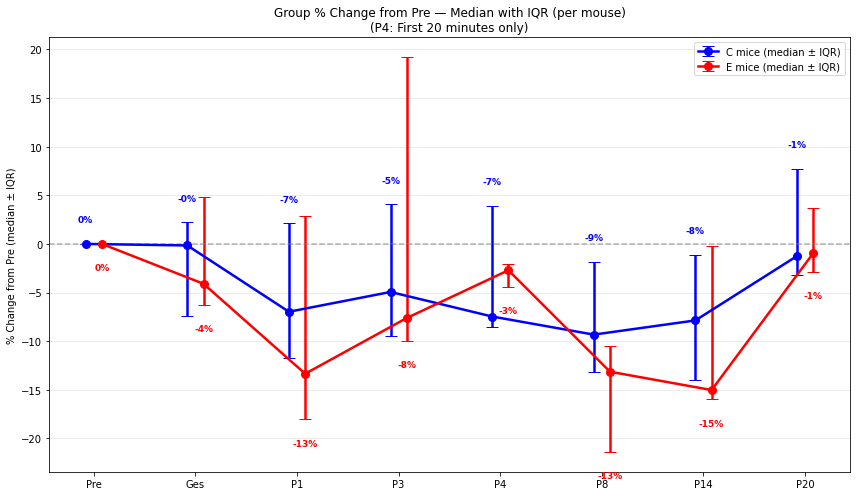


ANALYSIS COMPLETE - All tables generated
P4 data limited to first 20 minutes (400 time windows) per mouse


(<Figure size 864x504 with 1 Axes>,
    Mouse_ID    Type  Pre_median  Pre_mean  Pre_std  Pre_n  Ges_median  \
 0    C6ELS9  C mice      0.2652    0.2606   0.0585    203      0.2648   
 1   C7ELS11  C mice      0.2715    0.2672   0.0485    204      0.2872   
 2   C2ELS18  C mice      0.2832    0.2842   0.0462    208      0.2864   
 3   C5ELS20  C mice      0.2955    0.2920   0.0418    213      0.2859   
 4   C7ELS22  C mice      0.2485    0.2436   0.0394    210      0.2300   
 5   C1ELS32  C mice      0.3144    0.3135   0.0407    404      0.2643   
 6   C5ELS40  C mice      0.2795    0.2807   0.0452    402      0.2857   
 7   C6ELS42  C mice      0.2259    0.2289   0.0467    410      0.2643   
 8   C7ELS45  C mice      0.2700    0.2713   0.0461    403      0.2015   
 9    E2ELS3  E mice      0.2504    0.2507   0.0484    267      0.2743   
 10  E1ELS33  E mice      0.2865    0.2836   0.0516    402      0.2430   
 11  E3ELS37  E mice      0.2420    0.2429   0.0378    402      0.2262   
 1

In [45]:
create_four_visualizations_with_tables(
    filtered_df=filtered_df,
    selected_mice=c_mice_ids + e_mice_ids,
    order=order,
    c_mice_ids=c_mice_ids,
    e_mice_ids=e_mice_ids
)

# Backproject on Pup-retrivial

In [46]:
MODEL_SAVE_FILE = "Maternal_model_lick_Onnest_C_only_Dec19_v1.pt"


All unique mice in data: ['C1ELS32' 'C3ELS36' 'C5ELS40' 'C6ELS42' 'C7ELS45' 'E1ELS33' 'E3ELS37'
 'E4ELS39' 'E5ELS41' 'E6ELS44']
Total number of mice in file: 10

TARGET ANIMALS (intersection with file)
C group target mice: ['C6ELS9', 'C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
C group in data: ['C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45'] (n=4)

E group target mice: ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']
E group in data: ['E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44'] (n=5)

Total target mice to analyze: 9

Unique periods in data: ['P4 home']
  P4 home: 8263 samples

Unique pup_retrieval_detail labels in data: [0 1 3 4]
  0 (no trial): 6211 samples
  1 (trial no retrieval): 1901 samples
  3 (partial retrieval): 19 samples
  4 (successful retrieval): 132 samples

CREATING DATASETS

C MICE - P4 home

⚠️  IMPORTANT: Assuming data is already time-ordered within each mouse!
   If not, the time series plots will b

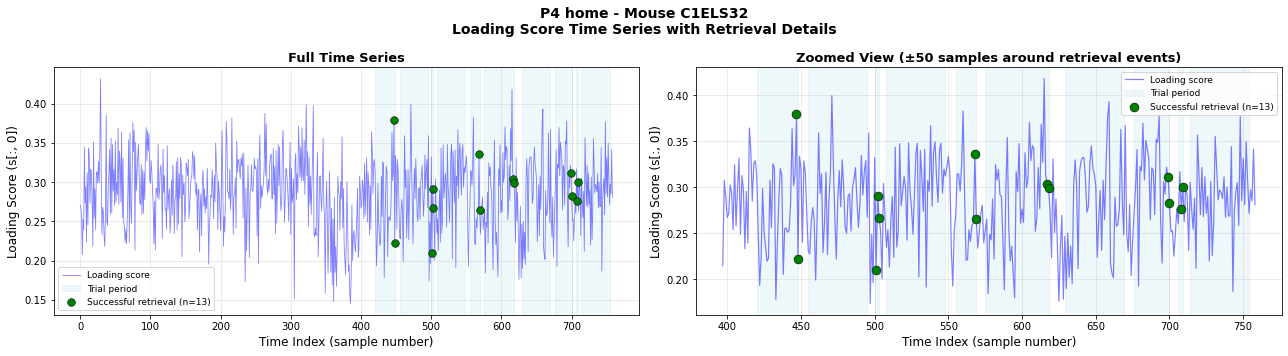

  ✓ Displayed plot for Mouse C1ELS32
  Mouse C5ELS40: 600 samples total
    - no trial (0): 519 samples
    - trial no retrieval (1): 61 samples
    - successful retrieval (4): 20 samples


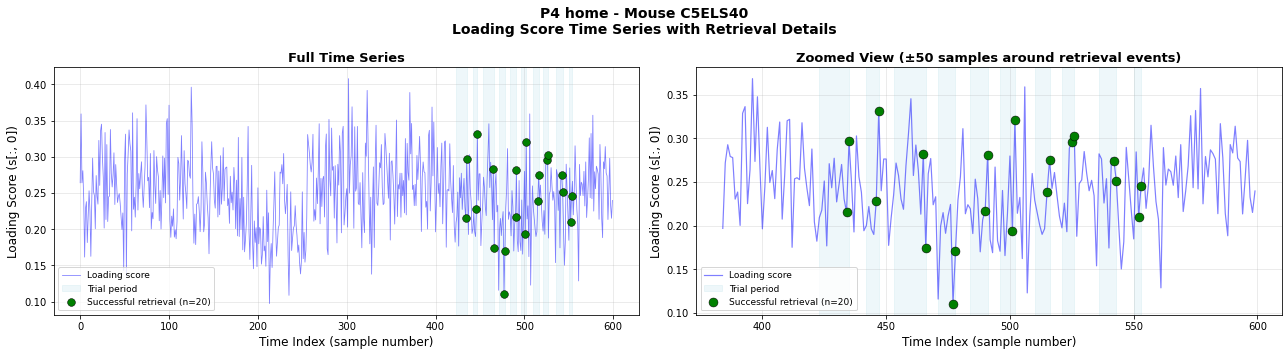

  ✓ Displayed plot for Mouse C5ELS40
  Mouse C6ELS42: 765 samples total
    - no trial (0): 557 samples
    - trial no retrieval (1): 192 samples
    - partial retrieval (3): 1 samples
    - successful retrieval (4): 15 samples


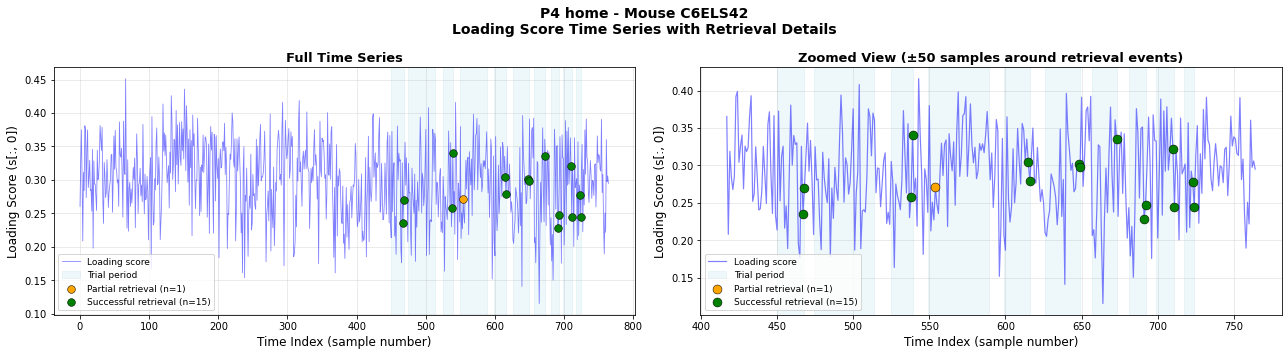

  ✓ Displayed plot for Mouse C6ELS42
  Mouse C7ELS45: 819 samples total
    - no trial (0): 750 samples
    - trial no retrieval (1): 45 samples
    - partial retrieval (3): 6 samples
    - successful retrieval (4): 18 samples


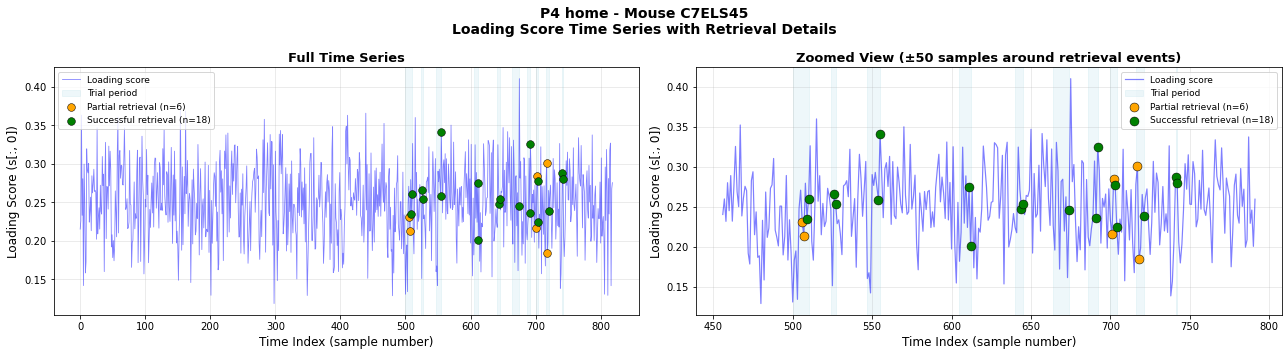

  ✓ Displayed plot for Mouse C7ELS45

Plotting: E - P4 home

PLOTTING: P4 home
s_scores shape: (4765, 10)
Using ONLY first loading dimension: s[:, 0]
⚠️  Assuming samples are in TIME ORDER within each mouse!
  Mouse E1ELS33: 756 samples total
    - no trial (0): 513 samples
    - trial no retrieval (1): 231 samples
    - successful retrieval (4): 12 samples


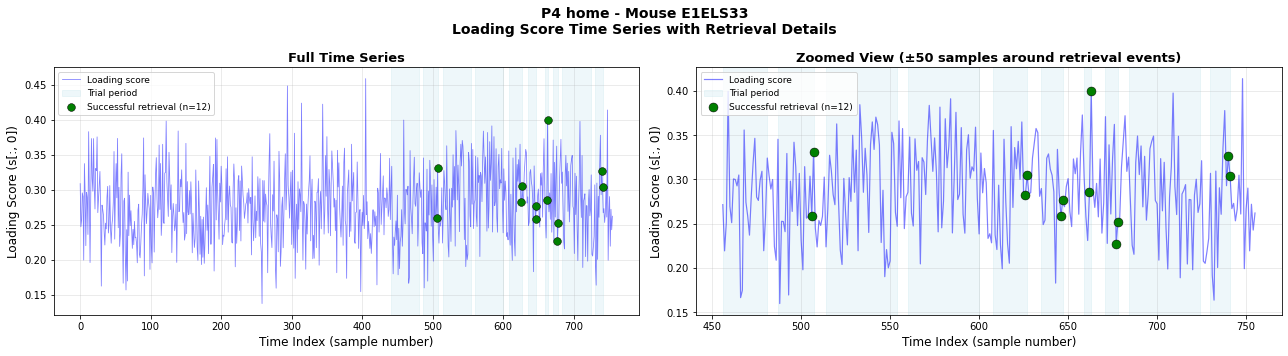

  ✓ Displayed plot for Mouse E1ELS33
  Skipping E3ELS37: no label=1 samples
  Mouse E4ELS39: 795 samples total
    - no trial (0): 556 samples
    - trial no retrieval (1): 222 samples
    - partial retrieval (3): 6 samples
    - successful retrieval (4): 11 samples


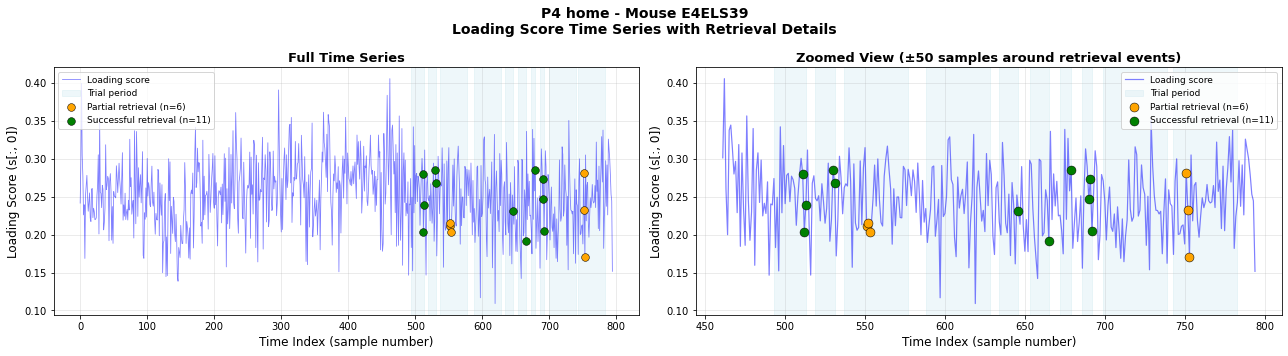

  ✓ Displayed plot for Mouse E4ELS39
  Mouse E5ELS41: 1652 samples total
    - no trial (0): 1301 samples
    - trial no retrieval (1): 343 samples
    - partial retrieval (3): 4 samples
    - successful retrieval (4): 4 samples


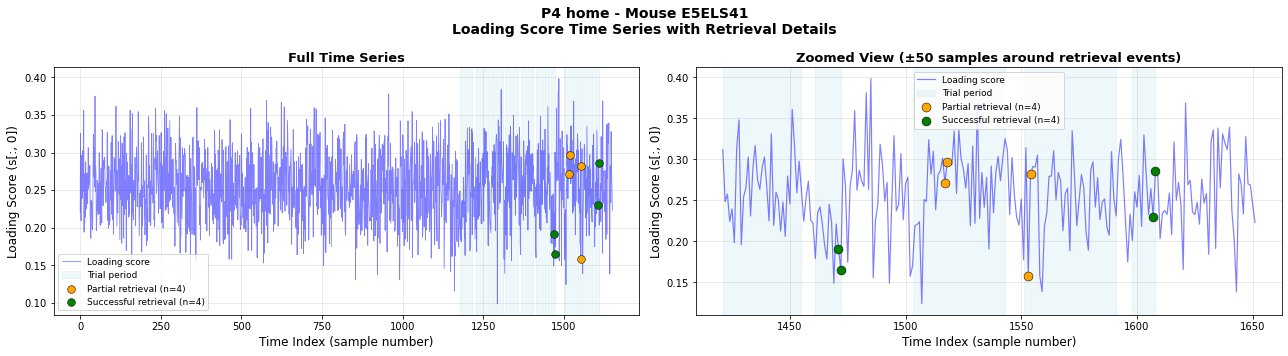

  ✓ Displayed plot for Mouse E5ELS41
  Mouse E6ELS44: 669 samples total
    - no trial (0): 560 samples
    - trial no retrieval (1): 88 samples
    - partial retrieval (3): 2 samples
    - successful retrieval (4): 19 samples


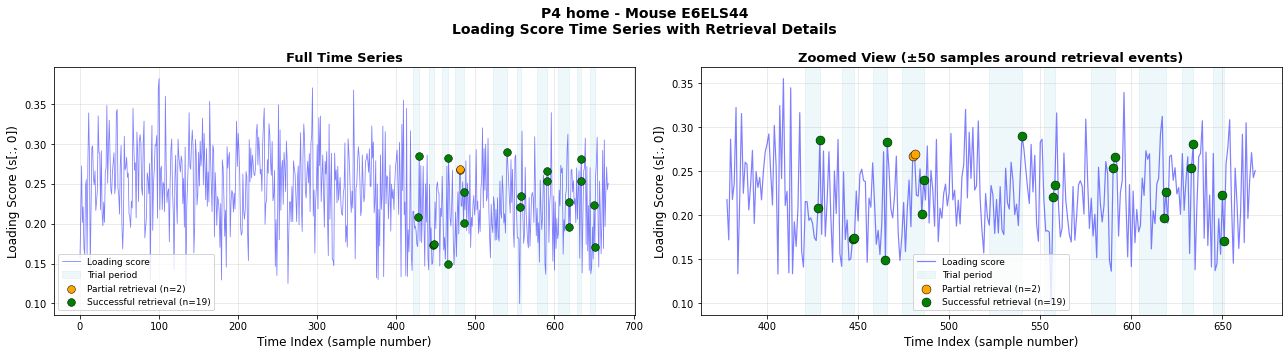

  ✓ Displayed plot for Mouse E6ELS44

ANALYSIS COMPLETE


In [47]:
import pickle
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# ============================================================================
# CONFIGURATION
# ============================================================================
PUP_RETRIEVAL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P4_pup_retrieval_detail.pkl"
X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]
Y_FEATURE = "pup_retrieval"
Y_INTERCEPT_FEATURE = "mouse_id"
Y_SAMPLING_FEATURE = "mouse_id"

# Model file - should be defined in environment as MODEL_SAVE_FILE
# Example: MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_Oct23.pt"

# Threshold for filtering
MIN_LABEL_1_SAMPLES = 10
# Pup retrieval detail labels
PUP_RETRIEVAL_DETAIL_LABELS = {
    0: "no trial",
    1: "trial no retrieval",
    3: "partial retrieval",
    4: "successful retrieval"
}

# Define C and E mouse groups (TARGET ANIMALS)
C_MICE_IDS = ['C6ELS9', 'C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
              'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
E_MICE_IDS = ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']

# ============================================================================
# LOAD DATA
# ============================================================================
with open(PUP_RETRIEVAL_DATA_FILE, "rb") as f:
    pup_retrieval_dict = pickle.load(f)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def clean_mouse_id(mouse_id):
    import re
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    cleaned = cleaned.replace('_', '')
    return cleaned

cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in pup_retrieval_dict['mouse_id']])

# Get all unique mice from the data
all_unique_mice = np.unique(cleaned_mouse_ids)
print(f"\nAll unique mice in data: {all_unique_mice}")
print(f"Total number of mice in file: {len(all_unique_mice)}")

# Find intersection with target animals
c_mice_in_data = [m for m in C_MICE_IDS if m in all_unique_mice]
e_mice_in_data = [m for m in E_MICE_IDS if m in all_unique_mice]
all_target_mice = c_mice_in_data + e_mice_in_data

print(f"\n{'='*60}")
print(f"TARGET ANIMALS (intersection with file)")
print(f"{'='*60}")
print(f"C group target mice: {C_MICE_IDS}")
print(f"C group in data: {c_mice_in_data} (n={len(c_mice_in_data)})")
print(f"\nE group target mice: {E_MICE_IDS}")
print(f"E group in data: {e_mice_in_data} (n={len(e_mice_in_data)})")
print(f"\nTotal target mice to analyze: {len(all_target_mice)}")

# Check periods
if 'period' in pup_retrieval_dict:
    unique_periods = np.unique(pup_retrieval_dict['period'])
    print(f"\nUnique periods in data: {unique_periods}")
    for p in unique_periods:
        print(f"  {p}: {np.sum(pup_retrieval_dict['period'] == p)} samples")
else:
    print("WARNING: No 'period' field found in data")

# Check pup_retrieval_detail
if 'pup_retrieval_detail' in pup_retrieval_dict:
    unique_details = np.unique(pup_retrieval_dict['pup_retrieval_detail'])
    print(f"\nUnique pup_retrieval_detail labels in data: {unique_details}")
    for d in unique_details:
        label_name = PUP_RETRIEVAL_DETAIL_LABELS.get(d, f"unknown ({d})")
        print(f"  {d} ({label_name}): {np.sum(pup_retrieval_dict['pup_retrieval_detail'] == d)} samples")
else:
    print("WARNING: No 'pup_retrieval_detail' field found in data")


def create_dataset(data, cleaned_mouse_ids, target_mouse_ids, target_period, dataset_name):
    """Create dataset - filter by target mouse_ids (intersection) and period"""
    
    # Filter: target mouse IDs only
    mouse_mask = np.isin(cleaned_mouse_ids, target_mouse_ids)
    
    # Filter: period
    if 'period' in data and target_period is not None:
        period_mask = data['period'] == target_period
        combined_mask = mouse_mask & period_mask
    else:
        combined_mask = mouse_mask
    
    print(f"\n{'='*60}")
    print(f"{dataset_name}")
    print(f"{'='*60}")
    
    # Check if there is data
    n_samples = np.sum(combined_mask)
    if n_samples == 0:
        print("⚠️  WARNING: No samples found!")
        return None
    
    # Apply mask to all data
    filtered_mouse_ids = cleaned_mouse_ids[combined_mask]
    filtered_y = data[Y_FEATURE][combined_mask]
    
    # Get pup_retrieval_detail if available
    if 'pup_retrieval_detail' in data:
        filtered_y_detail = data['pup_retrieval_detail'][combined_mask]
    else:
        filtered_y_detail = None
    
    # Get original indices for tracking time order - CRITICAL for time series!
    original_indices = np.where(combined_mask)[0]
    
    # Check if data is already time-ordered per mouse
    print(f"\n⚠️  IMPORTANT: Assuming data is already time-ordered within each mouse!")
    print(f"   If not, the time series plots will be incorrect.")
    
    print(f"Period: {target_period}")
    print(f"Total samples: {n_samples}")
    print(f"Target mice: {target_mouse_ids}")
    print(f"Mice in dataset: {np.unique(filtered_mouse_ids)}")
    print(f"Number of mice: {len(np.unique(filtered_mouse_ids))}")
    print(f"Label distribution: label_0={np.sum(filtered_y==0)}, label_1={np.sum(filtered_y==1)}")
    
    # Per-mouse distribution
    print(f"\nPer-mouse data:")
    for mouse_id in np.unique(filtered_mouse_ids):
        mouse_mask_inner = filtered_mouse_ids == mouse_id
        mouse_y = filtered_y[mouse_mask_inner]
        print(f"  {mouse_id}: n={len(mouse_y)}, label_0={np.sum(mouse_y==0)}, label_1={np.sum(mouse_y==1)}")
    
    # Prepare X features
    X_list = []
    for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS):
        feature_data = data[feature][combined_mask]
        X_list.append(feature_data * weight)
    
    X_data = np.hstack(X_list)
    
    print(f"\nFeature shapes after filtering:")
    print(f"  power: {data['power'][combined_mask].shape}")
    print(f"  coh_sq_coherence: {data['coh_sq_coherence'][combined_mask].shape}")
    print(f"  X combined: {X_data.shape}")
    print(f"  y: {filtered_y.shape}")
    
    y_data = filtered_y.reshape(-1, 1)
    y_intercept_data = filtered_mouse_ids
    
    # Encoders
    ordinal_encoder = OrdinalEncoder()
    y_sampling_data = ordinal_encoder.fit_transform(y_intercept_data.reshape(-1, 1))
    
    onehot_encoder = OneHotEncoder()
    y_intercept_mask_data = onehot_encoder.fit_transform(y_intercept_data.reshape(-1, 1)).todense()
    
    dataset = {
        'X': X_data,
        'y': y_data,
        'y_detail': filtered_y_detail,  # Add detailed labels
        'y_intercept': y_intercept_data,
        'y_sampling': y_sampling_data,
        'y_intercept_mask': y_intercept_mask_data,
        'intercept_dim': y_intercept_mask_data.shape[1],
        'mouse_list': np.unique(filtered_mouse_ids),
        'period': target_period,
        'original_indices': original_indices  # Track original time order
    }
    
    return dataset


def calculate_per_mouse_auc(model, X, y_true, mouse_ids, dataset_name):
    """Calculate overall and per-mouse AUC statistics"""
    # Ensure eval mode
    model.eval()
    with torch.no_grad():
        y_pred_proba, s = model.predict_proba(X, include_scores=True)
    
    # Flatten y_true
    y_true_flat = y_true.flatten() if len(y_true.shape) > 1 else y_true
    
    # Overall AUC
    overall_auc = roc_auc_score(y_true_flat, y_pred_proba)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name}")
    print(f"{'='*60}")
    print(f"Overall AUC: {overall_auc:.4f}")
    
    # Per-mouse AUC
    unique_mouse_ids = np.unique(mouse_ids)
    per_mouse_results = []
    
    print("\nPer-mouse AUC:")
    for mouse_id in unique_mouse_ids:
        mouse_mask = mouse_ids == mouse_id
        y_true_mouse = y_true_flat[mouse_mask]
        y_pred_mouse = y_pred_proba[mouse_mask]
        
        if len(np.unique(y_true_mouse)) > 1:
            mouse_auc = roc_auc_score(y_true_mouse, y_pred_mouse)
            per_mouse_results.append({
                'Mouse_ID': mouse_id,
                'AUC': mouse_auc,
                'N_samples': len(y_true_mouse),
                'N_label_0': int(np.sum(y_true_mouse==0)),
                'N_label_1': int(np.sum(y_true_mouse==1))
            })
            print(f"  {mouse_id}: {mouse_auc:.4f}")
        else:
            print(f"  {mouse_id}: SKIPPED (single class)")
    
    # Mouse-wise statistics
    per_mouse_aucs = [r['AUC'] for r in per_mouse_results]
    
    if per_mouse_aucs:
        mean_auc = np.mean(per_mouse_aucs)
        std_auc = np.std(per_mouse_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(per_mouse_aucs))
        
        print(f"\nMouse-wise AUC statistics:")
        print(f"  Mean: {mean_auc:.4f}")
        print(f"  SEM: {sem_auc:.4f}")
        print(f"  STD: {std_auc:.4f}")
        print(f"  N mice: {len(per_mouse_aucs)}")
        
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': per_mouse_aucs,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_mice': len(per_mouse_aucs),
            'per_mouse_details': per_mouse_results,
            's_scores': s,  # Return loading scores
            'y_pred_proba': y_pred_proba
        }
    else:
        print("\n⚠️  No mice with both classes")
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': [],
            'mean_auc': None,
            'std_auc': None,
            'sem_auc': None,
            'n_mice': 0,
            'per_mouse_details': [],
            's_scores': s,
            'y_pred_proba': y_pred_proba
        }


def calculate_contrast_auc(model, X, y_detail, mouse_ids, dataset_name):
    """
    Calculate AUC for contrast: label 1 (response=0) vs labels 3/4 (response=1)
    Only include samples where y_detail is in [1, 3, 4]
    """
    print(f"\n{'='*60}")
    print(f"CONTRAST ANALYSIS: {dataset_name}")
    print(f"Label 1 (trial no retrieval) = response 0")
    print(f"Labels 3/4 (partial/successful retrieval) = response 1")
    print(f"{'='*60}")
    
    # Filter to only include labels 1, 3, 4
    contrast_mask = np.isin(y_detail, [1, 3, 4])
    
    if np.sum(contrast_mask) == 0:
        print("⚠️  No samples with labels 1, 3, or 4")
        return None
    
    # Apply filter
    X_contrast = X[contrast_mask]
    y_detail_contrast = y_detail[contrast_mask]
    mouse_ids_contrast = mouse_ids[contrast_mask]
    
    # Create binary response: 1 -> 0, 3/4 -> 1
    y_contrast = np.zeros(len(y_detail_contrast))
    y_contrast[np.isin(y_detail_contrast, [3, 4])] = 1
    
    print(f"\nContrast data:")
    print(f"  Total samples: {len(y_contrast)}")
    print(f"  Label 1 (response=0): {np.sum(y_contrast==0)}")
    print(f"  Labels 3/4 (response=1): {np.sum(y_contrast==1)}")
    
    # Get model predictions
    model.eval()
    with torch.no_grad():
        y_pred_proba, s = model.predict_proba(X_contrast, include_scores=True)
    
    # Overall AUC
    if len(np.unique(y_contrast)) > 1:
        overall_auc = roc_auc_score(y_contrast, y_pred_proba)
        print(f"\nOverall Contrast AUC: {overall_auc:.4f}")
    else:
        print("\n⚠️  Only one class in contrast data")
        overall_auc = np.nan
    
    # Per-mouse AUC
    unique_mouse_ids = np.unique(mouse_ids_contrast)
    per_mouse_results = []
    
    print("\nPer-mouse Contrast AUC:")
    for mouse_id in unique_mouse_ids:
        mouse_mask = mouse_ids_contrast == mouse_id
        y_contrast_mouse = y_contrast[mouse_mask]
        y_pred_mouse = y_pred_proba[mouse_mask]
        
        # Check if mouse has both classes
        if len(np.unique(y_contrast_mouse)) > 1:
            mouse_auc = roc_auc_score(y_contrast_mouse, y_pred_mouse)
            per_mouse_results.append({
                'Mouse_ID': mouse_id,
                'Contrast_AUC': mouse_auc,
                'N_samples': len(y_contrast_mouse),
                'N_response_0': int(np.sum(y_contrast_mouse==0)),
                'N_response_1': int(np.sum(y_contrast_mouse==1))
            })
            print(f"  {mouse_id}: {mouse_auc:.4f} (n_0={int(np.sum(y_contrast_mouse==0))}, n_1={int(np.sum(y_contrast_mouse==1))})")
        else:
            print(f"  {mouse_id}: SKIPPED (single class)")
    
    # Mouse-wise statistics
    per_mouse_aucs = [r['Contrast_AUC'] for r in per_mouse_results]
    
    if per_mouse_aucs:
        mean_auc = np.mean(per_mouse_aucs)
        std_auc = np.std(per_mouse_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(per_mouse_aucs))
        
        print(f"\nMouse-wise Contrast AUC statistics:")
        print(f"  Mean: {mean_auc:.4f}")
        print(f"  SEM: {sem_auc:.4f}")
        print(f"  STD: {std_auc:.4f}")
        print(f"  N mice: {len(per_mouse_aucs)}")
        
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': per_mouse_aucs,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_mice': len(per_mouse_aucs),
            'per_mouse_details': per_mouse_results
        }
    else:
        print("\n⚠️  No mice with both classes in contrast")
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': [],
            'mean_auc': None,
            'std_auc': None,
            'sem_auc': None,
            'n_mice': 0,
            'per_mouse_details': []
        }


def wilcoxon_test_vs_chance(per_mouse_results, group_name, auc_key='AUC'):
    """
    Perform one-sided Wilcoxon signed-rank test: H1: AUC > 0.5
    Skip mice with single class (all 0 or all 1)
    
    Parameters:
    - per_mouse_results: list of dicts with 'Mouse_ID', 'AUC' or 'Contrast_AUC', etc.
    - group_name: name of the group for printing
    - auc_key: key to extract AUC values ('AUC' or 'Contrast_AUC')
    
    Returns:
    - dict with test results
    """
    print(f"\n{'='*60}")
    print(f"WILCOXON SIGNED-RANK TEST: {group_name}")
    print(f"{'='*60}")
    print(f"Null hypothesis (H0): median AUC = 0.5")
    print(f"Alternative hypothesis (H1): median AUC > 0.5 (one-sided)")
    
    # Extract AUCs (already filtered to only include mice with both classes)
    aucs = np.array([r[auc_key] for r in per_mouse_results])
    
    if len(aucs) == 0:
        print("⚠️  No valid mice for testing (all skipped due to single class)")
        return {
            'group': group_name,
            'n_mice': 0,
            'mean_auc': np.nan,
            'sem_auc': np.nan,
            'p_value': np.nan,
            'statistic': np.nan
        }
    
    # Calculate statistics
    mean_auc = np.mean(aucs)
    sem_auc = np.std(aucs, ddof=1) / np.sqrt(len(aucs))
    
    print(f"\nSample statistics:")
    print(f"  N mice: {len(aucs)}")
    print(f"  Mean AUC: {mean_auc:.4f}")
    print(f"  SEM: {sem_auc:.4f}")
    print(f"  AUCs: {aucs}")
    
    # Perform Wilcoxon signed-rank test
    # Test if AUC - 0.5 > 0 (one-sided)
    differences = aucs - 0.5
    
    # Check if all differences are zero
    if np.all(differences == 0):
        print("\n⚠️  All AUCs equal to 0.5, cannot perform test")
        return {
            'group': group_name,
            'n_mice': len(aucs),
            'mean_auc': mean_auc,
            'sem_auc': sem_auc,
            'p_value': np.nan,
            'statistic': np.nan
        }
    
    # Perform test (alternative='greater' for one-sided test AUC > 0.5)
    try:
        statistic, p_value_two_sided = wilcoxon(differences, alternative='two-sided')
        # For one-sided test (greater), divide two-sided p-value by 2 if median > 0
        if np.median(differences) > 0:
            p_value_one_sided = p_value_two_sided / 2
        else:
            p_value_one_sided = 1 - p_value_two_sided / 2
        
        print(f"\nWilcoxon test results:")
        print(f"  Statistic: {statistic:.4f}")
        print(f"  One-sided p-value (AUC > 0.5): {p_value_one_sided:.6f}")
        
        if p_value_one_sided < 0.001:
            print(f"  Significance: *** (p < 0.001)")
        elif p_value_one_sided < 0.01:
            print(f"  Significance: ** (p < 0.01)")
        elif p_value_one_sided < 0.05:
            print(f"  Significance: * (p < 0.05)")
        else:
            print(f"  Significance: n.s. (p >= 0.05)")
        
        return {
            'group': group_name,
            'n_mice': len(aucs),
            'mean_auc': mean_auc,
            'sem_auc': sem_auc,
            'p_value': p_value_one_sided,
            'statistic': statistic
        }
    
    except Exception as e:
        print(f"\n⚠️  Error performing Wilcoxon test: {e}")
        return {
            'group': group_name,
            'n_mice': len(aucs),
            'mean_auc': mean_auc,
            'sem_auc': sem_auc,
            'p_value': np.nan,
            'statistic': np.nan
        }


def plot_mouse_loading_timeseries(s_scores, y_true, y_detail, mouse_ids, period):
    """
    Plot loading score time series for each mouse with trial periods shaded
    
    Visualization scheme:
    - label 0 (no trial): no marking
    - labels 1, 3, 4 (all trial periods): light blue shaded regions
    - label 3 (partial retrieval): orange points ON TOP of shading
    - label 4 (successful retrieval): green points ON TOP of shading
    
    CRITICAL ASSUMPTION: 
    - The input data must be in TIME ORDER within each mouse
    
    Parameters:
    - s_scores: shape (n_samples, n_loading_dims), uses ONLY s[:, 0] (first loading dimension)
    - y_true: binary labels (0/1) for AUC calculation
    - y_detail: detailed labels (0, 1, 3, 4)
    """
    unique_mice = np.unique(mouse_ids)
    y_true_flat = y_true.flatten() if len(y_true.shape) > 1 else y_true
    
    # s_scores should be 2D: (n_samples, n_loading_dims)
    if len(s_scores.shape) == 1:
        s_scores = s_scores.reshape(-1, 1)
    
    # Extract ONLY the first loading dimension
    s_first_dim = s_scores[:, 0]
    
    print(f"\n{'='*60}")
    print(f"PLOTTING: {period}")
    print(f"{'='*60}")
    print(f"s_scores shape: {s_scores.shape}")
    print(f"Using ONLY first loading dimension: s[:, 0]")
    print(f"⚠️  Assuming samples are in TIME ORDER within each mouse!")
    
    for mouse_id in unique_mice:
        mouse_mask = mouse_ids == mouse_id
        mouse_s = s_first_dim[mouse_mask]
        mouse_y = y_true_flat[mouse_mask]
        mouse_y_detail = y_detail[mouse_mask] if y_detail is not None else None
        
        # Time indices (assuming sequential order)
        time_indices = np.arange(len(mouse_y))
        
        # Find label=1 indices (any retrieval behavior)
        label1_indices = np.where(mouse_y == 1)[0]
        
        if len(label1_indices) == 0:
            print(f"  Skipping {mouse_id}: no label=1 samples")
            continue
        
        # Count different detail labels
        if mouse_y_detail is not None:
            unique_details, detail_counts = np.unique(mouse_y_detail, return_counts=True)
            print(f"  Mouse {mouse_id}: {len(mouse_y)} samples total")
            for ud, dc in zip(unique_details, detail_counts):
                label_name = PUP_RETRIEVAL_DETAIL_LABELS.get(ud, f"unknown ({ud})")
                print(f"    - {label_name} ({ud}): {dc} samples")
        else:
            print(f"  Mouse {mouse_id}: {len(mouse_y)} samples, {len(label1_indices)} label=1 samples")
        
        # Calculate zoom window
        zoom_start = max(0, label1_indices[0] - 50)
        zoom_end = min(len(mouse_y), label1_indices[-1] + 50)
        
        # Create figure with 1 row, 2 columns (full view + zoomed view)
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        
        # ========== FULL PLOT (left) ==========
        ax_full = axes[0]
        
        # Plot baseline time series
        ax_full.plot(time_indices, mouse_s, 'b-', alpha=0.5, linewidth=0.8, label='Loading score')
        
        if mouse_y_detail is not None:
            # Find ALL trial periods (labels 1, 3, 4) and shade them together
            trial_indices = np.where(np.isin(mouse_y_detail, [1, 3, 4]))[0]
            if len(trial_indices) > 0:
                # Find contiguous segments for all trials
                segments = []
                start_idx = trial_indices[0]
                for i in range(1, len(trial_indices)):
                    if trial_indices[i] != trial_indices[i-1] + 1:
                        # End of segment
                        segments.append((start_idx, trial_indices[i-1]))
                        start_idx = trial_indices[i]
                # Add last segment
                segments.append((start_idx, trial_indices[-1]))
                
                # Shade each trial segment
                for seg_start, seg_end in segments:
                    ax_full.axvspan(seg_start, seg_end, alpha=0.2, color='lightblue', 
                                   label='Trial period' if seg_start == segments[0][0] else '')
            
            # Plot partial retrieval (label 3) - orange points ON TOP
            partial_indices = np.where(mouse_y_detail == 3)[0]
            if len(partial_indices) > 0:
                ax_full.scatter(partial_indices, mouse_s[partial_indices], 
                              c='orange', s=60, marker='o', zorder=5, 
                              label=f'Partial retrieval (n={len(partial_indices)})', 
                              edgecolors='black', linewidths=0.5)
            
            # Plot successful retrieval (label 4) - green points ON TOP
            successful_indices = np.where(mouse_y_detail == 4)[0]
            if len(successful_indices) > 0:
                ax_full.scatter(successful_indices, mouse_s[successful_indices], 
                              c='green', s=60, marker='o', zorder=5, 
                              label=f'Successful retrieval (n={len(successful_indices)})', 
                              edgecolors='black', linewidths=0.5)
        else:
            # Fallback: just mark label=1
            ax_full.scatter(label1_indices, mouse_s[label1_indices], 
                          c='red', s=50, marker='o', zorder=5, label='Label=1')
        
        ax_full.set_xlabel('Time Index (sample number)', fontsize=12)
        ax_full.set_ylabel('Loading Score (s[:, 0])', fontsize=12)
        ax_full.set_title('Full Time Series', fontsize=13, fontweight='bold')
        ax_full.legend(loc='best', fontsize=9)
        ax_full.grid(True, alpha=0.3)
        
        # ========== ZOOMED PLOT (right) ==========
        ax_zoom = axes[1]
        zoom_time = time_indices[zoom_start:zoom_end]
        zoom_s = mouse_s[zoom_start:zoom_end]
        zoom_y_detail = mouse_y_detail[zoom_start:zoom_end] if mouse_y_detail is not None else None
        
        # Plot baseline time series
        ax_zoom.plot(zoom_time, zoom_s, 'b-', alpha=0.5, linewidth=1.2, label='Loading score')
        
        if zoom_y_detail is not None:
            # Find ALL trial periods (labels 1, 3, 4) and shade them together
            trial_zoom = np.where(np.isin(zoom_y_detail, [1, 3, 4]))[0]
            if len(trial_zoom) > 0:
                # Find contiguous segments in zoomed view
                segments_zoom = []
                start_idx = trial_zoom[0]
                for i in range(1, len(trial_zoom)):
                    if trial_zoom[i] != trial_zoom[i-1] + 1:
                        segments_zoom.append((start_idx, trial_zoom[i-1]))
                        start_idx = trial_zoom[i]
                segments_zoom.append((start_idx, trial_zoom[-1]))
                
                # Shade each trial segment
                for seg_start, seg_end in segments_zoom:
                    ax_zoom.axvspan(zoom_time[seg_start], zoom_time[seg_end], 
                                   alpha=0.2, color='lightblue',
                                   label='Trial period' if seg_start == segments_zoom[0][0] else '')
            
            # Plot partial retrieval (label 3) - orange points ON TOP
            partial_zoom = np.where(zoom_y_detail == 3)[0]
            if len(partial_zoom) > 0:
                ax_zoom.scatter(zoom_time[partial_zoom], zoom_s[partial_zoom], 
                              c='orange', s=80, marker='o', zorder=5, 
                              label=f'Partial retrieval (n={len(partial_zoom)})', 
                              edgecolors='black', linewidths=0.5)
            
            # Plot successful retrieval (label 4) - green points ON TOP
            successful_zoom = np.where(zoom_y_detail == 4)[0]
            if len(successful_zoom) > 0:
                ax_zoom.scatter(zoom_time[successful_zoom], zoom_s[successful_zoom], 
                              c='green', s=80, marker='o', zorder=5, 
                              label=f'Successful retrieval (n={len(successful_zoom)})', 
                              edgecolors='black', linewidths=0.5)
        
        ax_zoom.set_xlabel('Time Index (sample number)', fontsize=12)
        ax_zoom.set_ylabel('Loading Score (s[:, 0])', fontsize=12)
        ax_zoom.set_title('Zoomed View (±50 samples around retrieval events)', fontsize=13, fontweight='bold')
        ax_zoom.legend(loc='best', fontsize=9)
        ax_zoom.grid(True, alpha=0.3)
        
        plt.suptitle(f'{period} - Mouse {mouse_id}\nLoading Score Time Series with Retrieval Details', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"  ✓ Displayed plot for Mouse {mouse_id}")


# ============================================================================
# MAIN ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("CREATING DATASETS")
print("="*80)

# P4 home datasets - using TARGET ANIMALS only
pup_c_p4_dataset = create_dataset(
    pup_retrieval_dict, 
    cleaned_mouse_ids,
    c_mice_in_data,
    'P4 home',
    "C MICE - P4 home"
)

pup_e_p4_dataset = create_dataset(
    pup_retrieval_dict,
    cleaned_mouse_ids,
    e_mice_in_data,
    'P4 home',
    "E MICE - P4 home"
)

# Combined dataset for overall analysis
pup_all_p4_dataset = create_dataset(
    pup_retrieval_dict, 
    cleaned_mouse_ids,
    all_target_mice,
    'P4 home',
    "ALL TARGET MICE - P4 home"
)

# Check if datasets were created successfully
datasets_to_process = []
if pup_c_p4_dataset is not None:
    datasets_to_process.append(('C', 'P4 home', pup_c_p4_dataset))
if pup_e_p4_dataset is not None:
    datasets_to_process.append(('E', 'P4 home', pup_e_p4_dataset))

if not datasets_to_process:
    print("\n⚠️  ERROR: No valid datasets created!")
    exit()

# ============================================================================
# MODEL PREDICTION
# ============================================================================
print("\n" + "="*80)
print("LOADING MODEL")
print("="*80)

model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'

print("\n" + "="*80)
print("MODEL PREDICTIONS - MAIN ANALYSIS (0 vs 1)")
print("="*80)

all_results = []

for group, period, dataset in datasets_to_process:
    result = calculate_per_mouse_auc(
        model=model,
        X=dataset['X'],
        y_true=dataset['y'],
        mouse_ids=dataset['y_intercept'],
        dataset_name=f"{group} MICE - {period} - PUP RETRIEVAL"
    )
    result['group'] = group
    result['period'] = period
    result['dataset'] = dataset  # Store dataset for plotting
    all_results.append(result)

# ============================================================================
# CONTRAST ANALYSIS (label 1 vs 3/4)
# ============================================================================
print("\n" + "="*80)
print("CONTRAST ANALYSIS - Label 1 vs Labels 3/4")
print("="*80)

contrast_results = []

for group, period, dataset in datasets_to_process:
    if dataset['y_detail'] is not None:
        contrast_result = calculate_contrast_auc(
            model=model,
            X=dataset['X'],
            y_detail=dataset['y_detail'],
            mouse_ids=dataset['y_intercept'],
            dataset_name=f"{group} MICE - {period}"
        )
        if contrast_result is not None:
            contrast_result['group'] = group
            contrast_result['period'] = period
            contrast_results.append(contrast_result)

# ============================================================================
# WILCOXON SIGNED-RANK TESTS - MAIN ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL TESTING: MAIN AUC > 0.5")
print("="*80)

wilcoxon_main_results = []
for result in all_results:
    wilcoxon_result = wilcoxon_test_vs_chance(
        result['per_mouse_details'], 
        f"{result['group']} GROUP - MAIN",
        auc_key='AUC'
    )
    wilcoxon_main_results.append(wilcoxon_result)

# ============================================================================
# WILCOXON SIGNED-RANK TESTS - CONTRAST ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL TESTING: CONTRAST AUC > 0.5")
print("="*80)

wilcoxon_contrast_results = []
for result in contrast_results:
    wilcoxon_result = wilcoxon_test_vs_chance(
        result['per_mouse_details'], 
        f"{result['group']} GROUP - CONTRAST",
        auc_key='Contrast_AUC'
    )
    wilcoxon_contrast_results.append(wilcoxon_result)

# ============================================================================
# SUMMARY TABLES
# ============================================================================
print("\n" + "="*80)
print("SUMMARY: MAIN ANALYSIS (0 vs 1) BY GROUP")
print("="*80)

main_summary_data = []
for result, wilcoxon_result in zip(all_results, wilcoxon_main_results):
    main_summary_data.append({
        'Group': result['group'],
        'Period': result['period'],
        'N_mice': result['n_mice'],
        'Mean_AUC': result['mean_auc'] if result['mean_auc'] is not None else np.nan,
        'SEM': result['sem_auc'] if result['sem_auc'] is not None else np.nan,
        'STD': result['std_auc'] if result['std_auc'] is not None else np.nan,
        'Wilcoxon_p': wilcoxon_result['p_value']
    })

if main_summary_data:
    main_summary_df = pd.DataFrame(main_summary_data)
    print("\n" + main_summary_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("SUMMARY: CONTRAST ANALYSIS (1 vs 3/4) BY GROUP")
print("="*80)

contrast_summary_data = []
for result, wilcoxon_result in zip(contrast_results, wilcoxon_contrast_results):
    contrast_summary_data.append({
        'Group': result['group'],
        'Period': result['period'],
        'N_mice': result['n_mice'],
        'Mean_Contrast_AUC': result['mean_auc'] if result['mean_auc'] is not None else np.nan,
        'SEM': result['sem_auc'] if result['sem_auc'] is not None else np.nan,
        'STD': result['std_auc'] if result['std_auc'] is not None else np.nan,
        'Wilcoxon_p': wilcoxon_result['p_value']
    })

if contrast_summary_data:
    contrast_summary_df = pd.DataFrame(contrast_summary_data)
    print("\n" + contrast_summary_df.to_string(index=False, float_format='%.4f'))

# ============================================================================
# COMBINED WILCOXON TESTS (C + E groups merged)
# ============================================================================
print("\n" + "="*80)
print("COMBINED WILCOXON TESTS (C + E groups merged)")
print("="*80)

# Combine all per-mouse results across C and E groups
all_main_details = []
for result in all_results:
    all_main_details.extend(result['per_mouse_details'])

all_contrast_details_combined = []
for result in contrast_results:
    all_contrast_details_combined.extend(result['per_mouse_details'])

# Perform combined Wilcoxon test for MAIN analysis
if all_main_details:
    combined_main_wilcoxon = wilcoxon_test_vs_chance(
        all_main_details, 
        "COMBINED (C+E) - MAIN ANALYSIS",
        auc_key='AUC'
    )
else:
    print("⚠️  No data for combined main Wilcoxon test")
    combined_main_wilcoxon = None

# Perform combined Wilcoxon test for CONTRAST analysis
if all_contrast_details_combined:
    combined_contrast_wilcoxon = wilcoxon_test_vs_chance(
        all_contrast_details_combined, 
        "COMBINED (C+E) - CONTRAST ANALYSIS",
        auc_key='Contrast_AUC'
    )
else:
    print("⚠️  No data for combined contrast Wilcoxon test")
    combined_contrast_wilcoxon = None

# Summary table for combined tests
print("\n" + "="*80)
print("SUMMARY: COMBINED WILCOXON TESTS")
print("="*80)

combined_wilcoxon_summary = []
if combined_main_wilcoxon is not None and combined_main_wilcoxon['n_mice'] > 0:
    combined_wilcoxon_summary.append({
        'Analysis': 'Main (0 vs 1)',
        'N_mice': combined_main_wilcoxon['n_mice'],
        'Mean_AUC': combined_main_wilcoxon['mean_auc'],
        'SEM': combined_main_wilcoxon['sem_auc'],
        'Wilcoxon_p': combined_main_wilcoxon['p_value']
    })

if combined_contrast_wilcoxon is not None and combined_contrast_wilcoxon['n_mice'] > 0:
    combined_wilcoxon_summary.append({
        'Analysis': 'Contrast (1 vs 3/4)',
        'N_mice': combined_contrast_wilcoxon['n_mice'],
        'Mean_AUC': combined_contrast_wilcoxon['mean_auc'],
        'SEM': combined_contrast_wilcoxon['sem_auc'],
        'Wilcoxon_p': combined_contrast_wilcoxon['p_value']
    })

if combined_wilcoxon_summary:
    combined_wilcoxon_df = pd.DataFrame(combined_wilcoxon_summary)
    print("\n" + combined_wilcoxon_df.to_string(index=False, float_format='%.4f'))

# ============================================================================
# PER-MOUSE DETAILS TABLE
# ============================================================================
print("\n" + "="*80)
print("PER-MOUSE DETAILS - MAIN ANALYSIS")
print("="*80)

all_details = []
for result in all_results:
    for detail in result['per_mouse_details']:
        detail['Period'] = result['period']
        detail['Group'] = result['group']
        all_details.append(detail)

if all_details:
    details_df = pd.DataFrame(all_details)
    details_df = details_df[['Period', 'Group', 'Mouse_ID', 'AUC', 'N_samples', 'N_label_0', 'N_label_1']]
    print("\n" + details_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("PER-MOUSE DETAILS - CONTRAST ANALYSIS")
print("="*80)

all_contrast_details = []
for result in contrast_results:
    for detail in result['per_mouse_details']:
        detail['Period'] = result['period']
        detail['Group'] = result['group']
        all_contrast_details.append(detail)

if all_contrast_details:
    contrast_details_df = pd.DataFrame(all_contrast_details)
    contrast_details_df = contrast_details_df[['Period', 'Group', 'Mouse_ID', 'Contrast_AUC', 'N_samples', 'N_response_0', 'N_response_1']]
    print("\n" + contrast_details_df.to_string(index=False, float_format='%.4f'))

# ============================================================================
# PLOT LOADING TIME SERIES WITH DETAILED LABELS
# ============================================================================
print("\n" + "="*80)
print("GENERATING LOADING TIME SERIES PLOTS WITH RETRIEVAL DETAILS")
print("="*80)

for result in all_results:
    group = result['group']
    period = result['period']
    dataset = result['dataset']
    s_scores = result['s_scores']
    
    print(f"\nPlotting: {group} - {period}")
    plot_mouse_loading_timeseries(
        s_scores=s_scores,
        y_true=dataset['y'],
        y_detail=dataset['y_detail'],
        mouse_ids=dataset['y_intercept'],
        period=period
    )

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)